# Plot functions

## Imports

In [177]:
import re
import os
import json
import numpy as np
import matplotlib.pyplot as plt

## Utilities

In [ ]:
def parse_log(filename):
    train_rewards = {}
    eval_rewards = {}
    eval_stds = {}
    
    re_train = re.compile(r"Run:\s+\d+/\d+\s+\|\s+Episode:\s+(\d+)/\d+.*Mean reward:\s+([-\d\.]+)")
    re_eval = re.compile(r"\*\*\* EVALUATION\s+\|\s+Episode:\s+(\d+)\s+\|\s+Mean Reward:\s+([-\d\.]+)\s+±\s+([\d\.]+)")

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            
            # Match training
            m_train = re_train.search(line)
            if m_train:
                ep = int(m_train.group(1))
                mean_rew = float(m_train.group(2))
                if ep not in train_rewards:
                    train_rewards[ep] = []
                train_rewards[ep].append(mean_rew)
                continue
                
            # Match evaluation
            m_eval = re_eval.search(line)
            if m_eval:
                ep = int(m_eval.group(1))
                mean_eval = float(m_eval.group(2))
                std_eval = float(m_eval.group(3))
                if ep not in eval_rewards:
                    eval_rewards[ep] = []
                    eval_stds[ep] = []
                eval_rewards[ep].append(mean_eval)
                eval_stds[ep].append(std_eval)
                
    return train_rewards, eval_rewards, eval_stds

def aggregate_data(data_dict):
    episodes = sorted(data_dict.keys())
    means = []
    variances = []
    
    for ep in episodes:
        values = data_dict[ep]
        means.append(np.mean(values))
        variances.append(np.std(values))
        
    return np.array(episodes), np.array(means), np.array(variances)

def plot_rewards_vs_episodes(techniques, ids, var_attributes):
    folder = "runs"
    config_files = [os.path.join(folder, technique, f"config_{id}.json") for id, technique in zip(ids, techniques)]
    log_files = [os.path.join(folder, technique, f"training_{id}.log") for id, technique in zip(ids, techniques)]

    train_rewards, eval_rewards, _ = zip(*[parse_log(log) for log in log_files])
    configs = [dict(map(lambda x: (x, json.load(open(cfg, 'r')).get(x)), var_attributes)) for cfg in config_files]

    episodes_train, train_mean, train_std = zip(*[aggregate_data(train_r) for train_r in train_rewards])
    episodes_eval, eval_mean, eval_std = zip(*[aggregate_data(eval_r) for eval_r in eval_rewards])

    # ===== PLOT =====
    fig, ax = plt.subplots(2, 2, figsize=(10, 10), dpi=200)

    ax1, ax2, ax3, ax4 = ax.flatten()

    # Training plot
    for i, (ep, mean, _) in enumerate(zip(episodes_train, train_mean, train_std)):
        label = ",".join([
            f"{''.join(c[0].upper() for c in attr.split('_'))}={''.join(c[0].upper() for c in configs[i][attr].split('_')) if isinstance(configs[i][attr], str) else configs[i][attr]}"
            for attr in var_attributes
        ])
        ax1.plot(ep, mean, label=label)
    ax1.set_title("Training - Mean Reward (30 run)")
    ax1.set_xlabel("Episodes")
    ax1.axhline(200, color='gray', linestyle='--', label="Goal")
    ax1.grid(alpha=0.3)
    ax1.legend()

    # Eval plot
    for i, (ep, mean, _) in enumerate(zip(episodes_eval, eval_mean, eval_std)):
        label = ",".join([
            f"{''.join(c[0].upper() for c in attr.split('_'))}={''.join(c[0].upper() for c in configs[i][attr].split('_')) if isinstance(configs[i][attr], str) else configs[i][attr]}"
            for attr in var_attributes
        ])
        ax2.plot(ep, mean, label=label)

    ax2.set_title("Evaluation - Mean Reward (30 run)")
    ax2.set_xlabel("Episodes")
    ax2.axhline(200, color='gray', linestyle='--', label="Goal (200)")

    ax2.grid(alpha=0.3)
    ax2.legend()

    # Training std plot
    for i, (ep, _, std) in enumerate(zip(episodes_train, train_mean, train_std)):
        label = ",".join([
            f"{''.join(c[0].upper() for c in attr.split('_'))}={''.join(c[0].upper() for c in configs[i][attr].split('_')) if isinstance(configs[i][attr], str) else configs[i][attr]}"
            for attr in var_attributes
        ])
        ax3.plot(ep, std, label=label)
    ax3.set_title("Training - Standard Deviation")
    ax3.set_xlabel("Episodes")
    
    ax3.grid(alpha=0.3)
    ax3.legend()

    # Eval std plot
    for i, (ep, _, std) in enumerate(zip(episodes_eval, eval_mean, eval_std)):
        label = ",".join([
            f"{''.join(c[0].upper() for c in attr.split('_'))}={''.join(c[0].upper() for c in configs[i][attr].split('_')) if isinstance(configs[i][attr], str) else configs[i][attr]}"
            for attr in var_attributes
        ])
        ax4.plot(ep, std, label=label)
    ax4.set_title("Evaluation - Standard Deviation")
    ax4.set_xlabel("Episodes")
    ax4.grid(alpha=0.3)
    ax4.legend()

    plt.tight_layout()
    plt.show()

## Run

### Experiments

In [179]:
all_ids = [
    "20260418_015308",      # es, bs=128, up=1, t=1e-3
    "20260419_182856",      # es, bs=128, up=4, t=1e-3
    "20260420_004916",      # es, bs=256, up=1, t=1e-3
    "20260420_193058",      # es, bs=256, up=4, t=1e-3
    "20260421_192040",      # es, bs=256, up=4, t=4e-3
    "20260422_201441",      # es, bs=256, up=1, t=4e-3
    "20260418_222137",      # ql, bs=256, up=1, t=1e-3
    "20260421_191830",      # ql, bs=256, up=4, t=1e-3
    "20260422_100253",      # ql, bs=128, up=4, t=1e-3
    "20260422_185517"       # ql, bs=128, up=1, t=1e-3
]
all_techniques = ["expected_sarsa"] * 6 + ["q_learning"] * 4
all_var_attributes = ["algorithm", "batch_size", "update_period", "tau"]

### Plot all

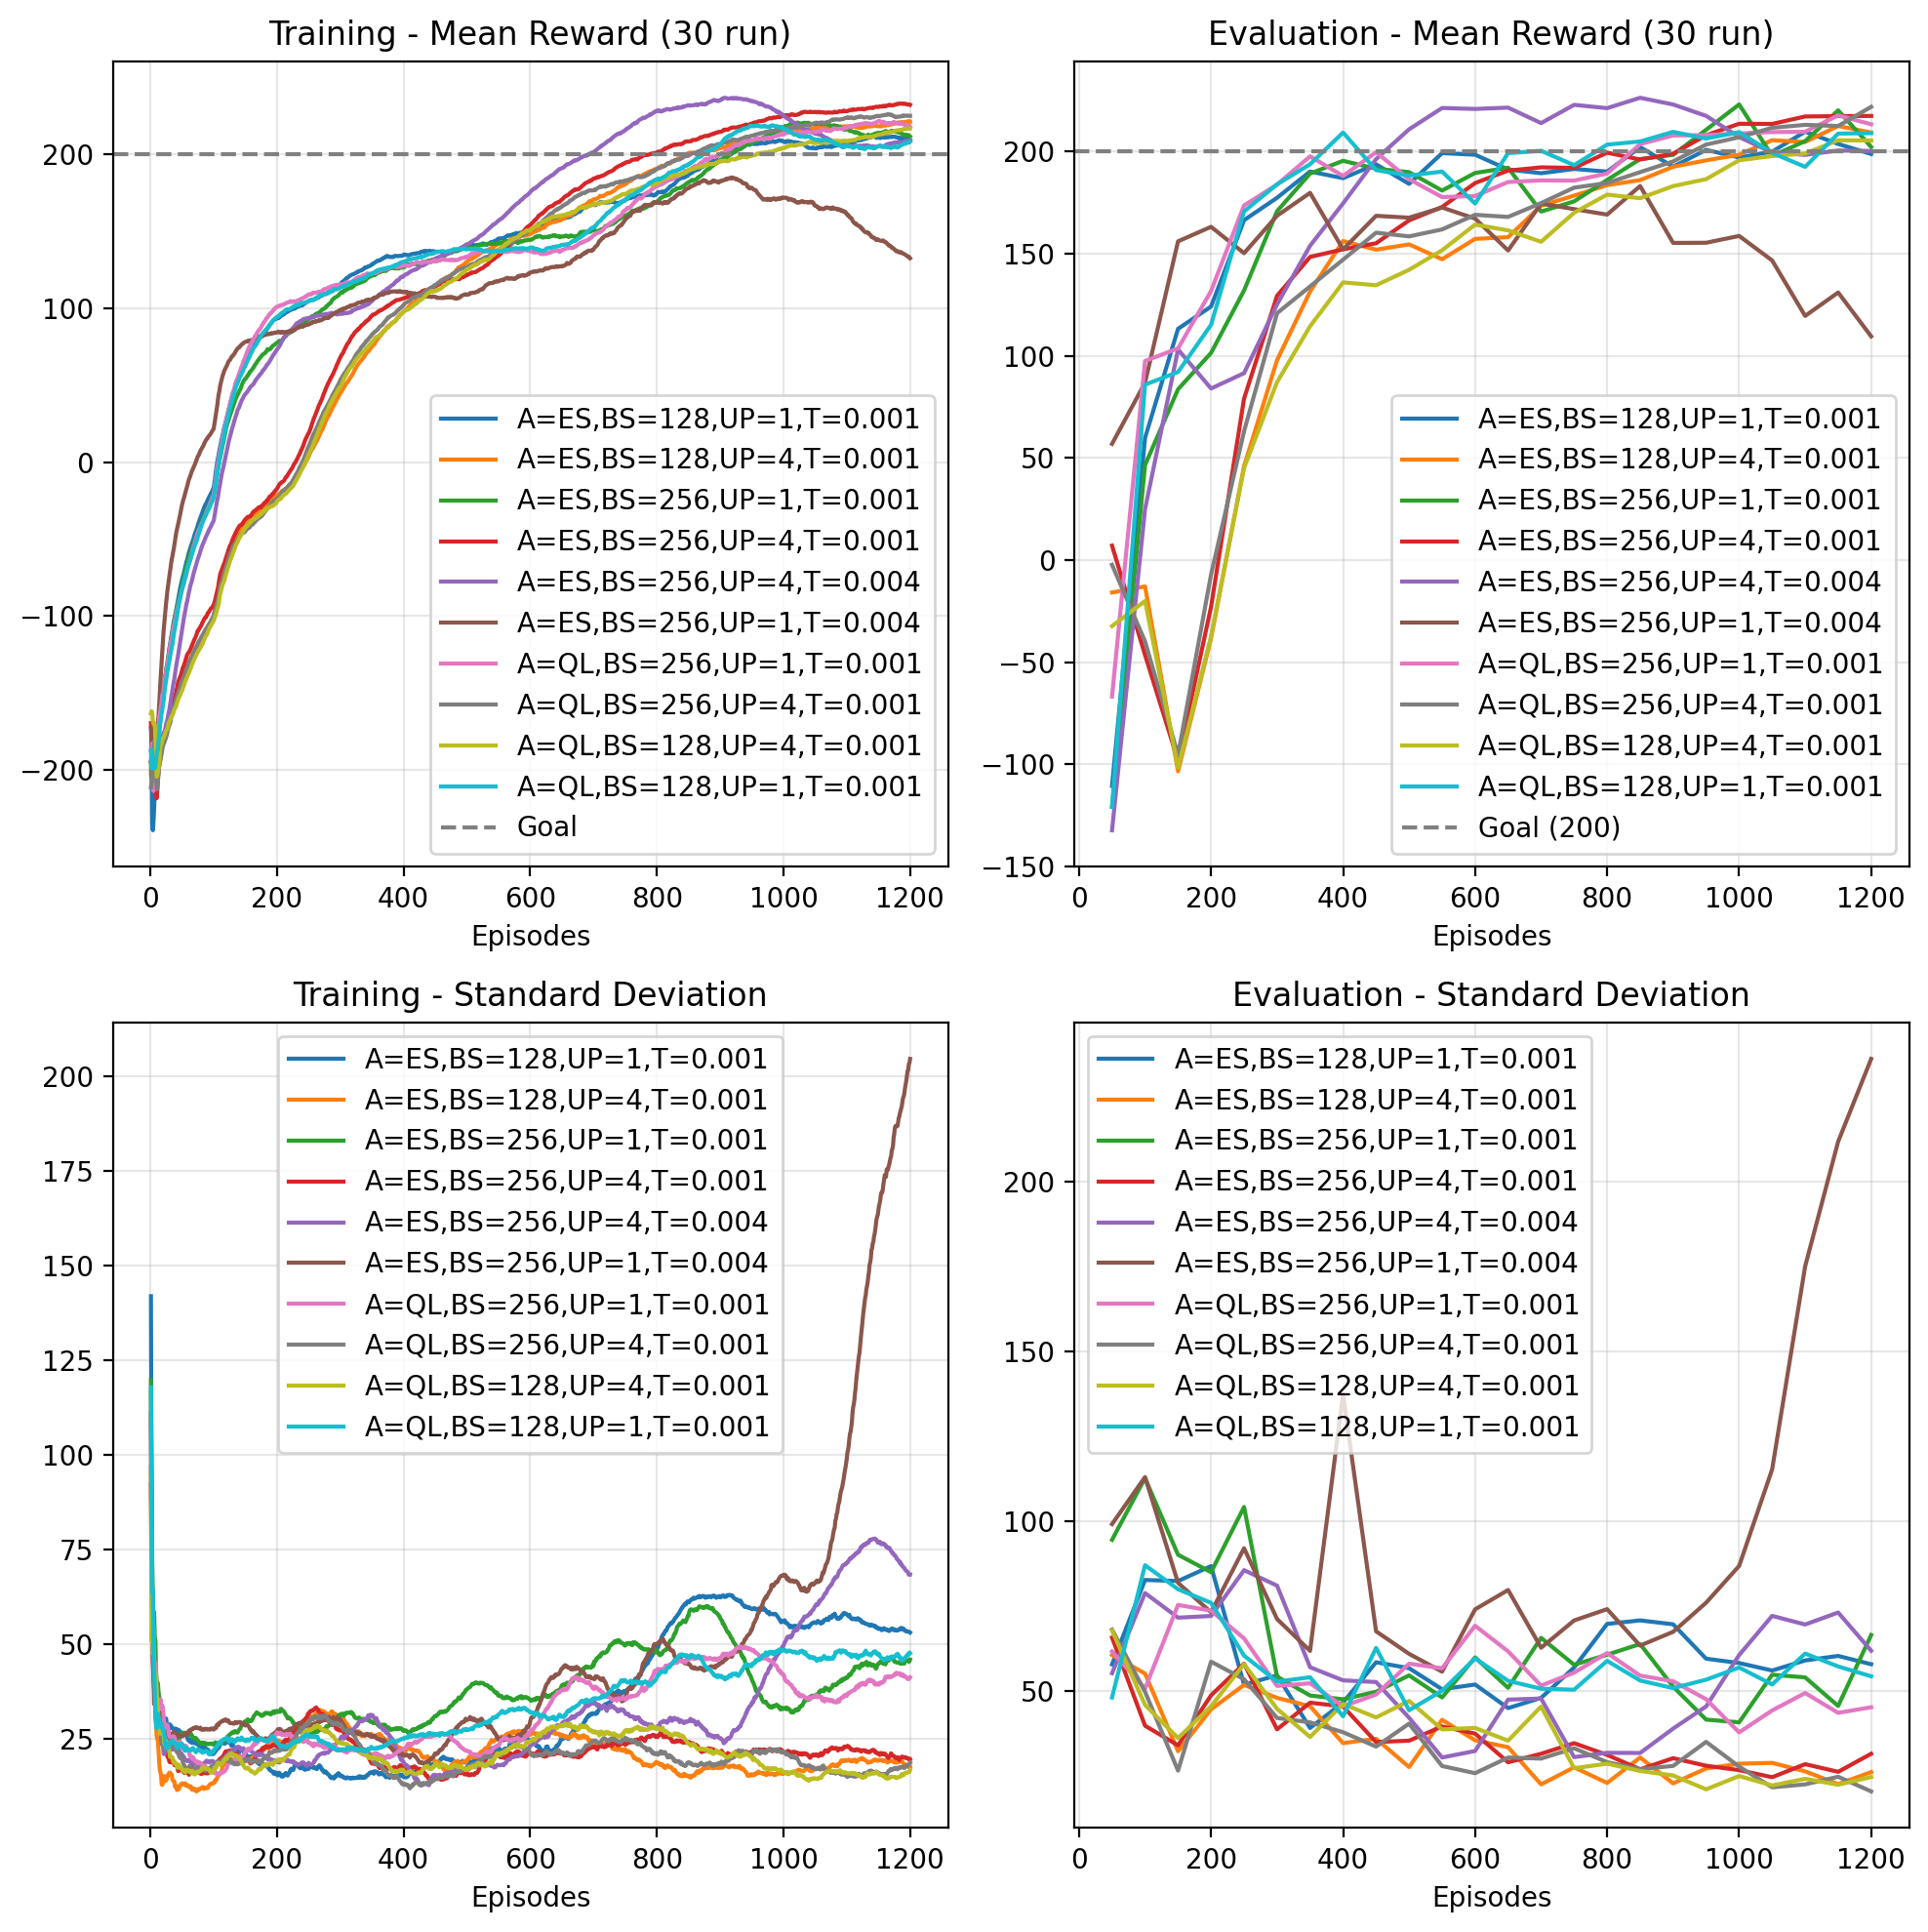

In [180]:
ids = all_ids
techniques = all_techniques
var_attributes = all_var_attributes

plot_rewards_vs_episodes(techniques, ids, var_attributes)

### Plot expected sarsa
Compare:
- batch size: {128, 256}
- update period: {1, 4}
- tau: {1e-3, 4e-3} (restricted to BS=256, UP=4)

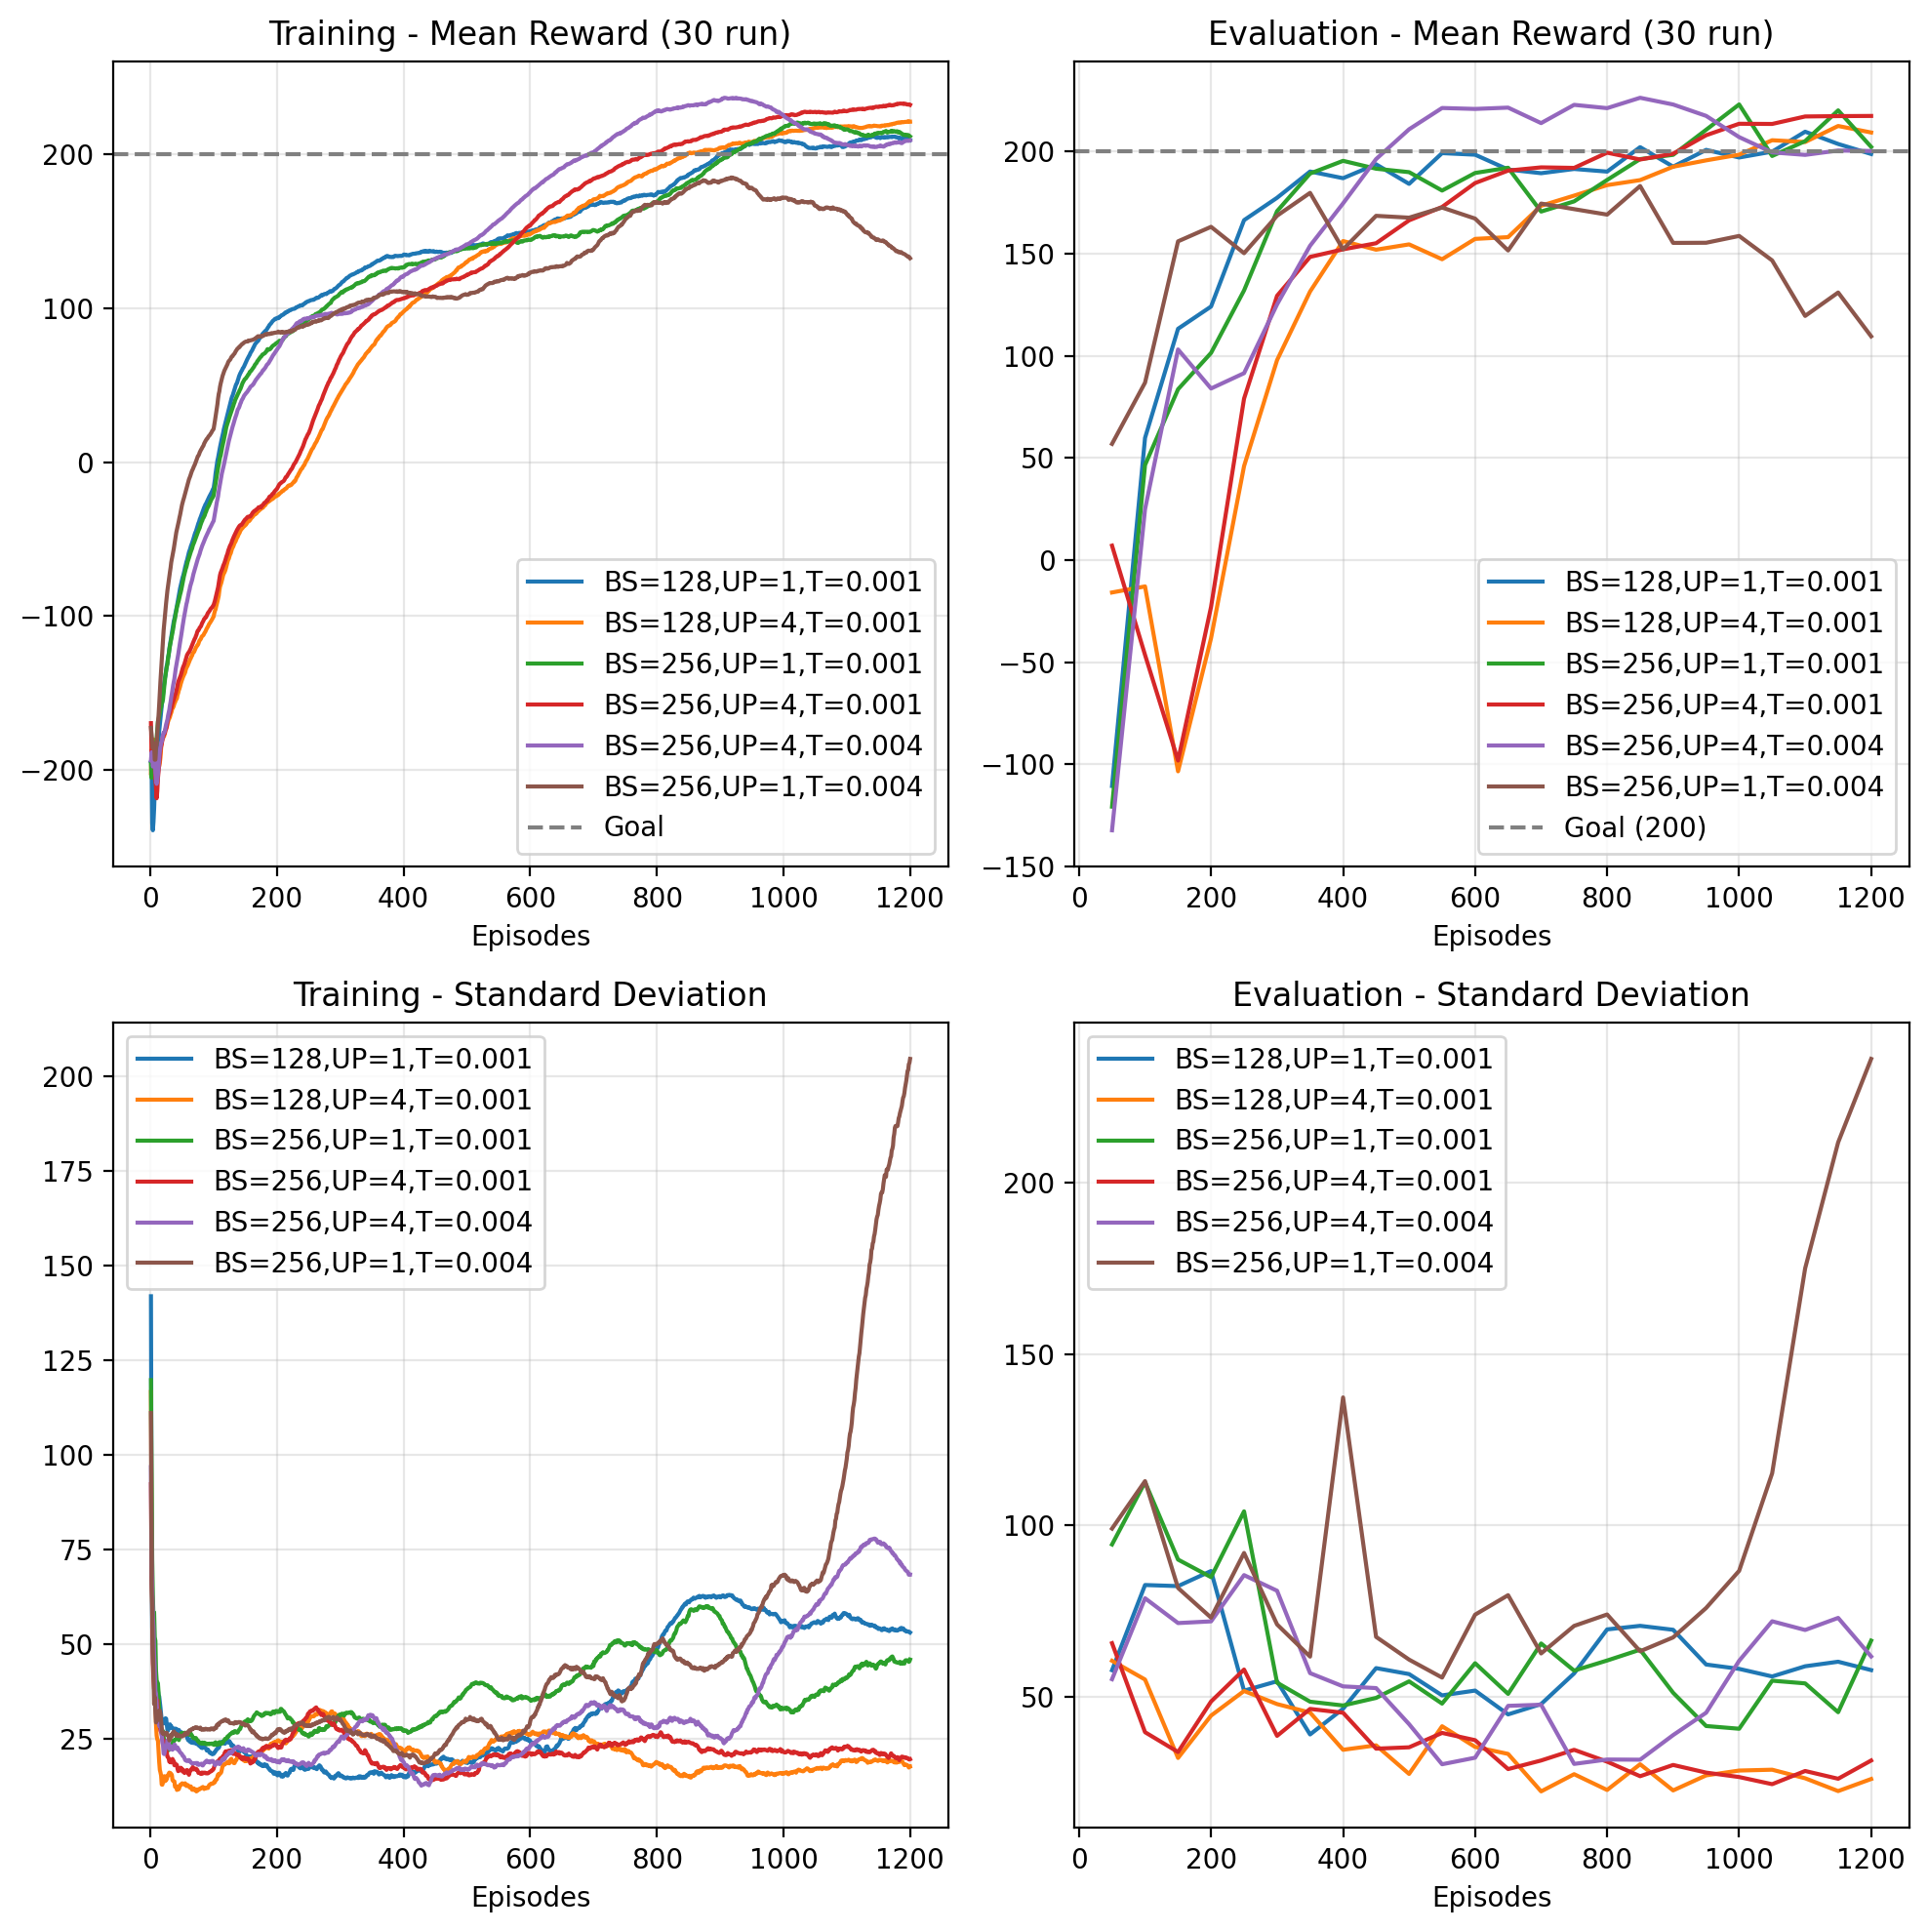

In [181]:
indexes = slice(6)
es_ids = all_ids[indexes]
es_techniques = all_techniques[indexes]
es_var_attributes = all_var_attributes[1:]

plot_rewards_vs_episodes(es_techniques, es_ids, es_var_attributes)

### Plot Q-Learning
Compare:
- batch size: {128, 256}
- update period: {1, 4}

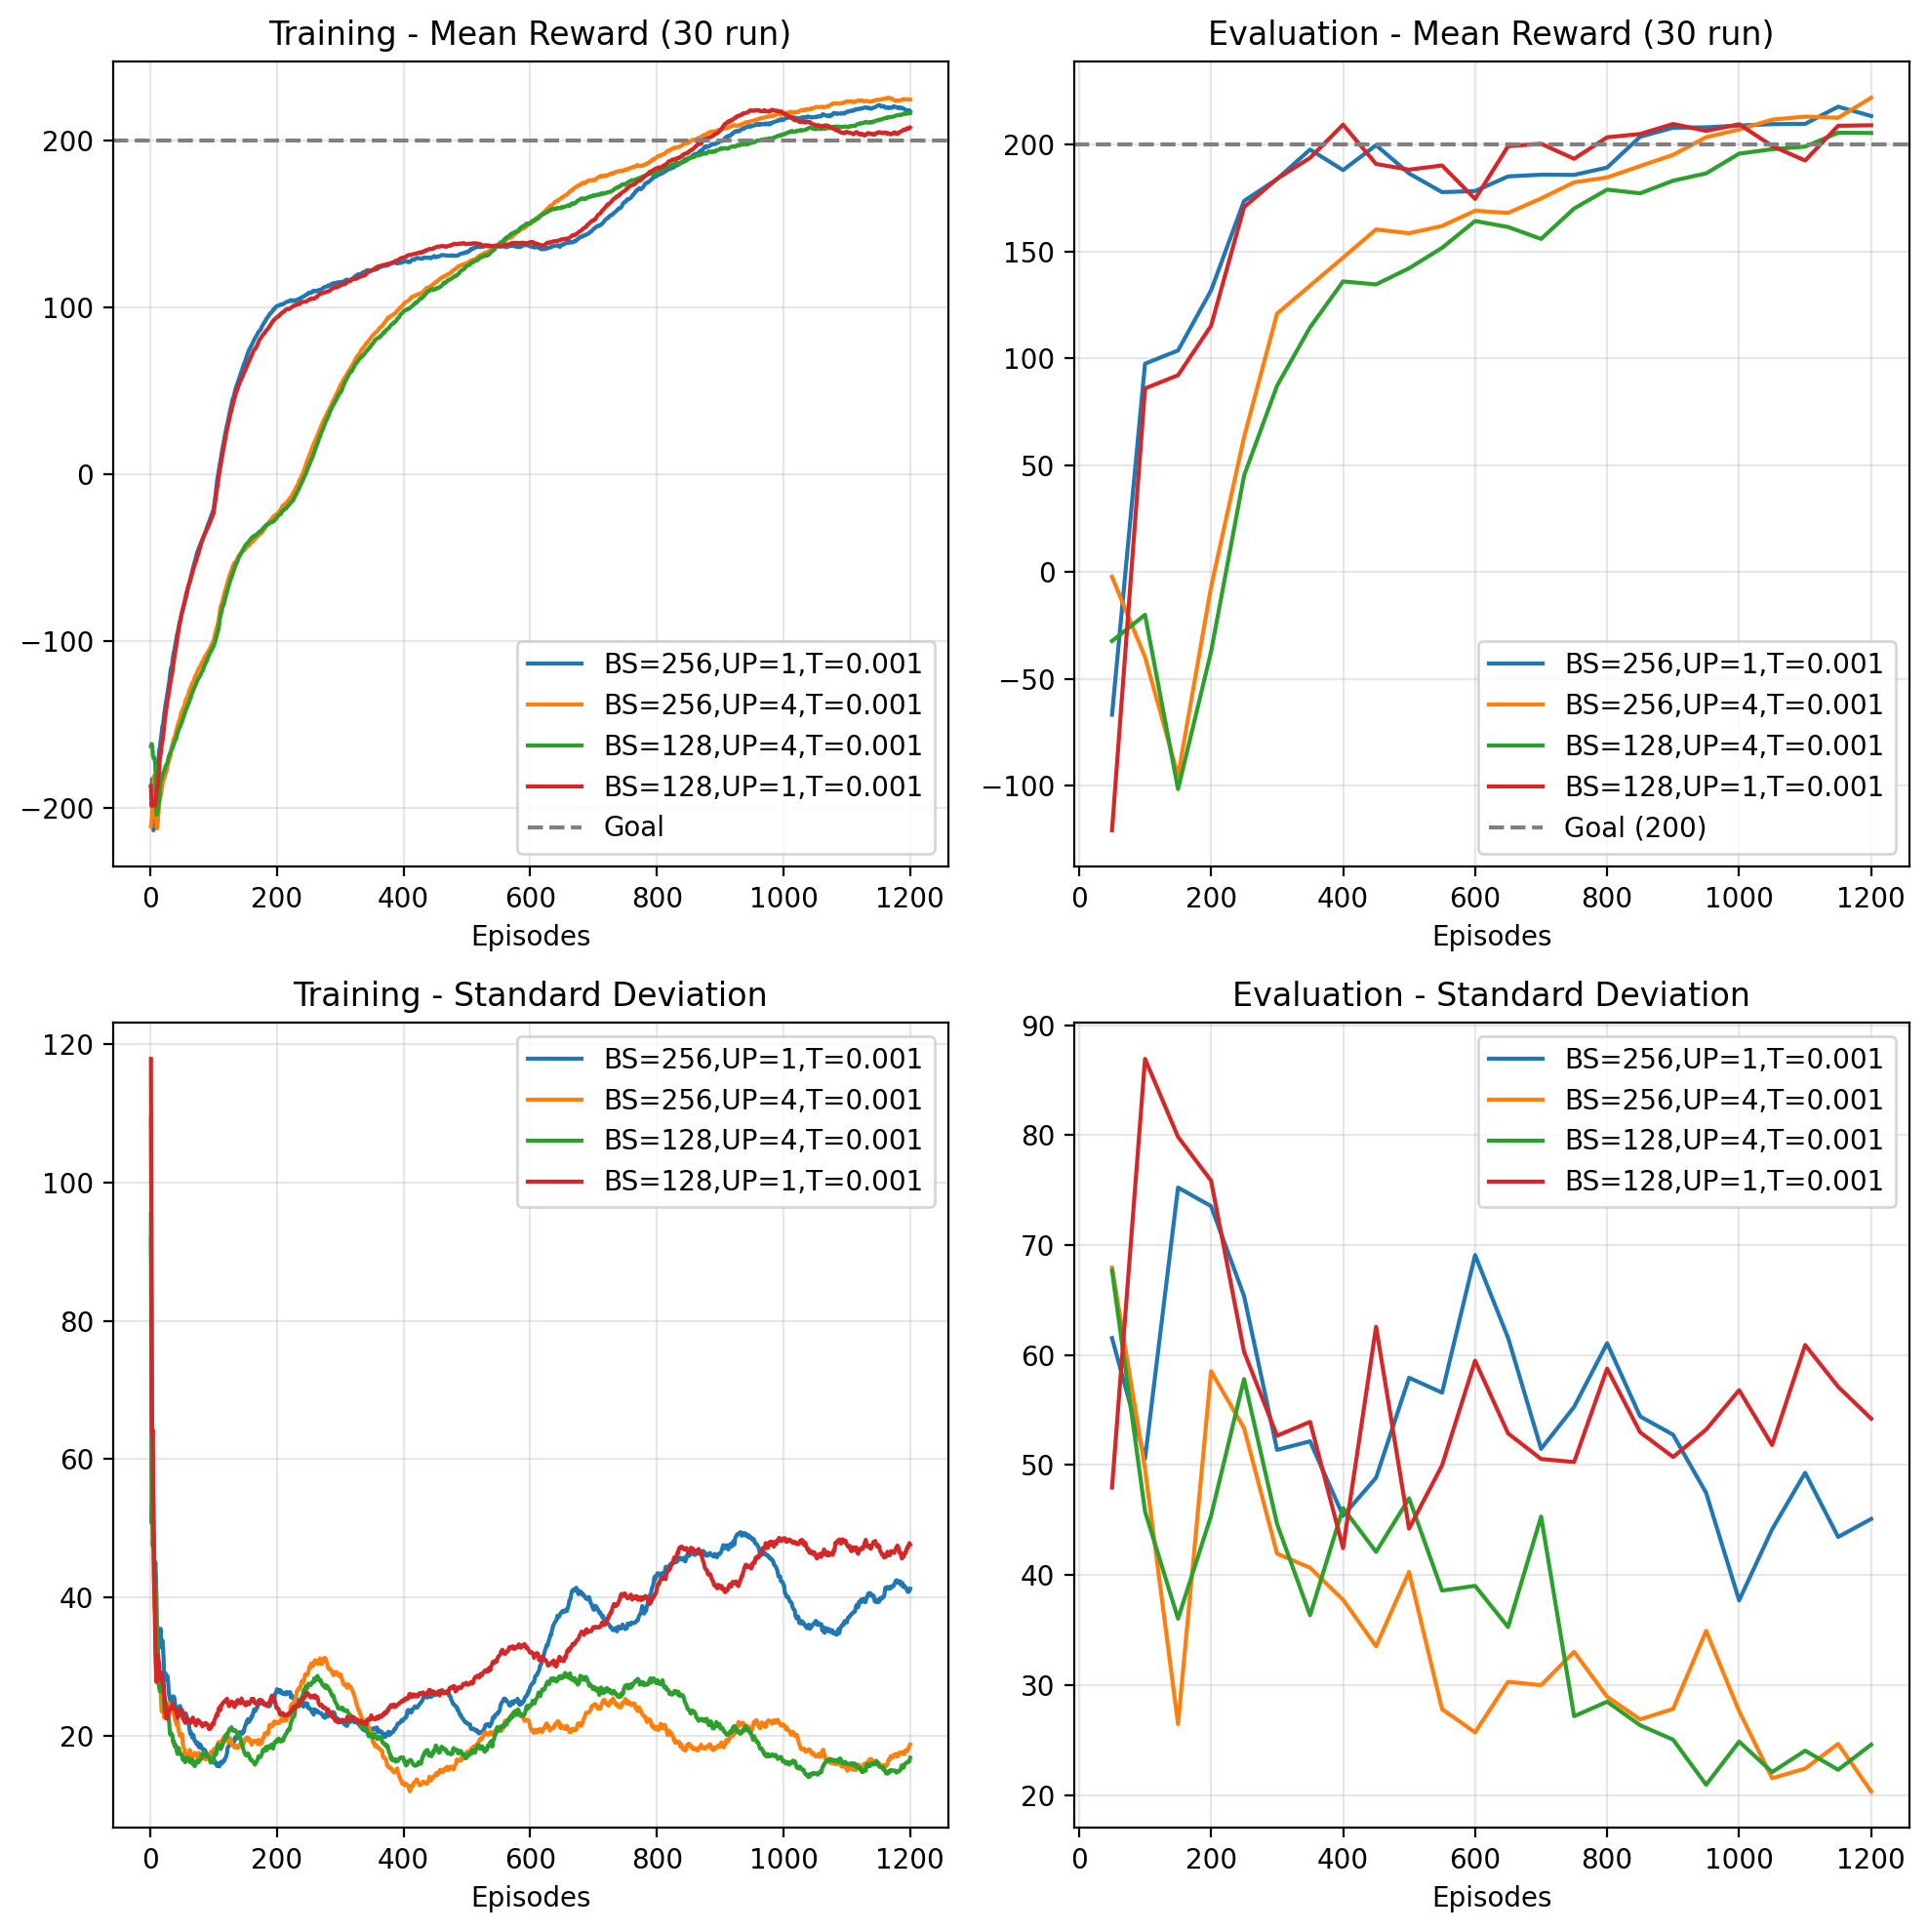

In [182]:
indexes = slice(6, 10)
ql_ids = all_ids[indexes]
ql_techniques = all_techniques[indexes]
ql_var_attributes = all_var_attributes[1:]

plot_rewards_vs_episodes(ql_techniques, ql_ids, ql_var_attributes)

### Plot batch size = 128
Compare:
- algorithm: {expected sarsa, q-learning}
- update period: {1, 4}

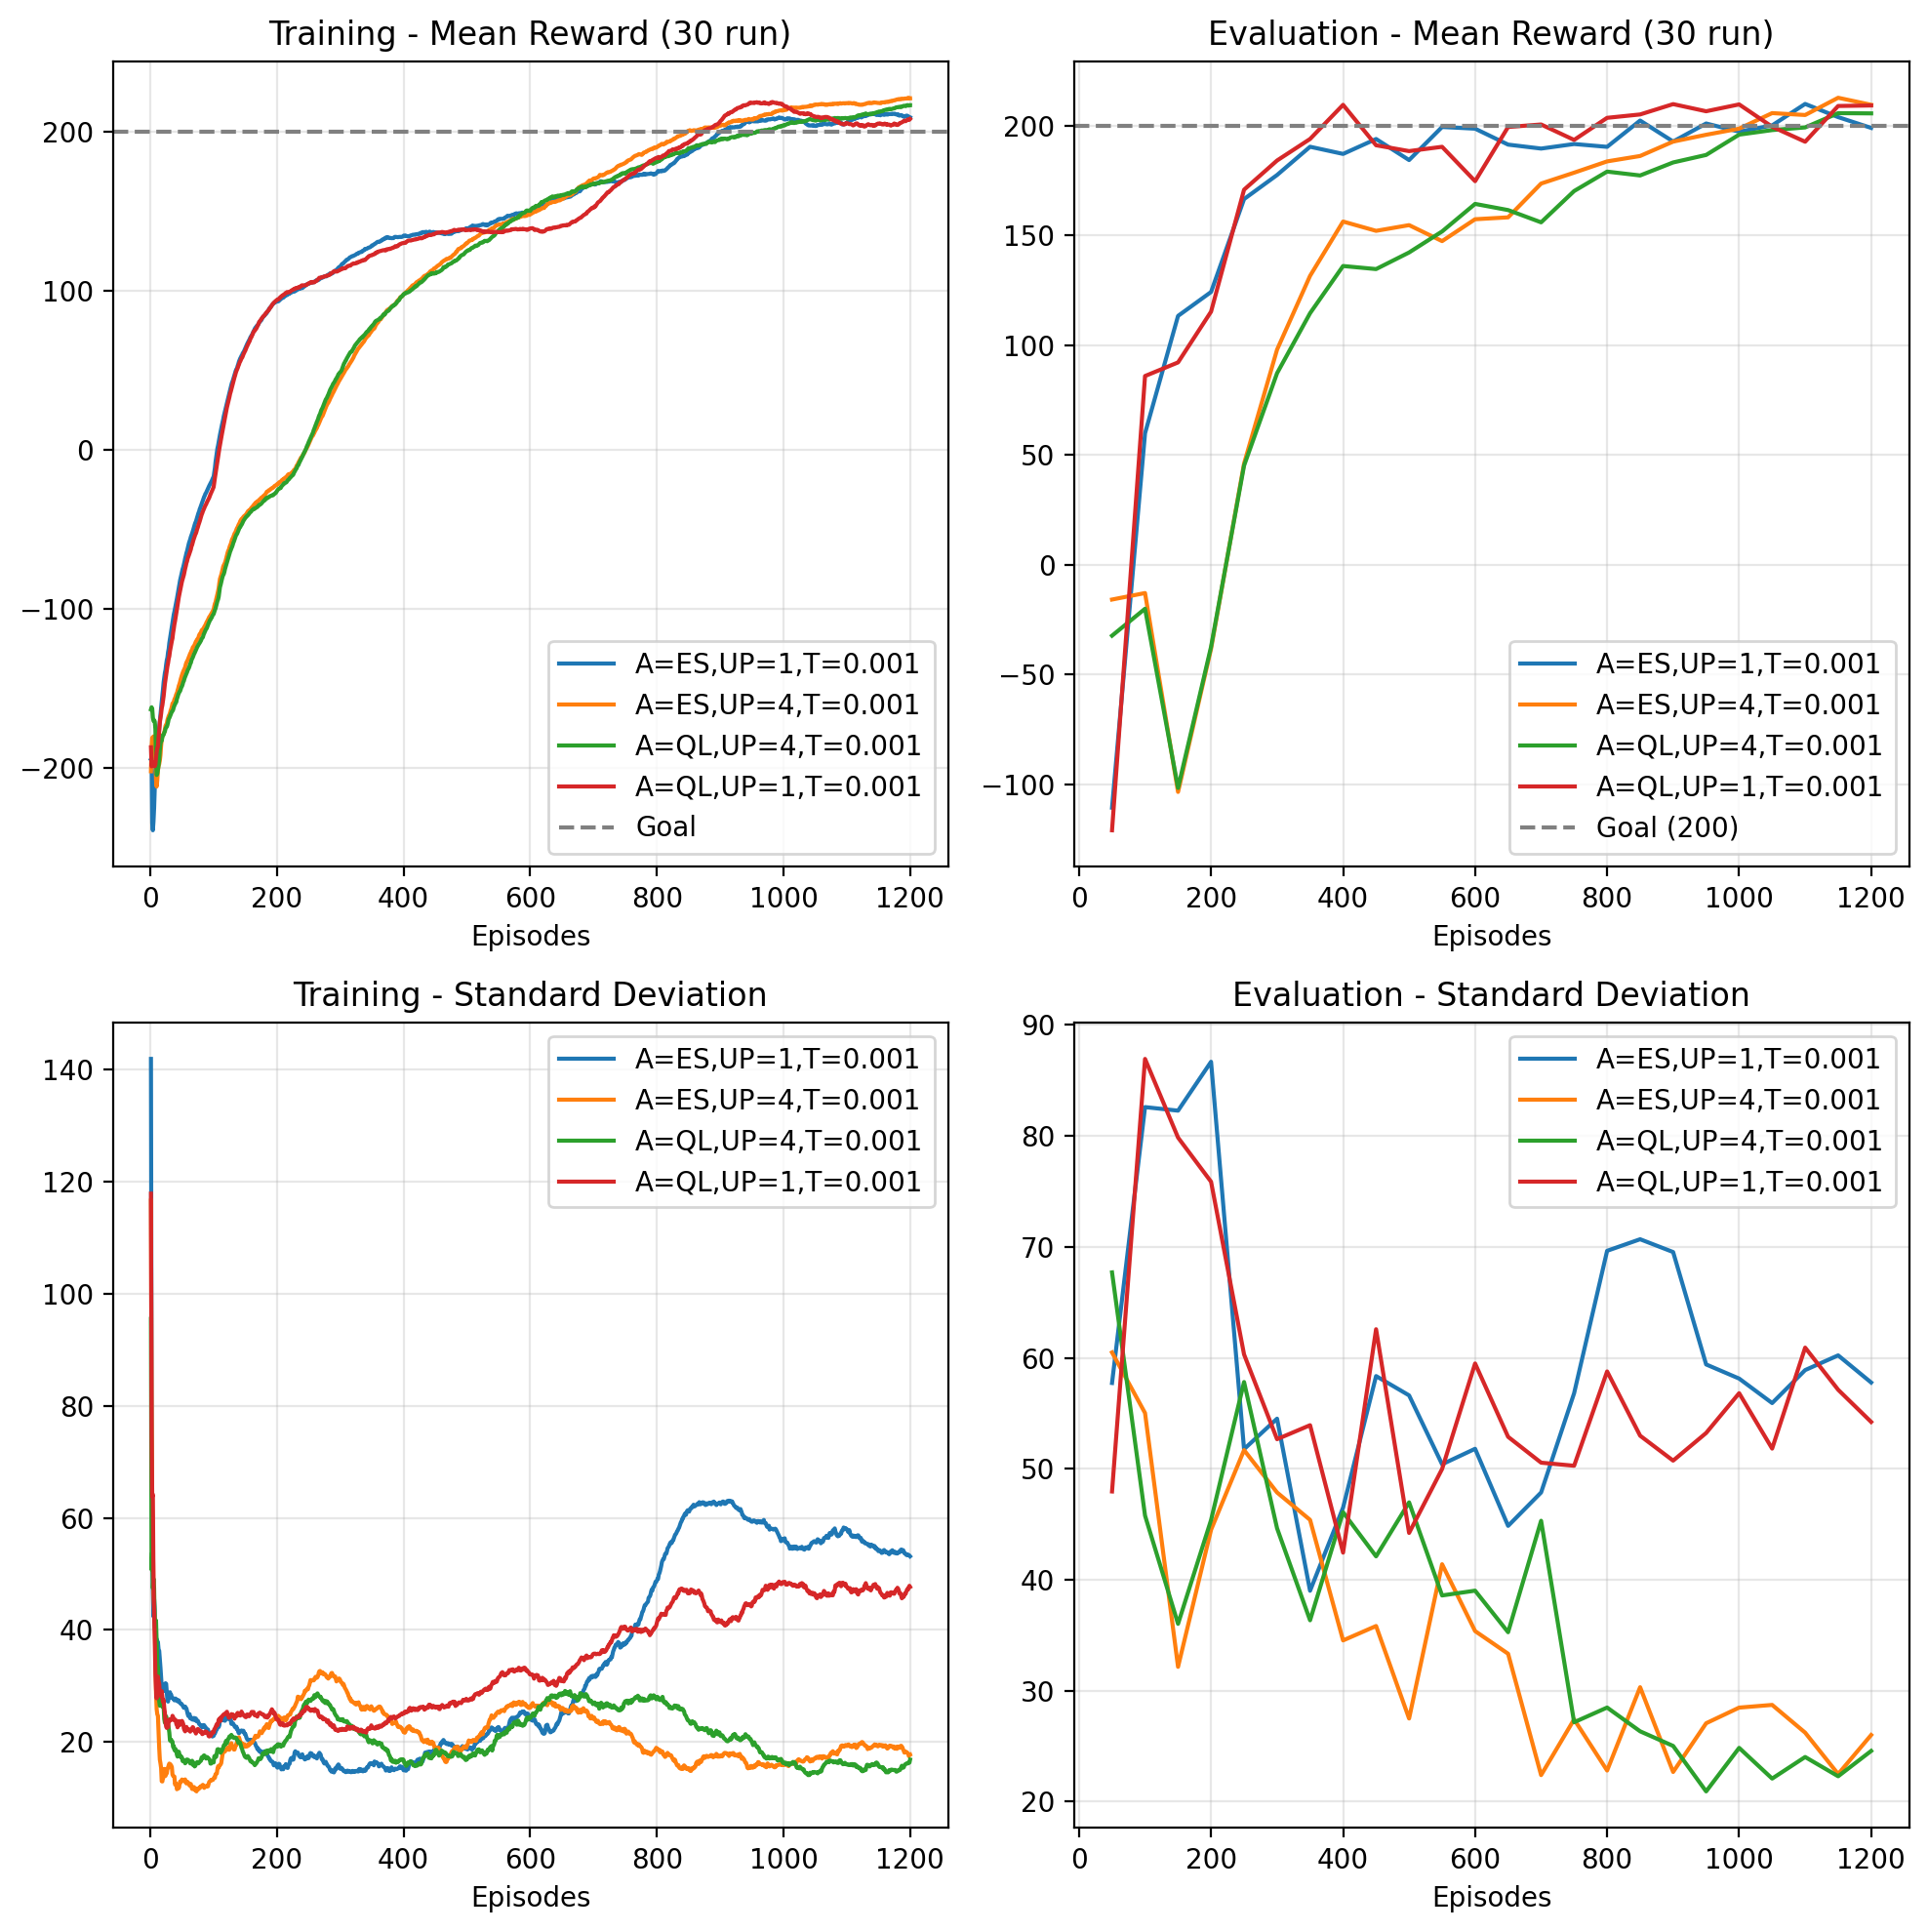

In [183]:
indexes = [0, 1, 8, 9]
bs_128_ids = [all_ids[i] for i in indexes]
bs_128_techniques = [all_techniques[i] for i in indexes]
bs_128_var_attributes = var_attributes[0:1] + var_attributes[2:]

plot_rewards_vs_episodes(bs_128_techniques, bs_128_ids, bs_128_var_attributes)

### Plot batch size = 256
Compare:
- algorithm: {expected sarsa, q-learning}
- update period: {1, 4}

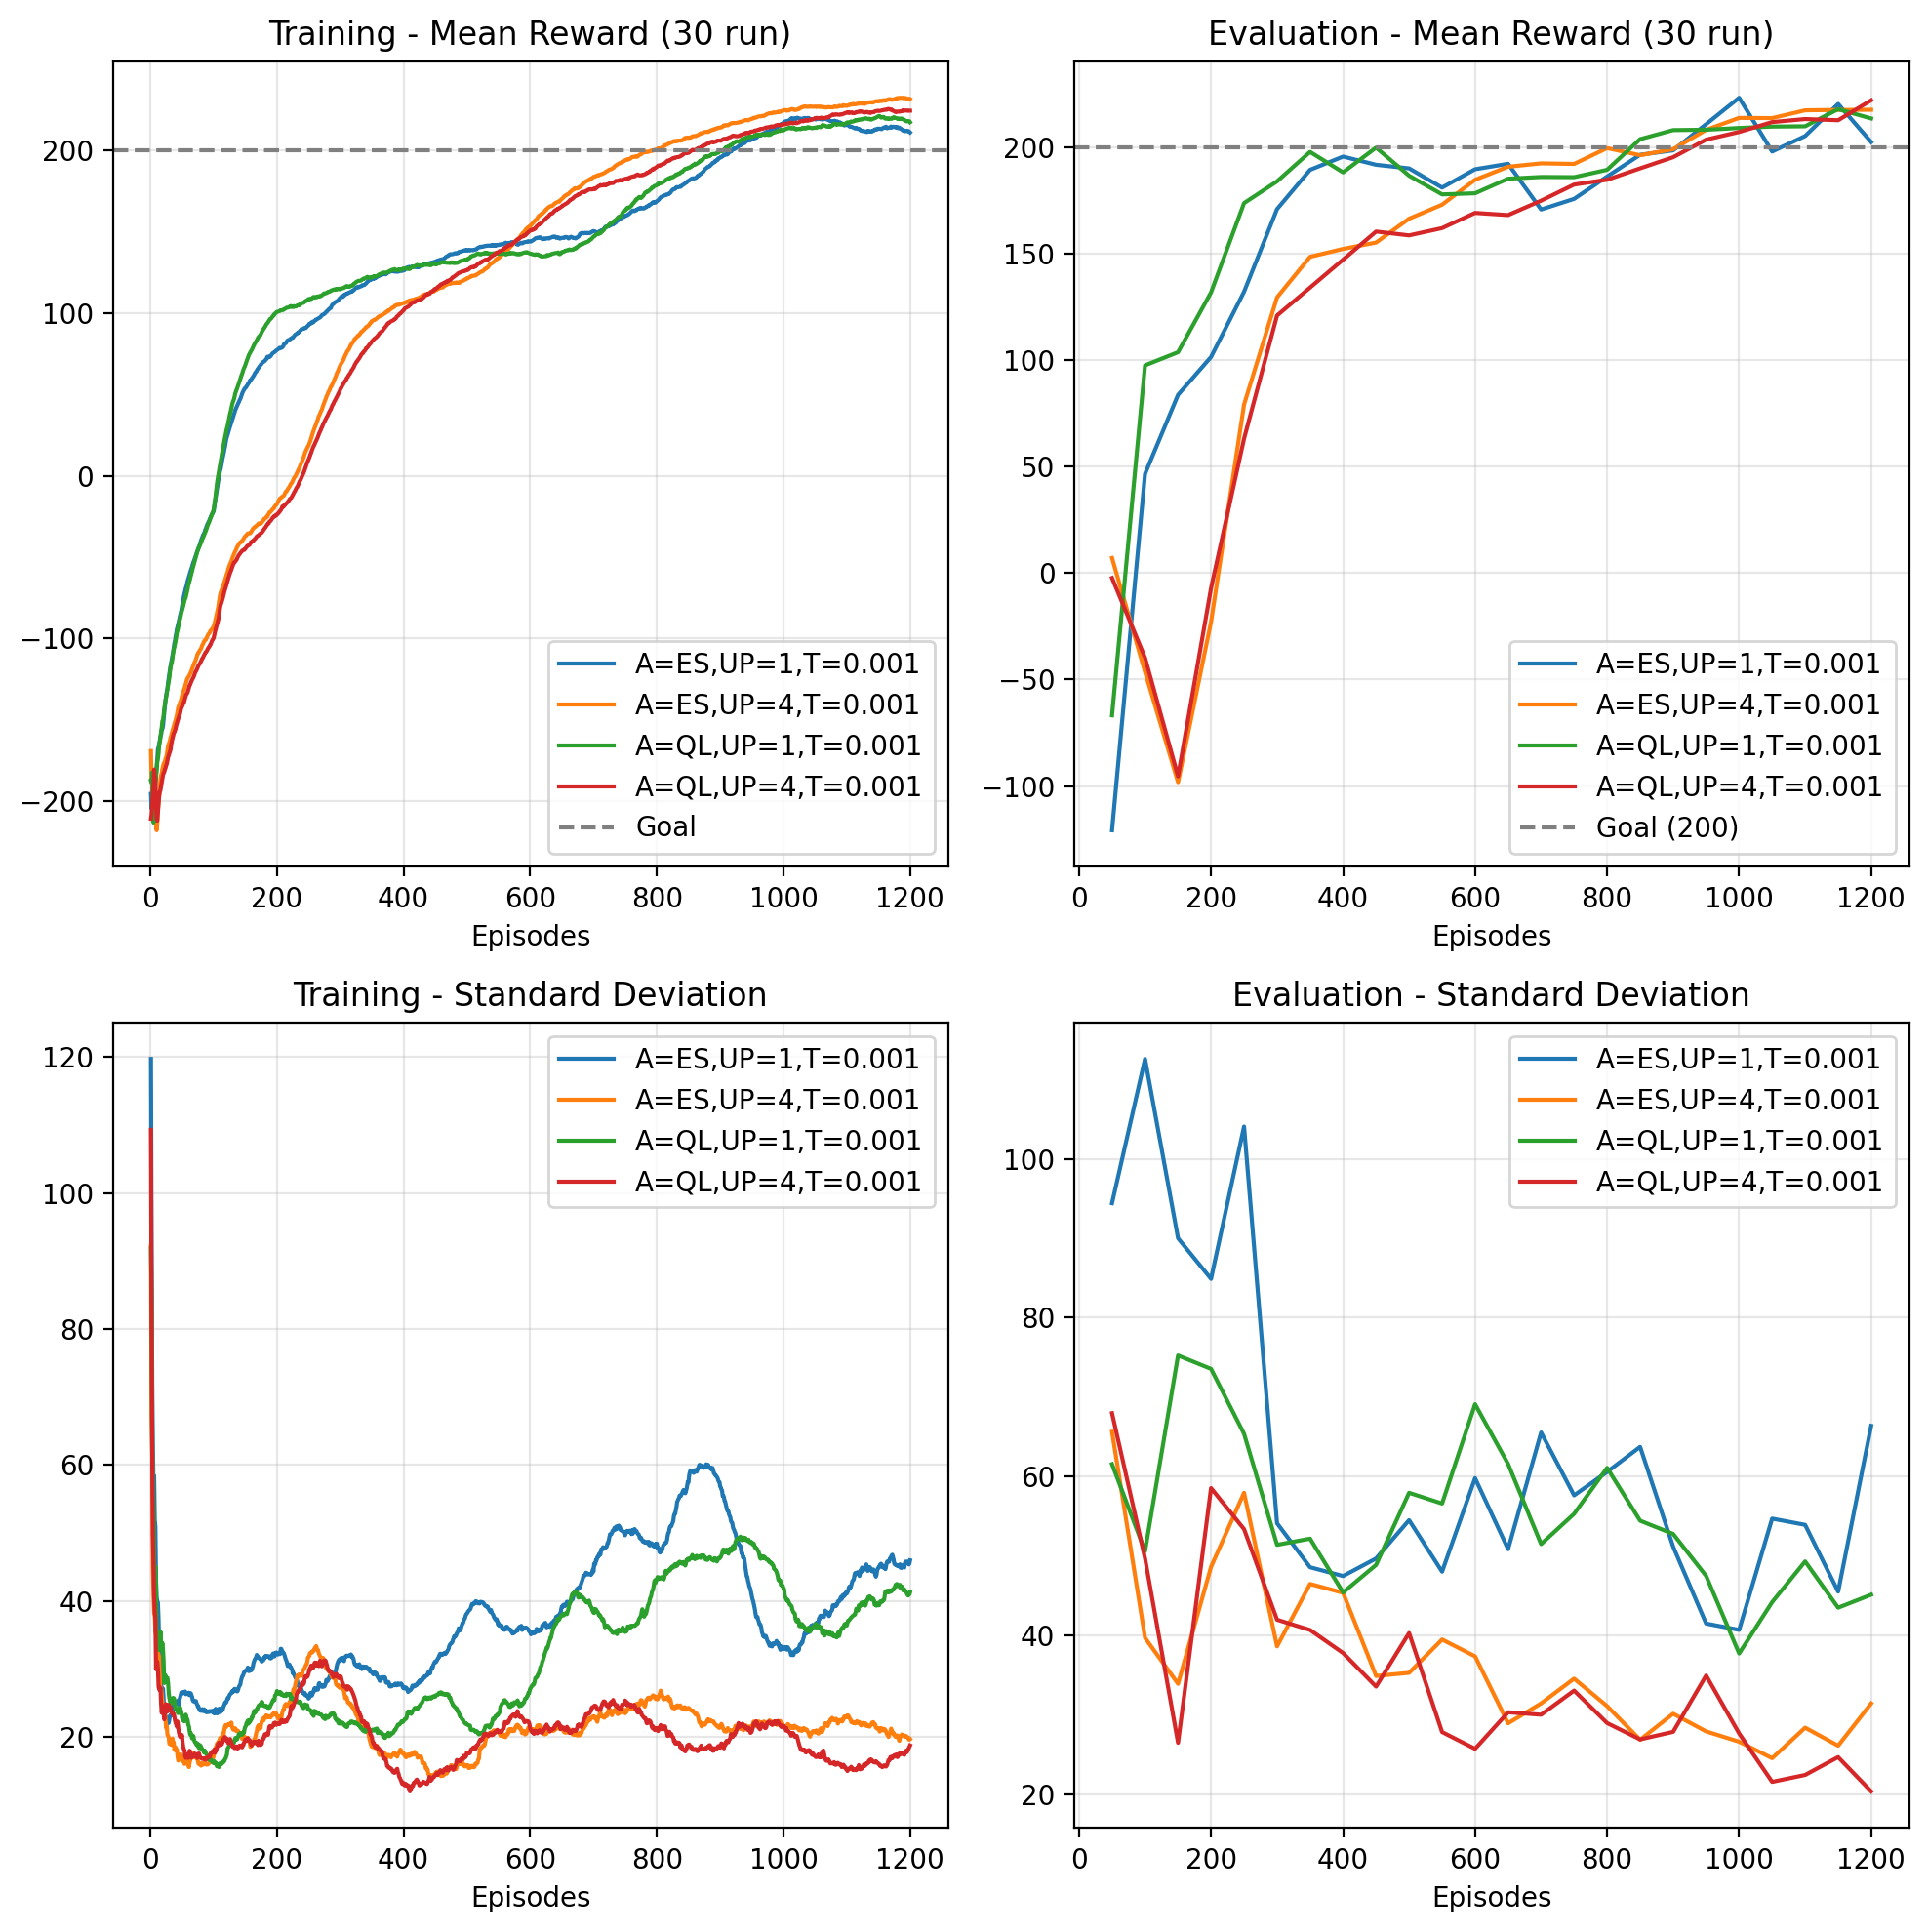

In [184]:
indexes = [2, 3, 6, 7]
bs_256_ids = [all_ids[i] for i in indexes]
bs_256_techniques = [all_techniques[i] for i in indexes]
bs_256_var_attributes = var_attributes[0:1] + var_attributes[2:]

plot_rewards_vs_episodes(bs_256_techniques, bs_256_ids, bs_256_var_attributes)

### Plot update period = 1
Compare:
- algorithm: {expected sarsa, q-learning}
- batch size: {128, 256}

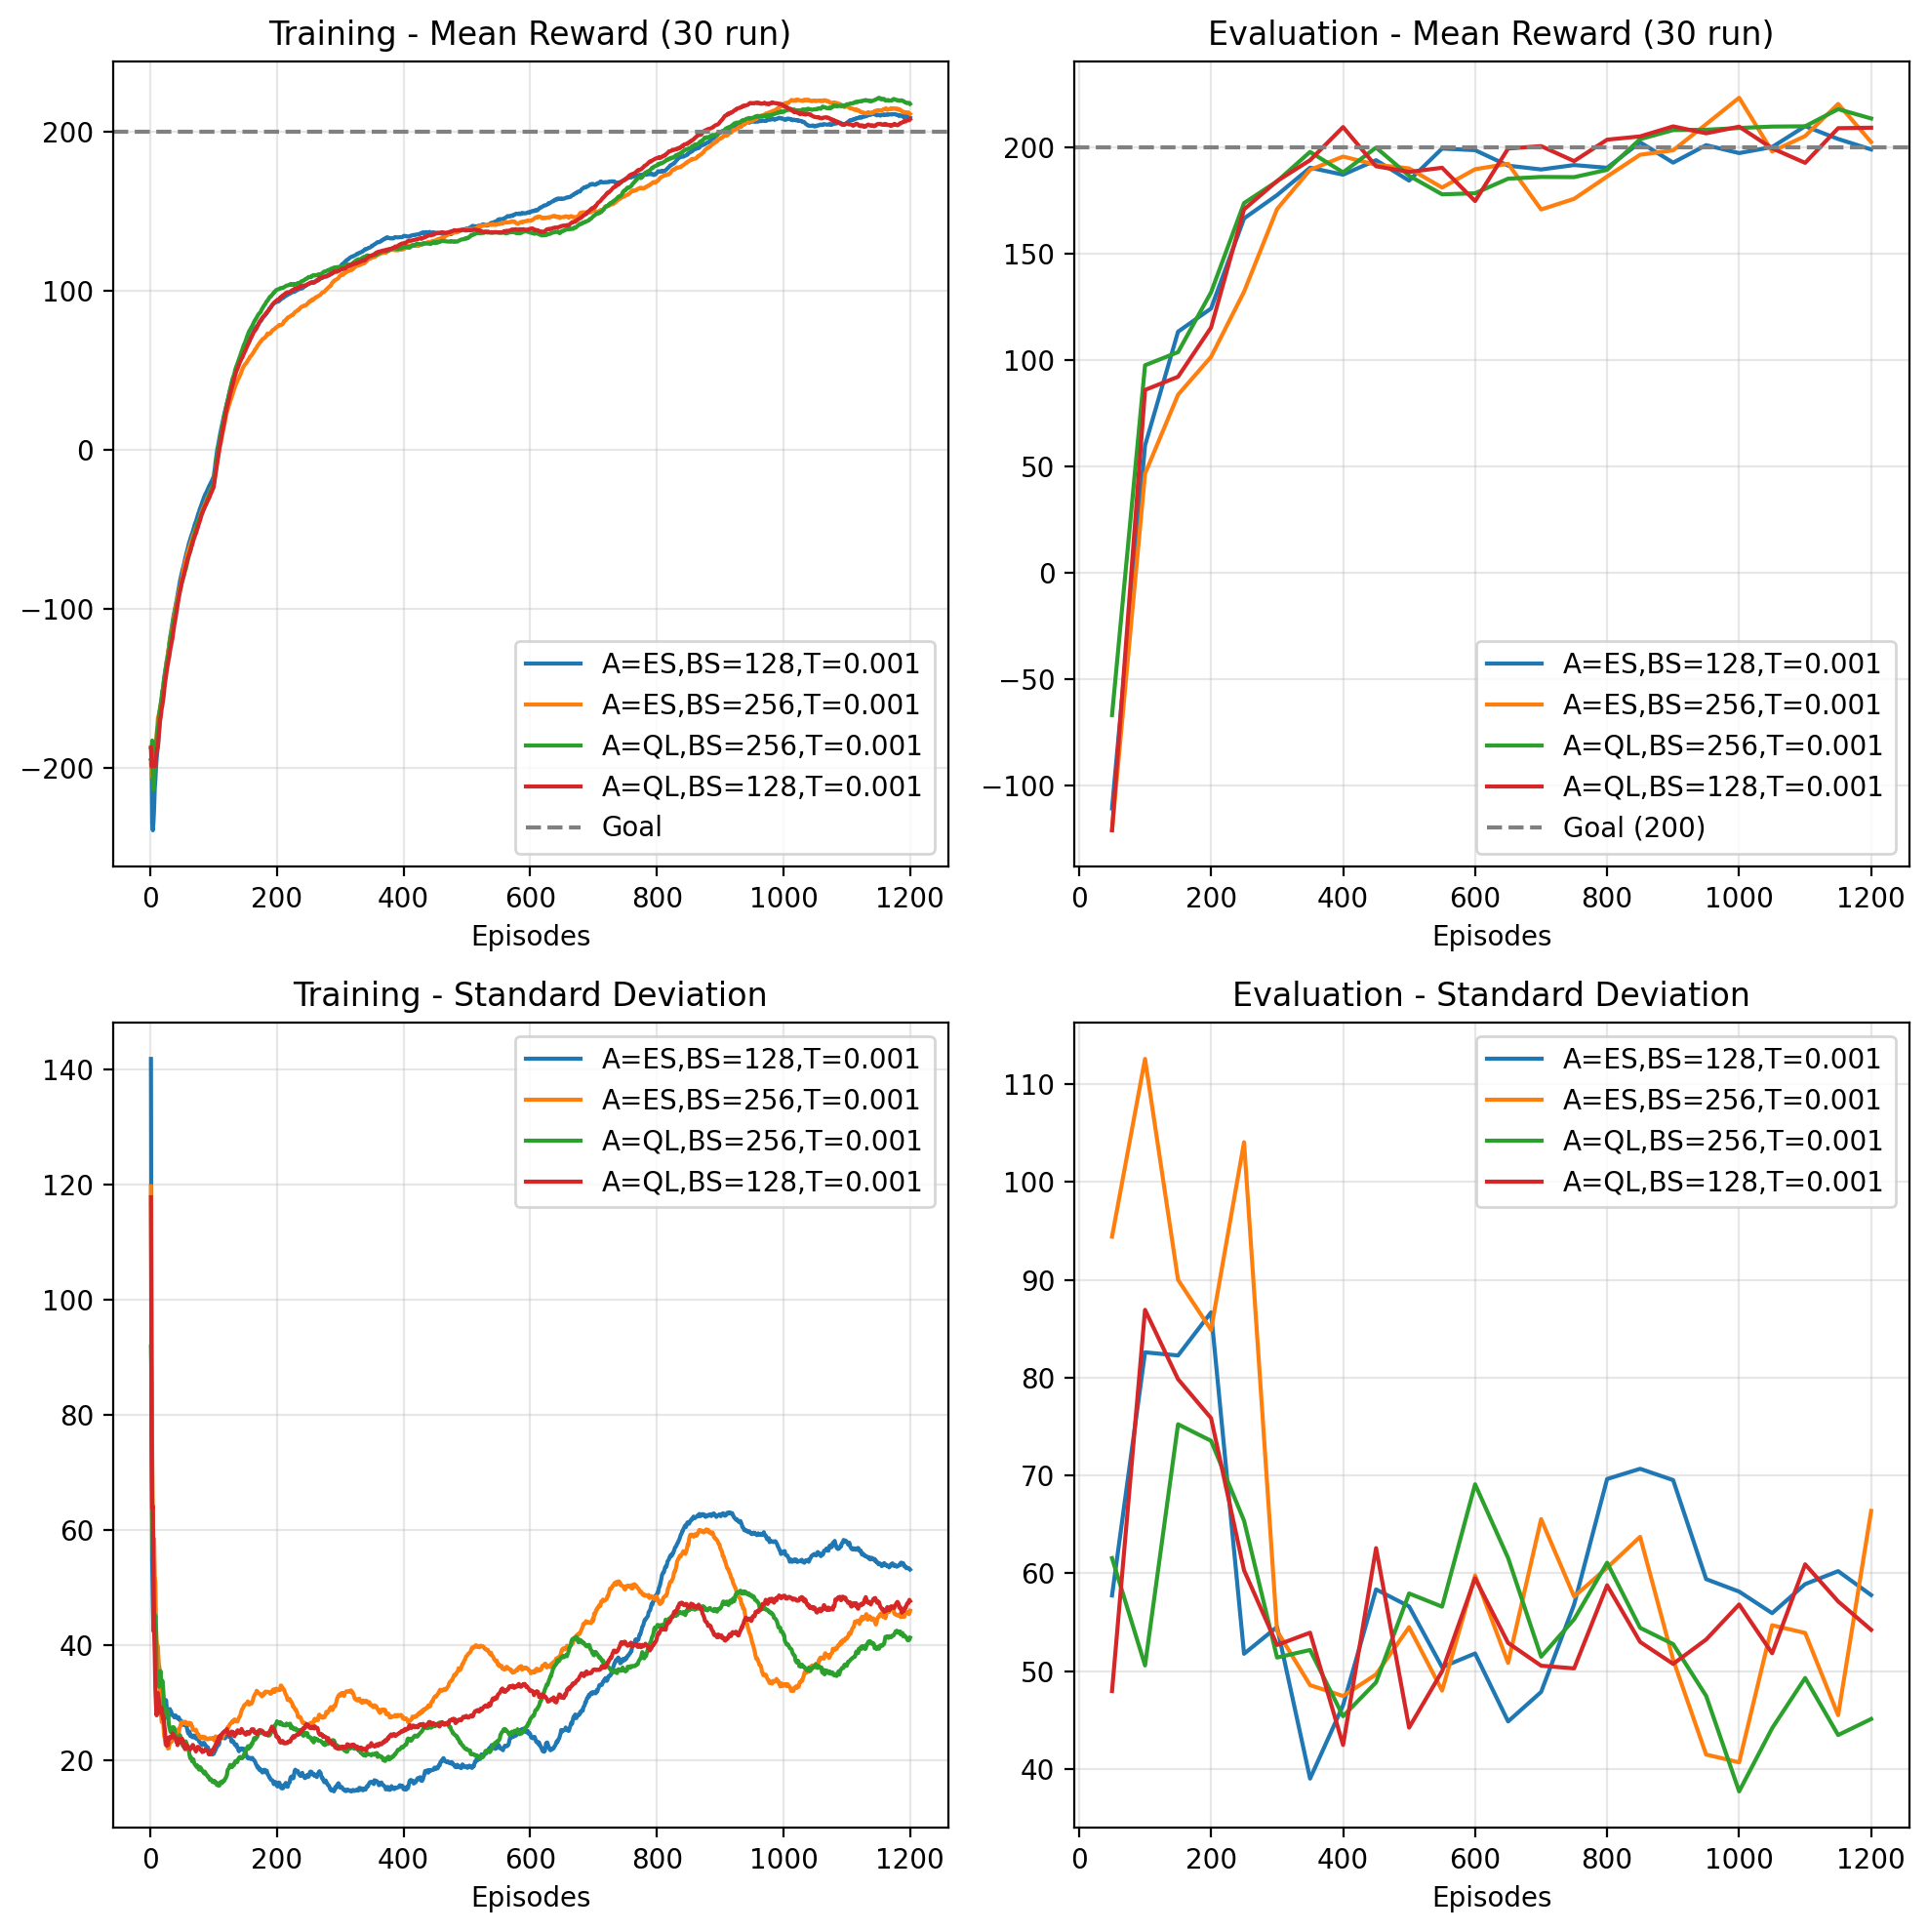

In [185]:
indexes = [0, 2, 6, 9]
up_1_ids = [all_ids[i] for i in indexes]
up_1_techniques = [all_techniques[i] for i in indexes]
up_1_var_attributes = var_attributes[0:2] + var_attributes[3:]
plot_rewards_vs_episodes(up_1_techniques, up_1_ids, up_1_var_attributes)

### Plot update period = 4
Compare:
- algorithm: {expected sarsa, q-learning}
- batch size: {128, 256}

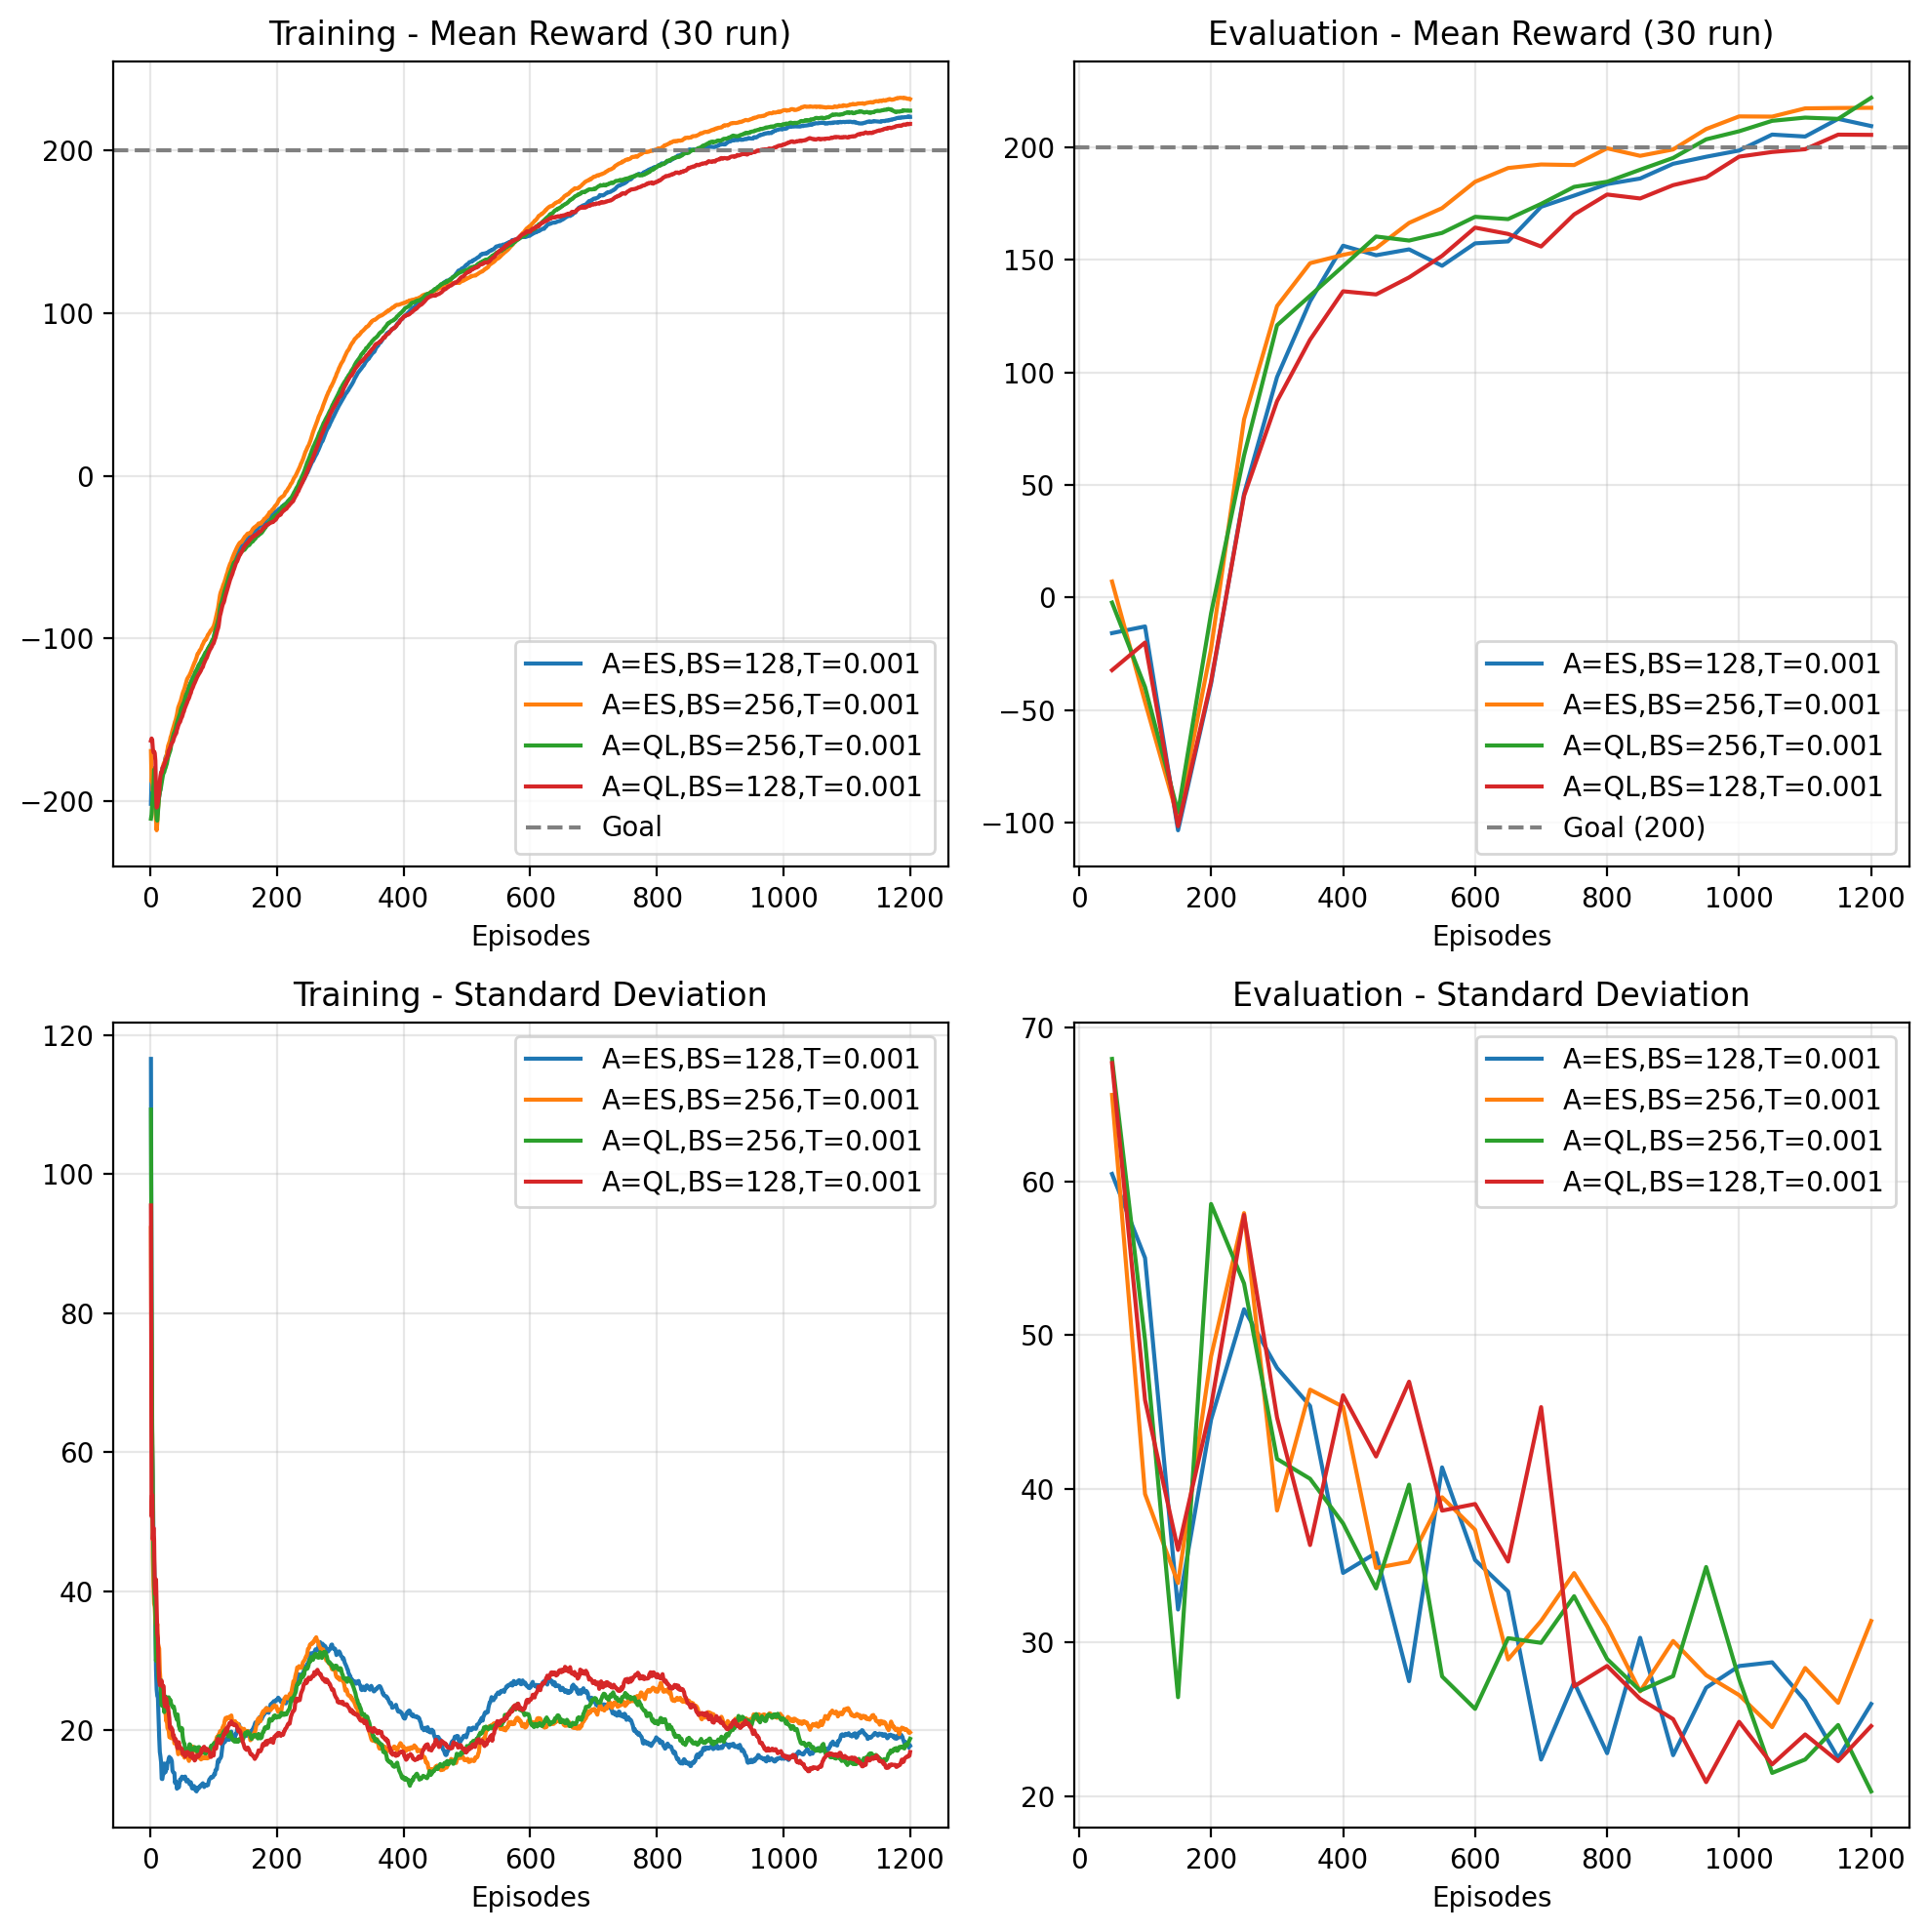

In [186]:
indexes = [1, 3, 7, 8]
up_4_ids = [all_ids[i] for i in indexes]
up_4_techniques = [all_techniques[i] for i in indexes]
up_4_var_attributes = var_attributes[0:2] + var_attributes[3:]
plot_rewards_vs_episodes(up_4_techniques, up_4_ids, up_4_var_attributes)

### Plot algorithm = expected sarsa and batch size = 128
Compare:
- update period: {1, 4}

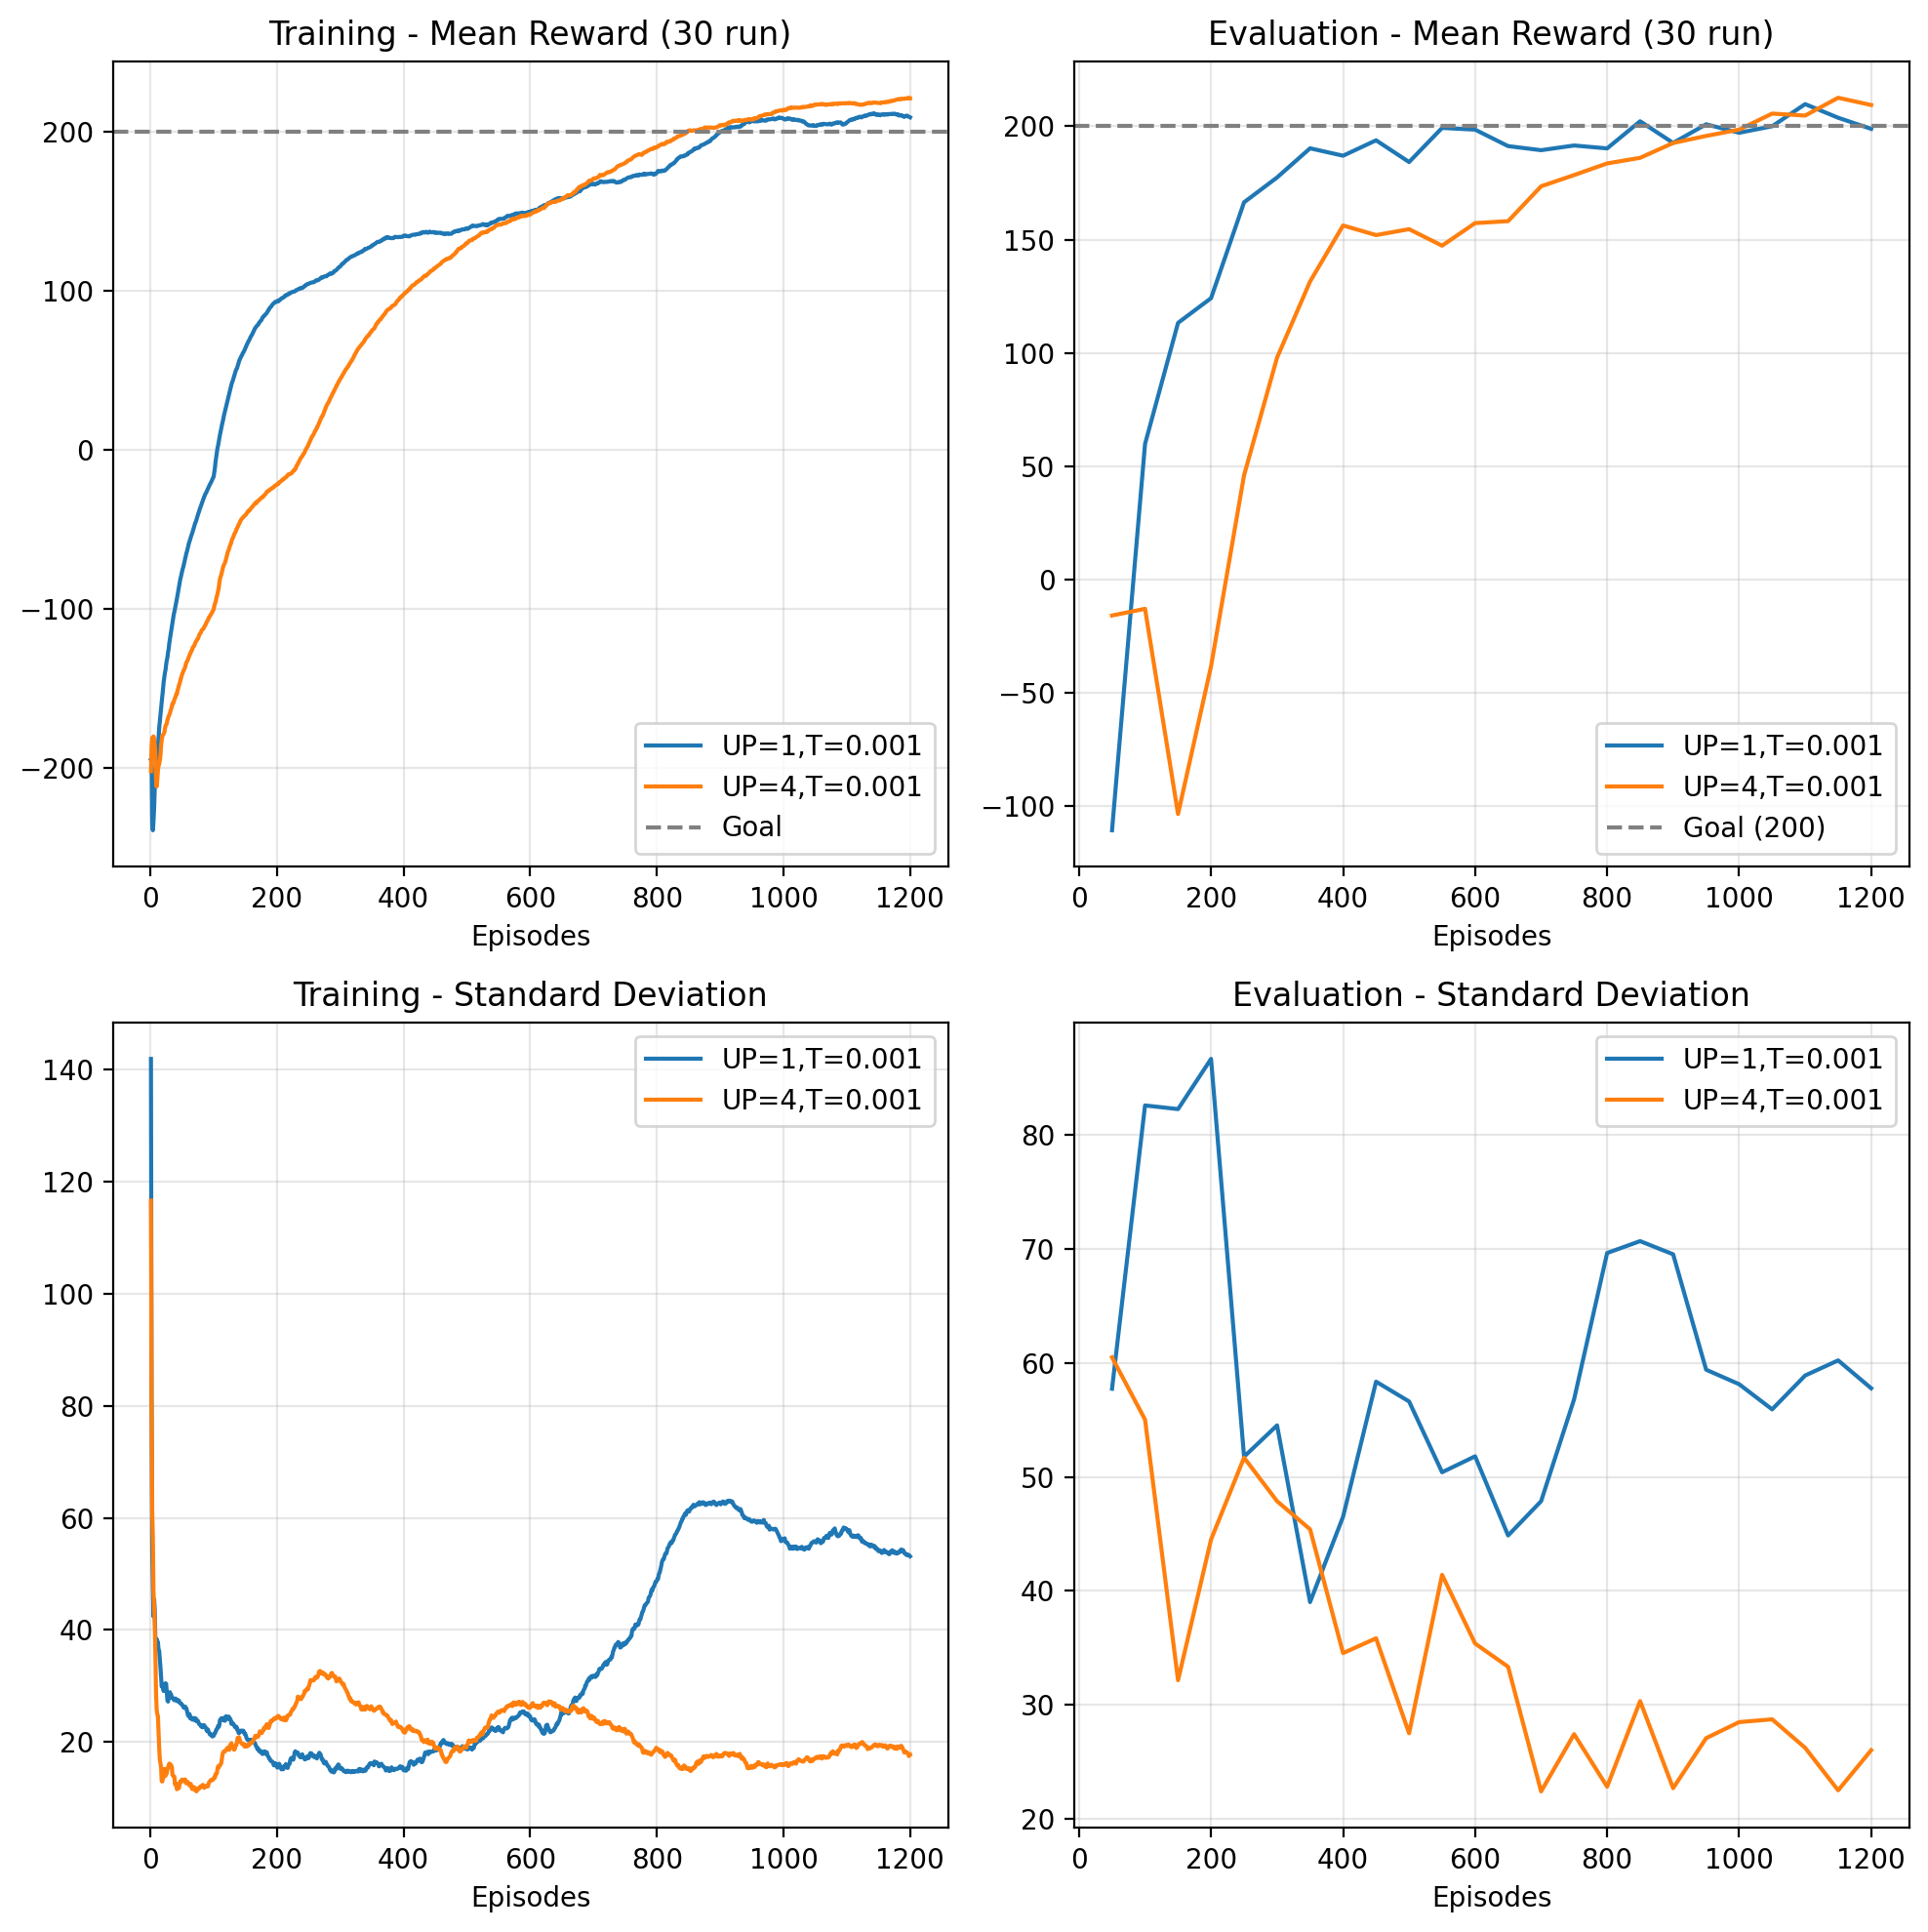

In [187]:
indexes = [0, 1]
es_bs_128_ids = [all_ids[i] for i in indexes]
es_bs_128_techniques = [all_techniques[i] for i in indexes]
es_bs_128_var_attributes = var_attributes[2:]
plot_rewards_vs_episodes(es_bs_128_techniques, es_bs_128_ids, es_bs_128_var_attributes)

### Plot algorithm = expected sarsa and batch size = 256
Compare:
- update period: {1, 4}

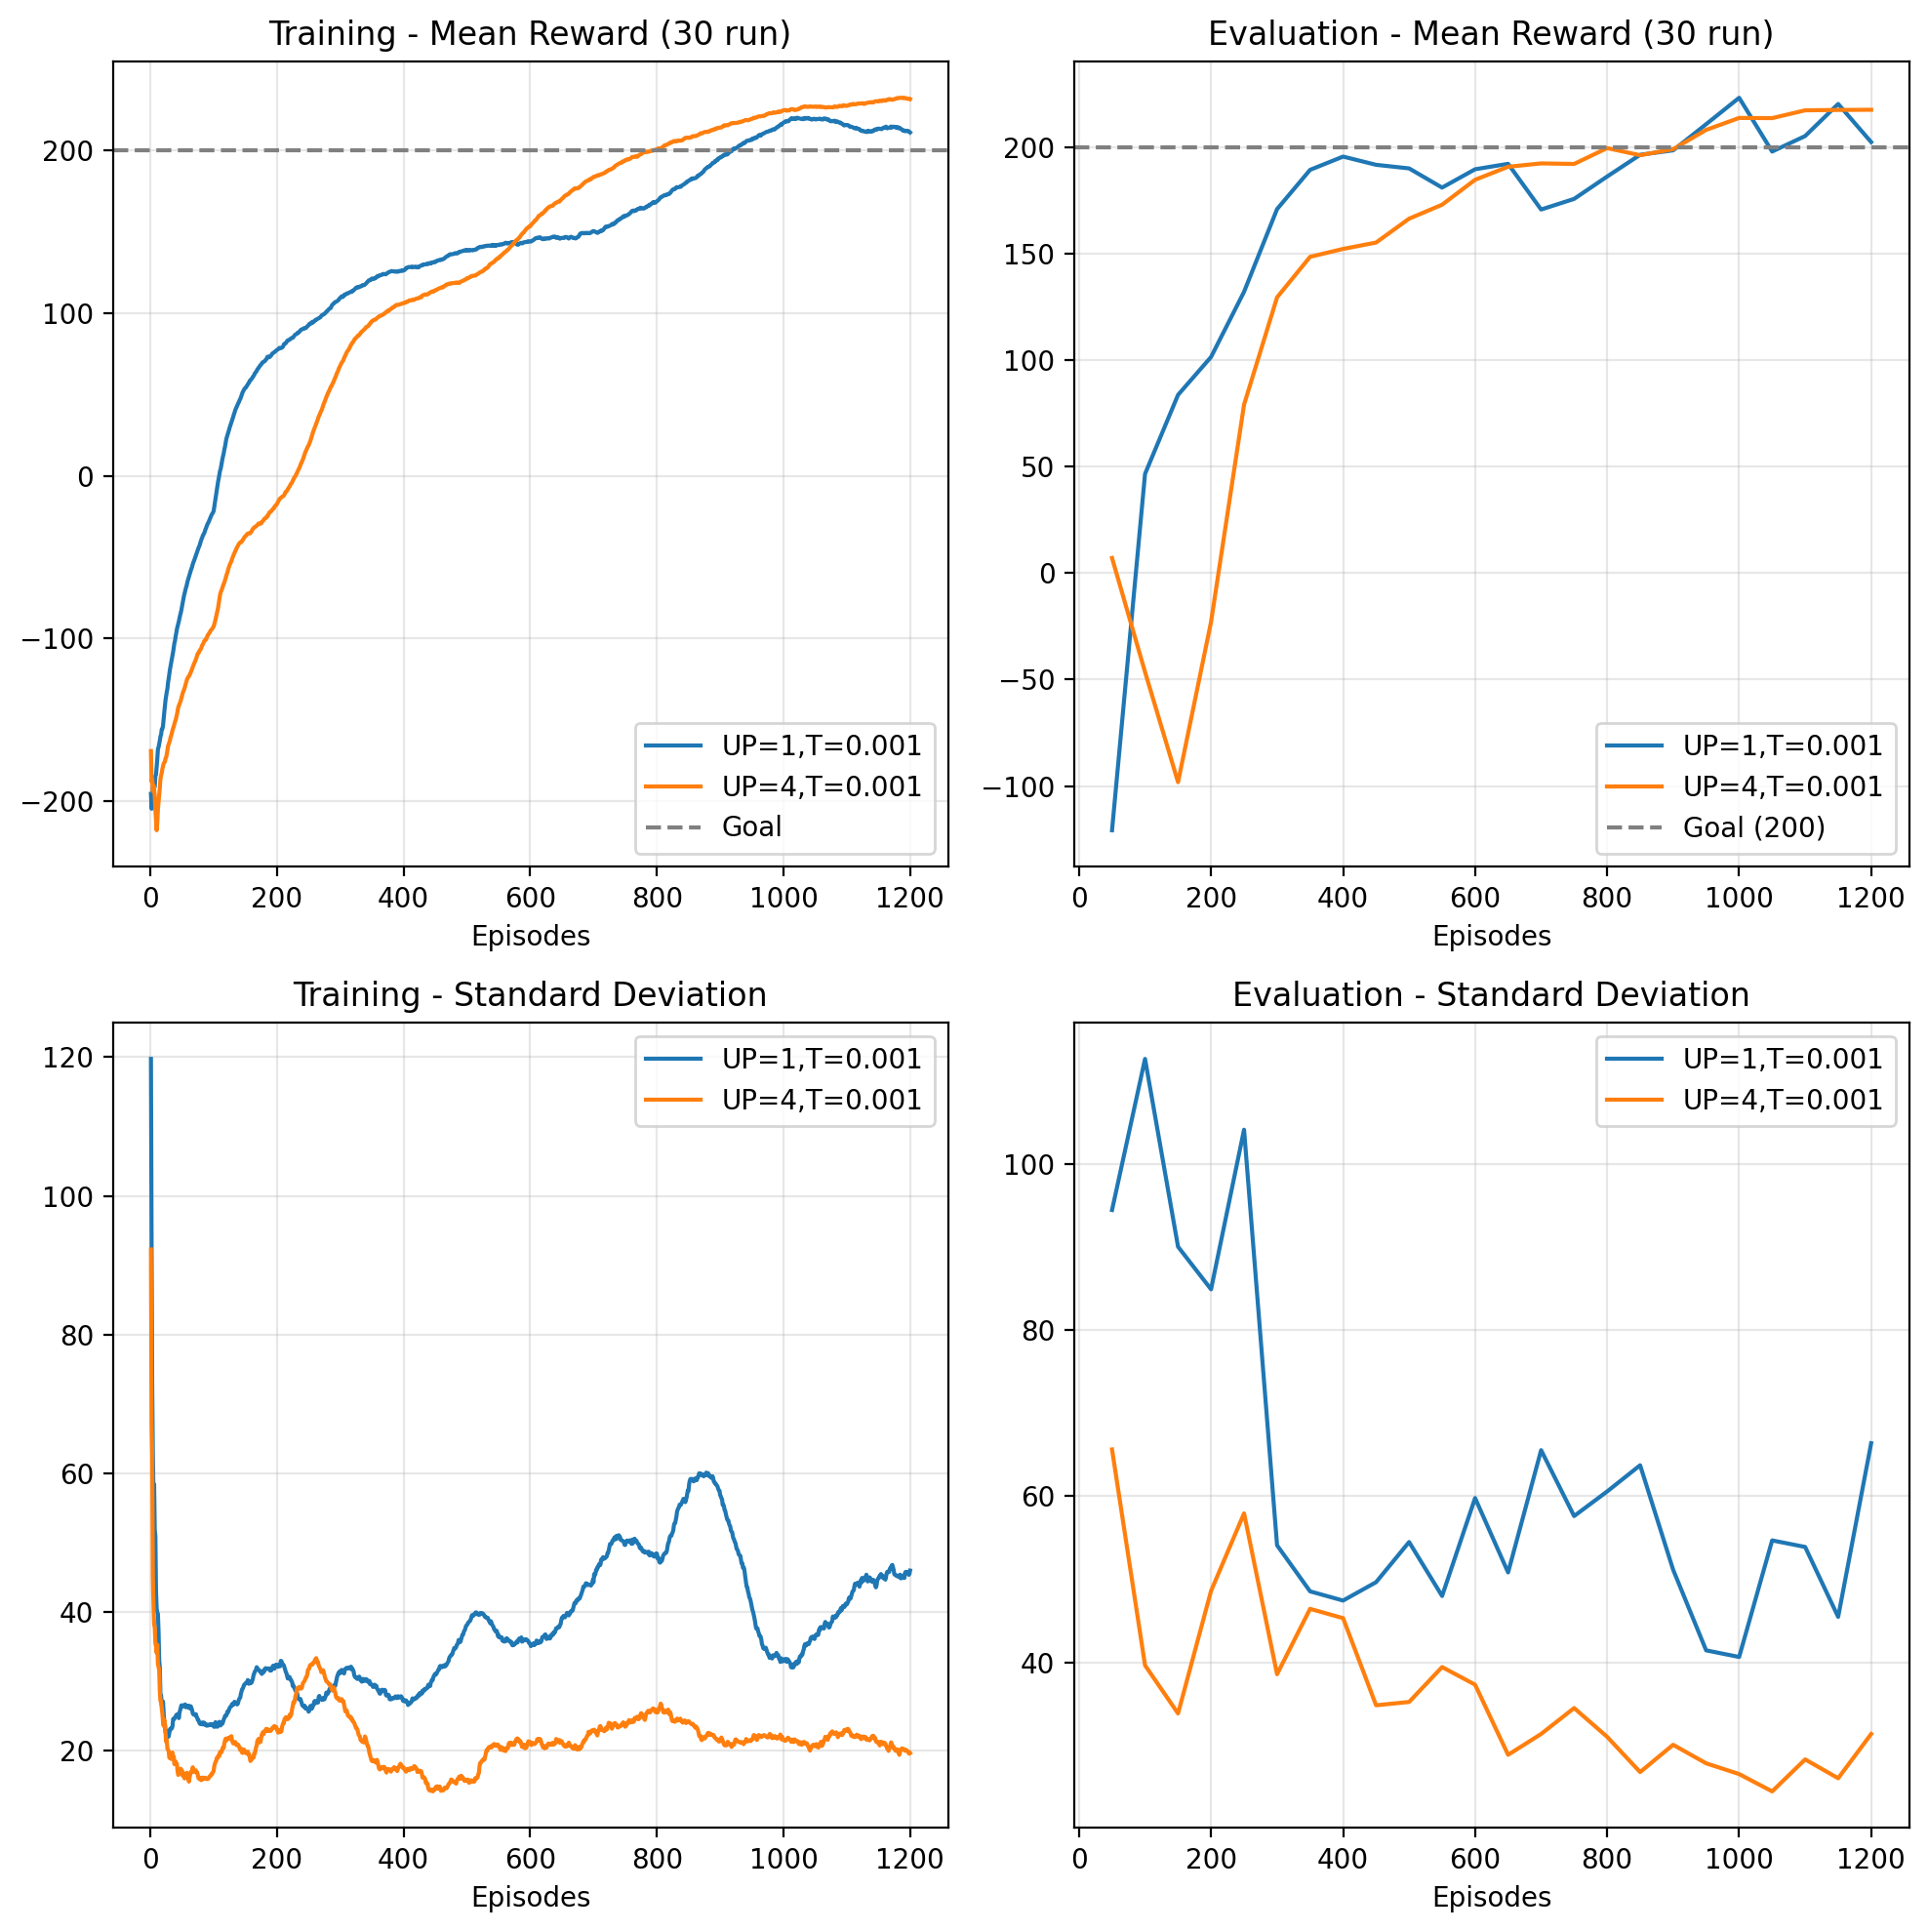

In [188]:
indexes = [2, 3]
es_bs_256_ids = [all_ids[i] for i in indexes]
es_bs_256_techniques = [all_techniques[i] for i in indexes]
es_bs_256_var_attributes = var_attributes[2:]
plot_rewards_vs_episodes(es_bs_256_techniques, es_bs_256_ids, es_bs_256_var_attributes)

### Plot algorithm = Q-learning and batch size = 128
Compare:
- update period: {1, 4}

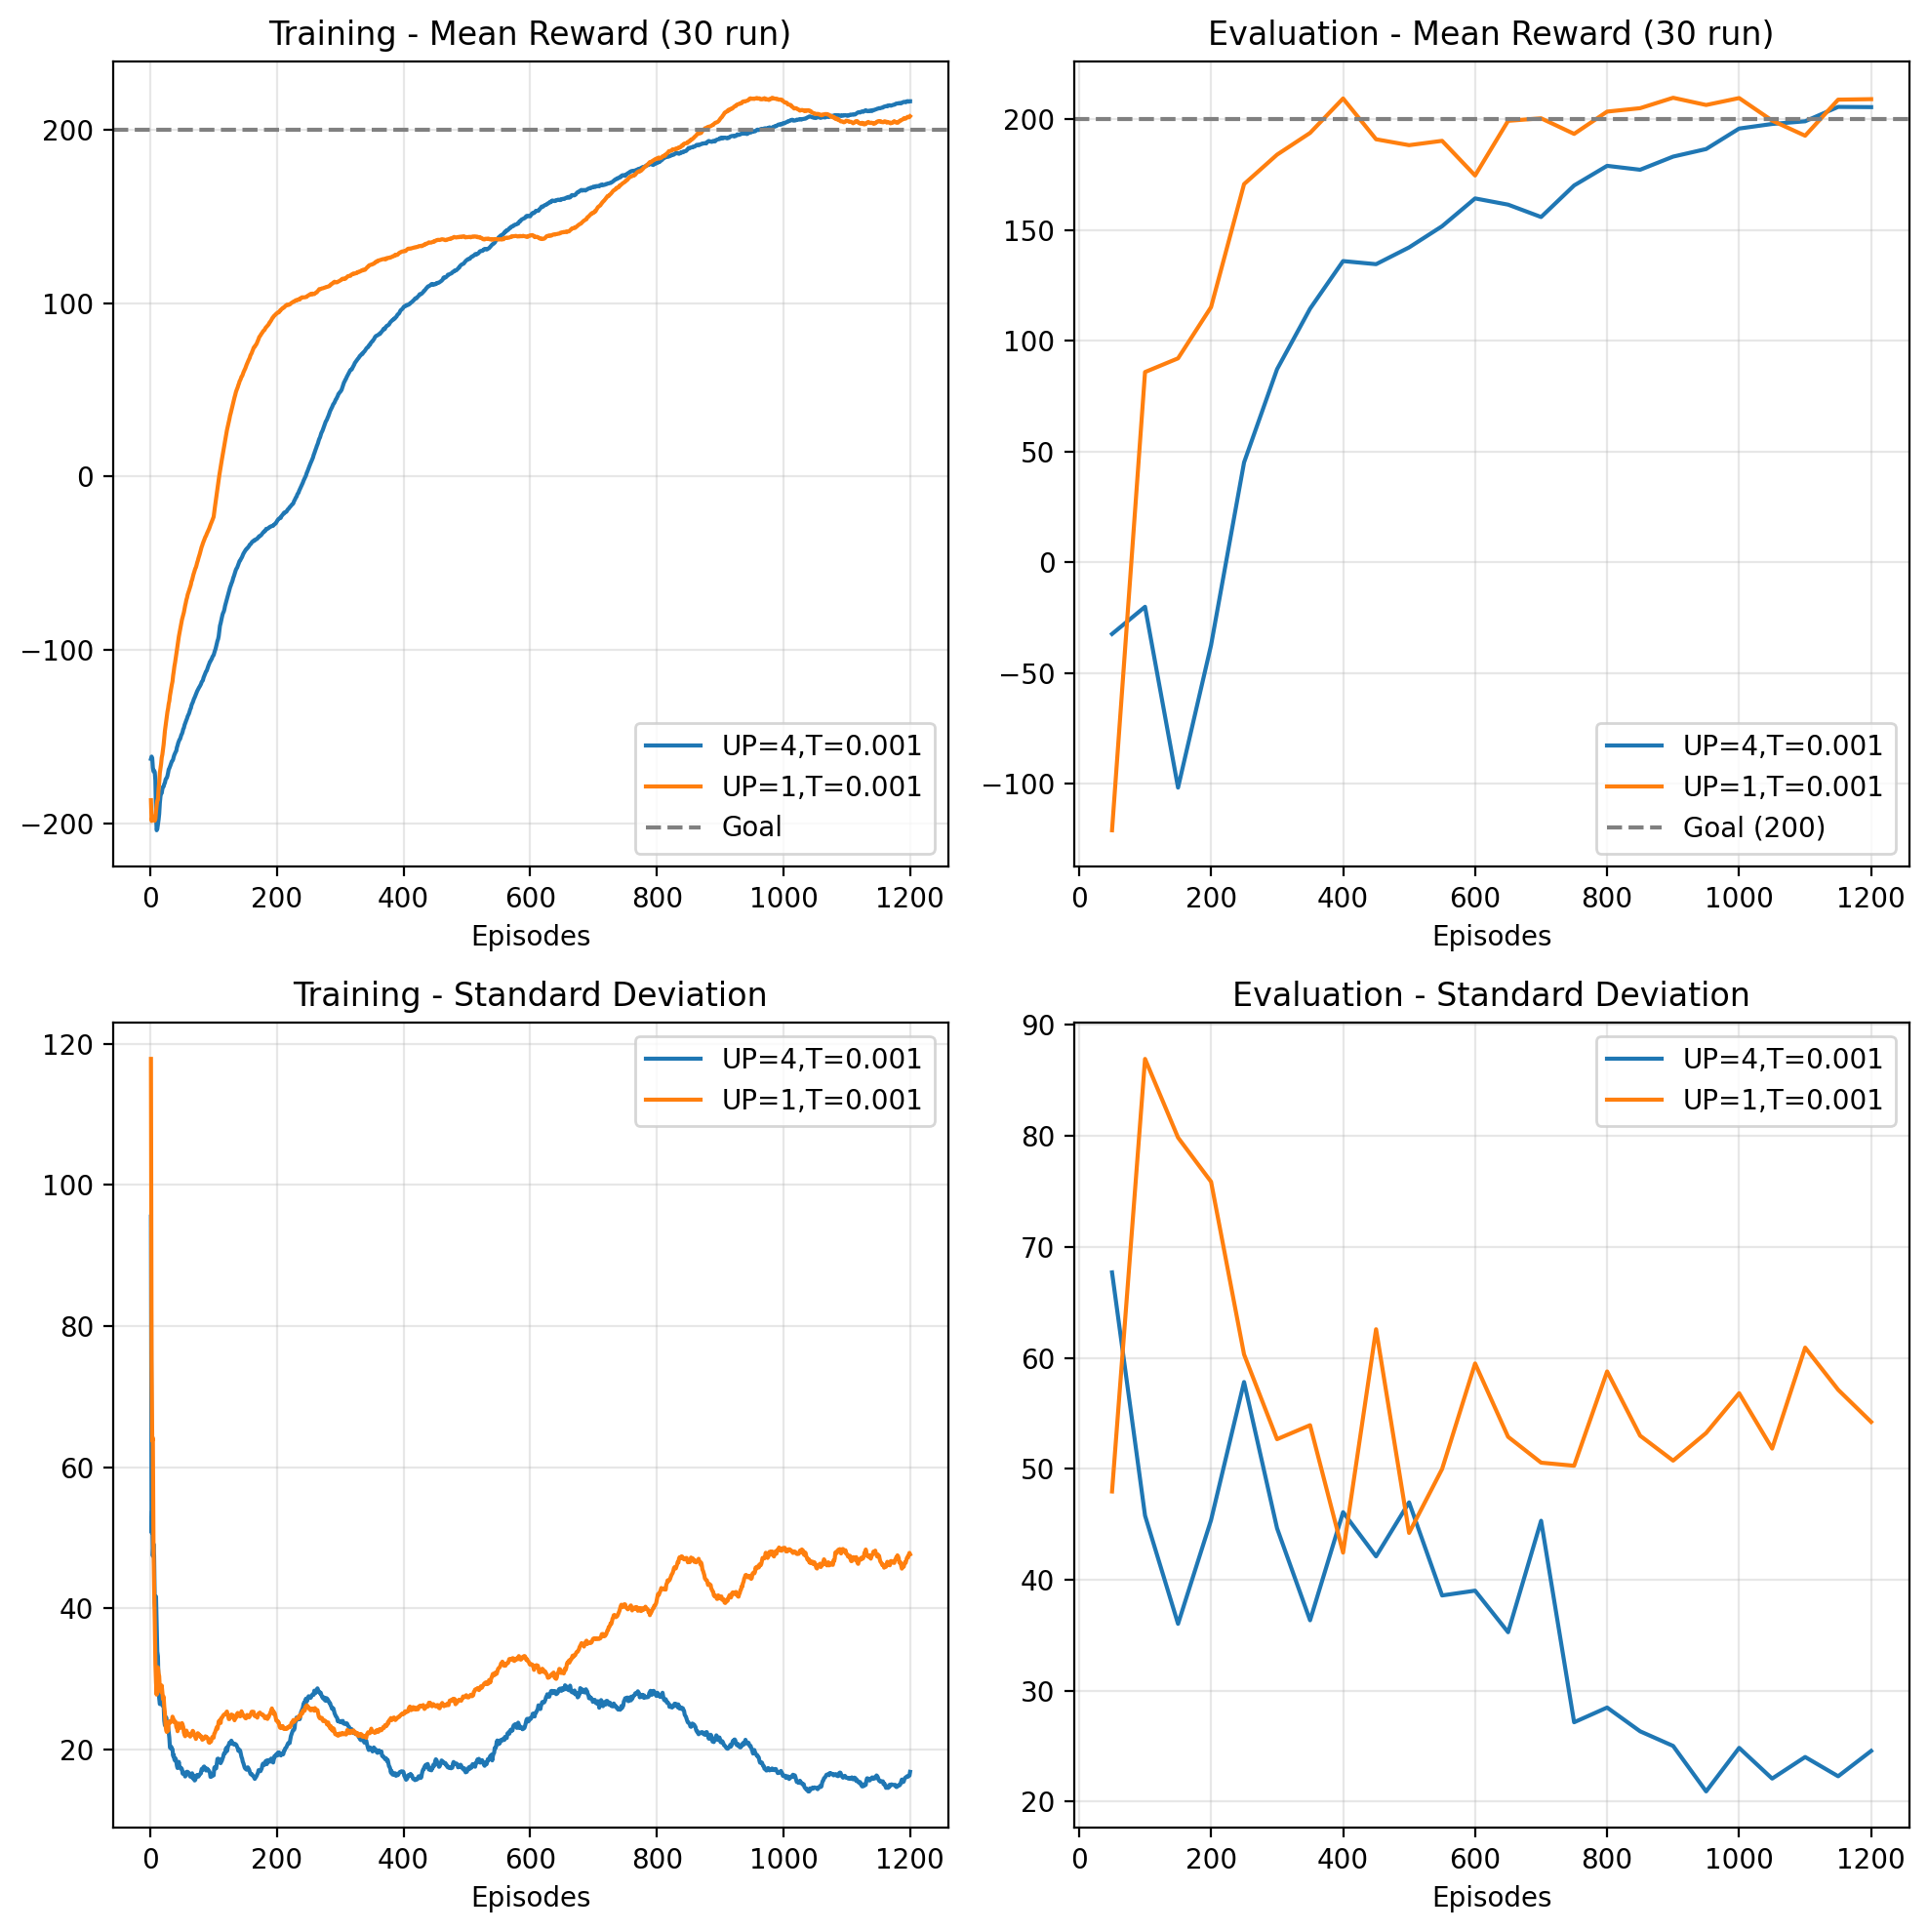

In [189]:
indexes = [8, 9]
ql_bs_128_ids = [all_ids[i] for i in indexes]
ql_bs_128_techniques = [all_techniques[i] for i in indexes]
ql_bs_128_var_attributes = var_attributes[2:]
plot_rewards_vs_episodes(ql_bs_128_techniques, ql_bs_128_ids, ql_bs_128_var_attributes)

### Plot algorithm = q-learning and batch size = 256
Compare:
- update period: {1, 4}

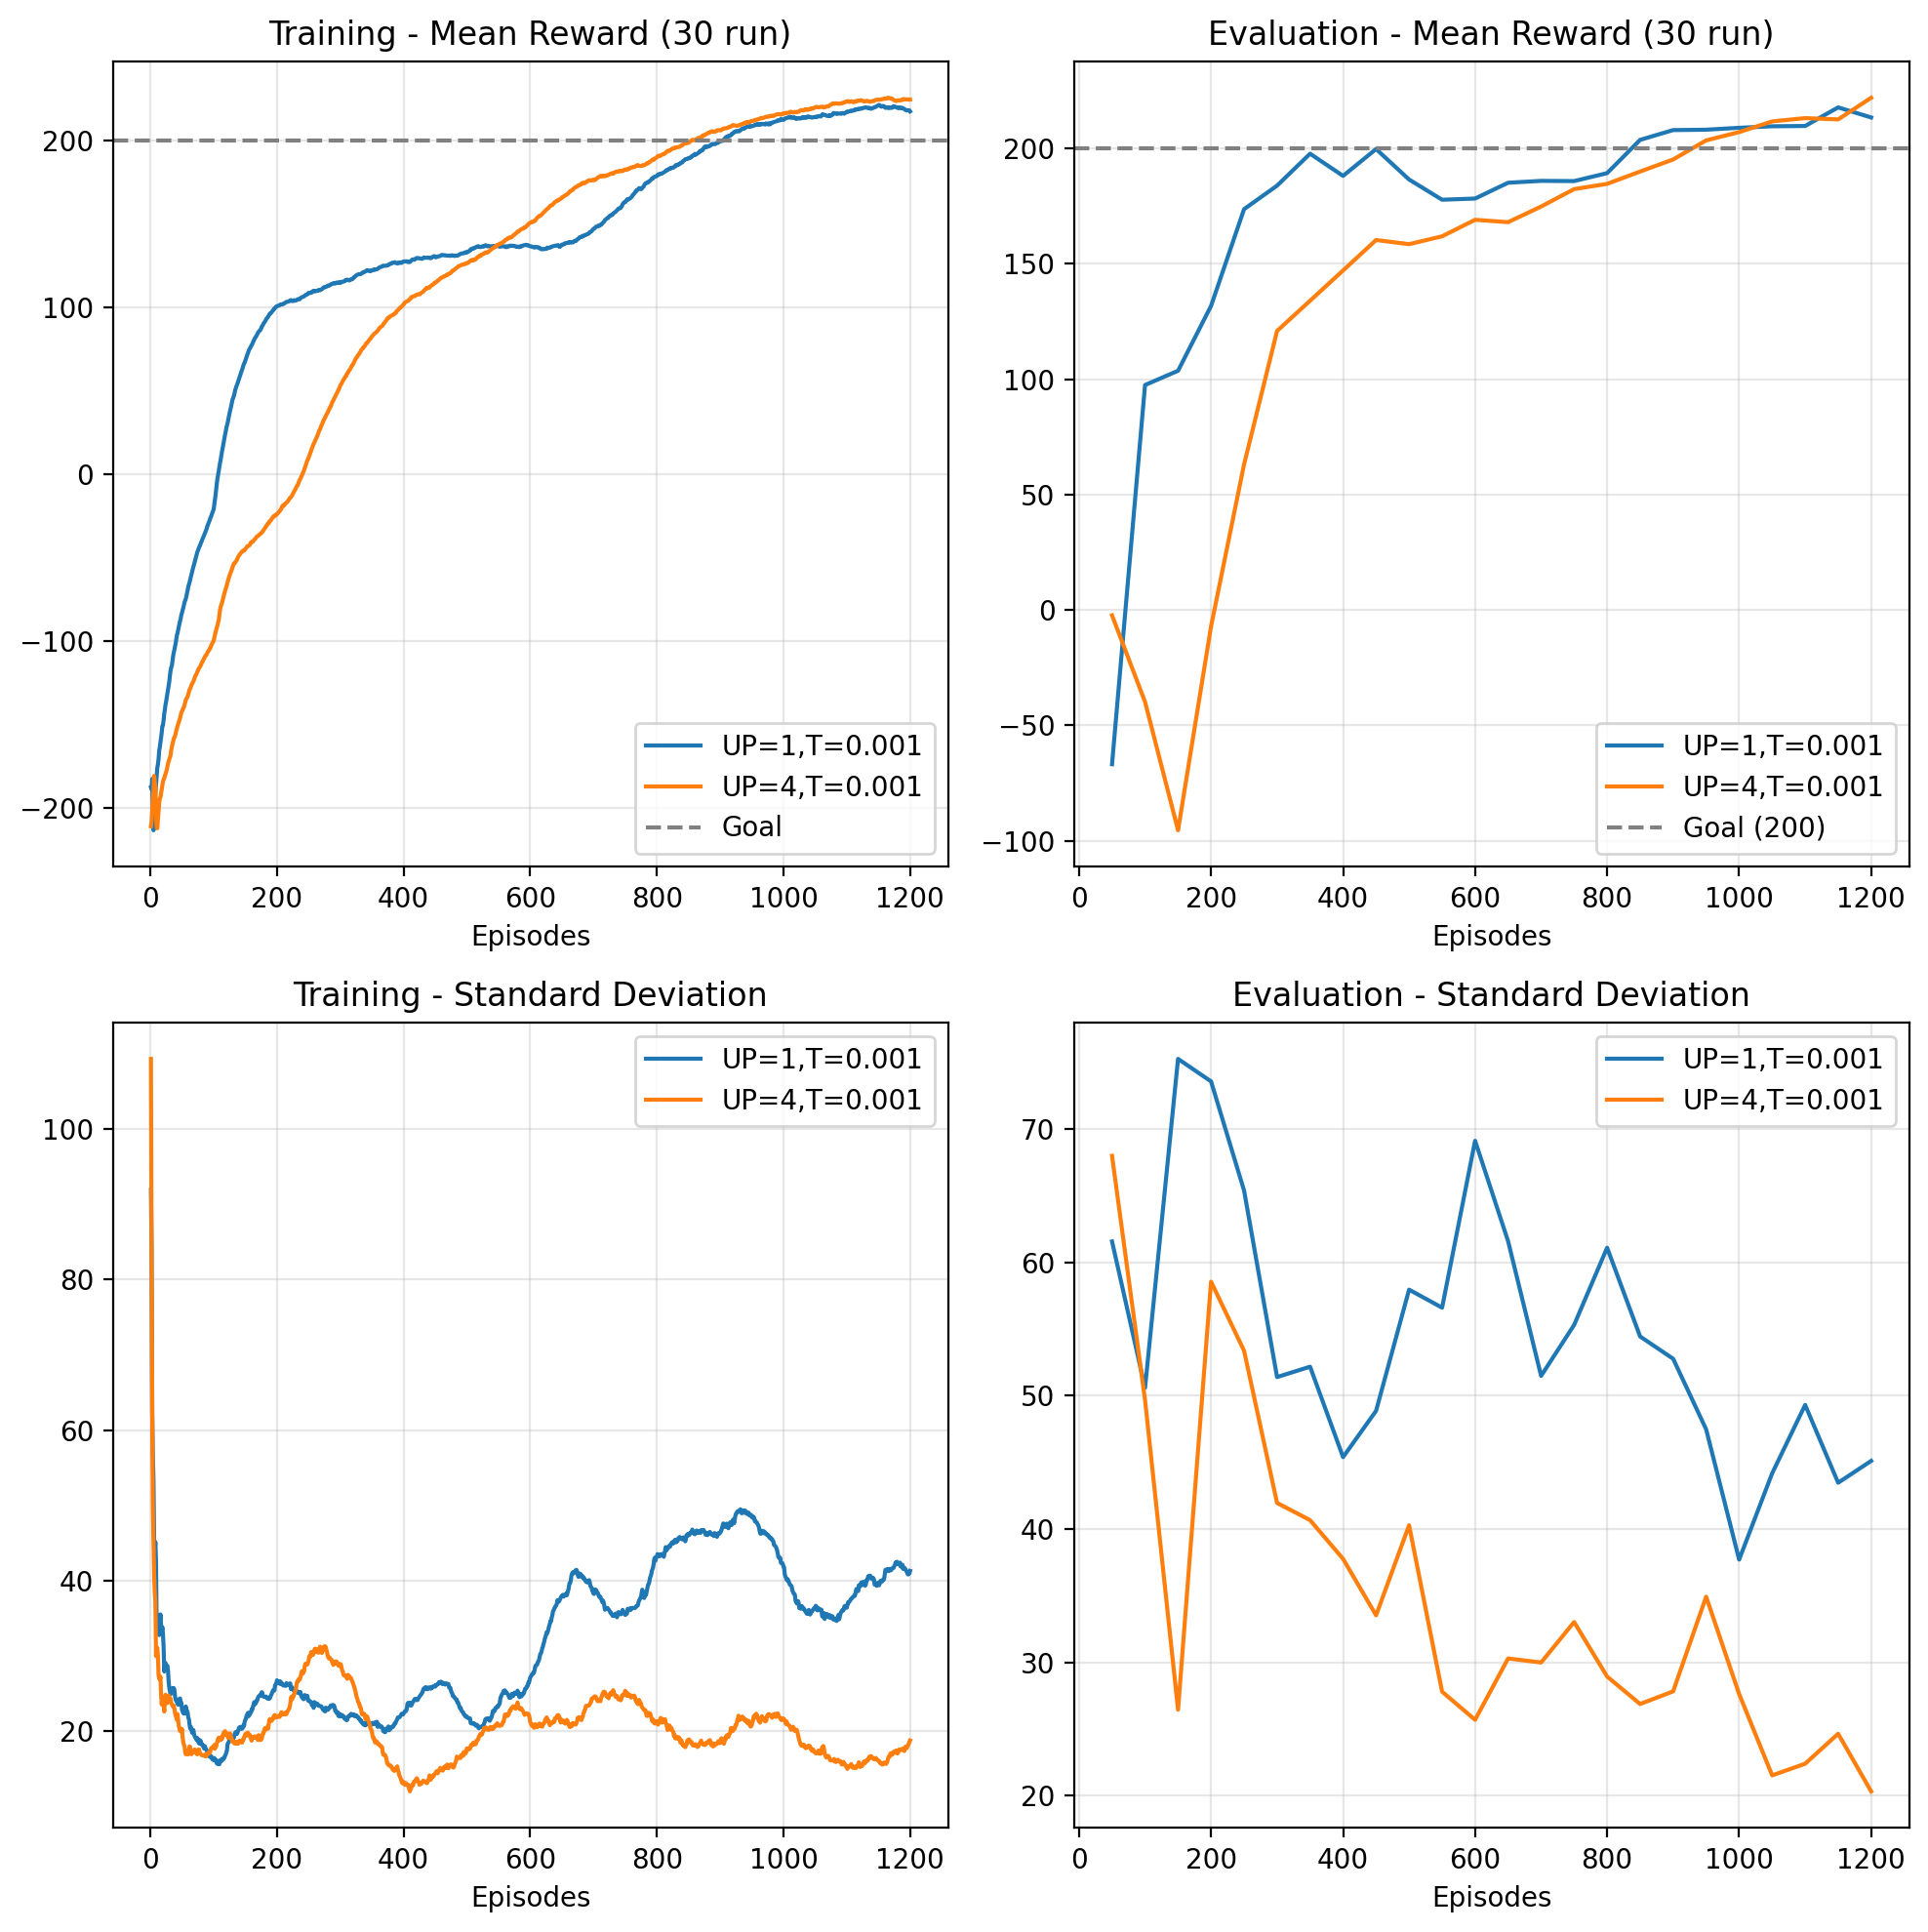

In [190]:
indexes = [6, 7]
ql_bs_256_ids = [all_ids[i] for i in indexes]
ql_bs_256_techniques = [all_techniques[i] for i in indexes]
ql_bs_256_var_attributes = var_attributes[2:]
plot_rewards_vs_episodes(ql_bs_256_techniques, ql_bs_256_ids, ql_bs_256_var_attributes)

### Plot algorithm = expected sarsa and update period = 1
Compare:
- batch size: {128, 256}

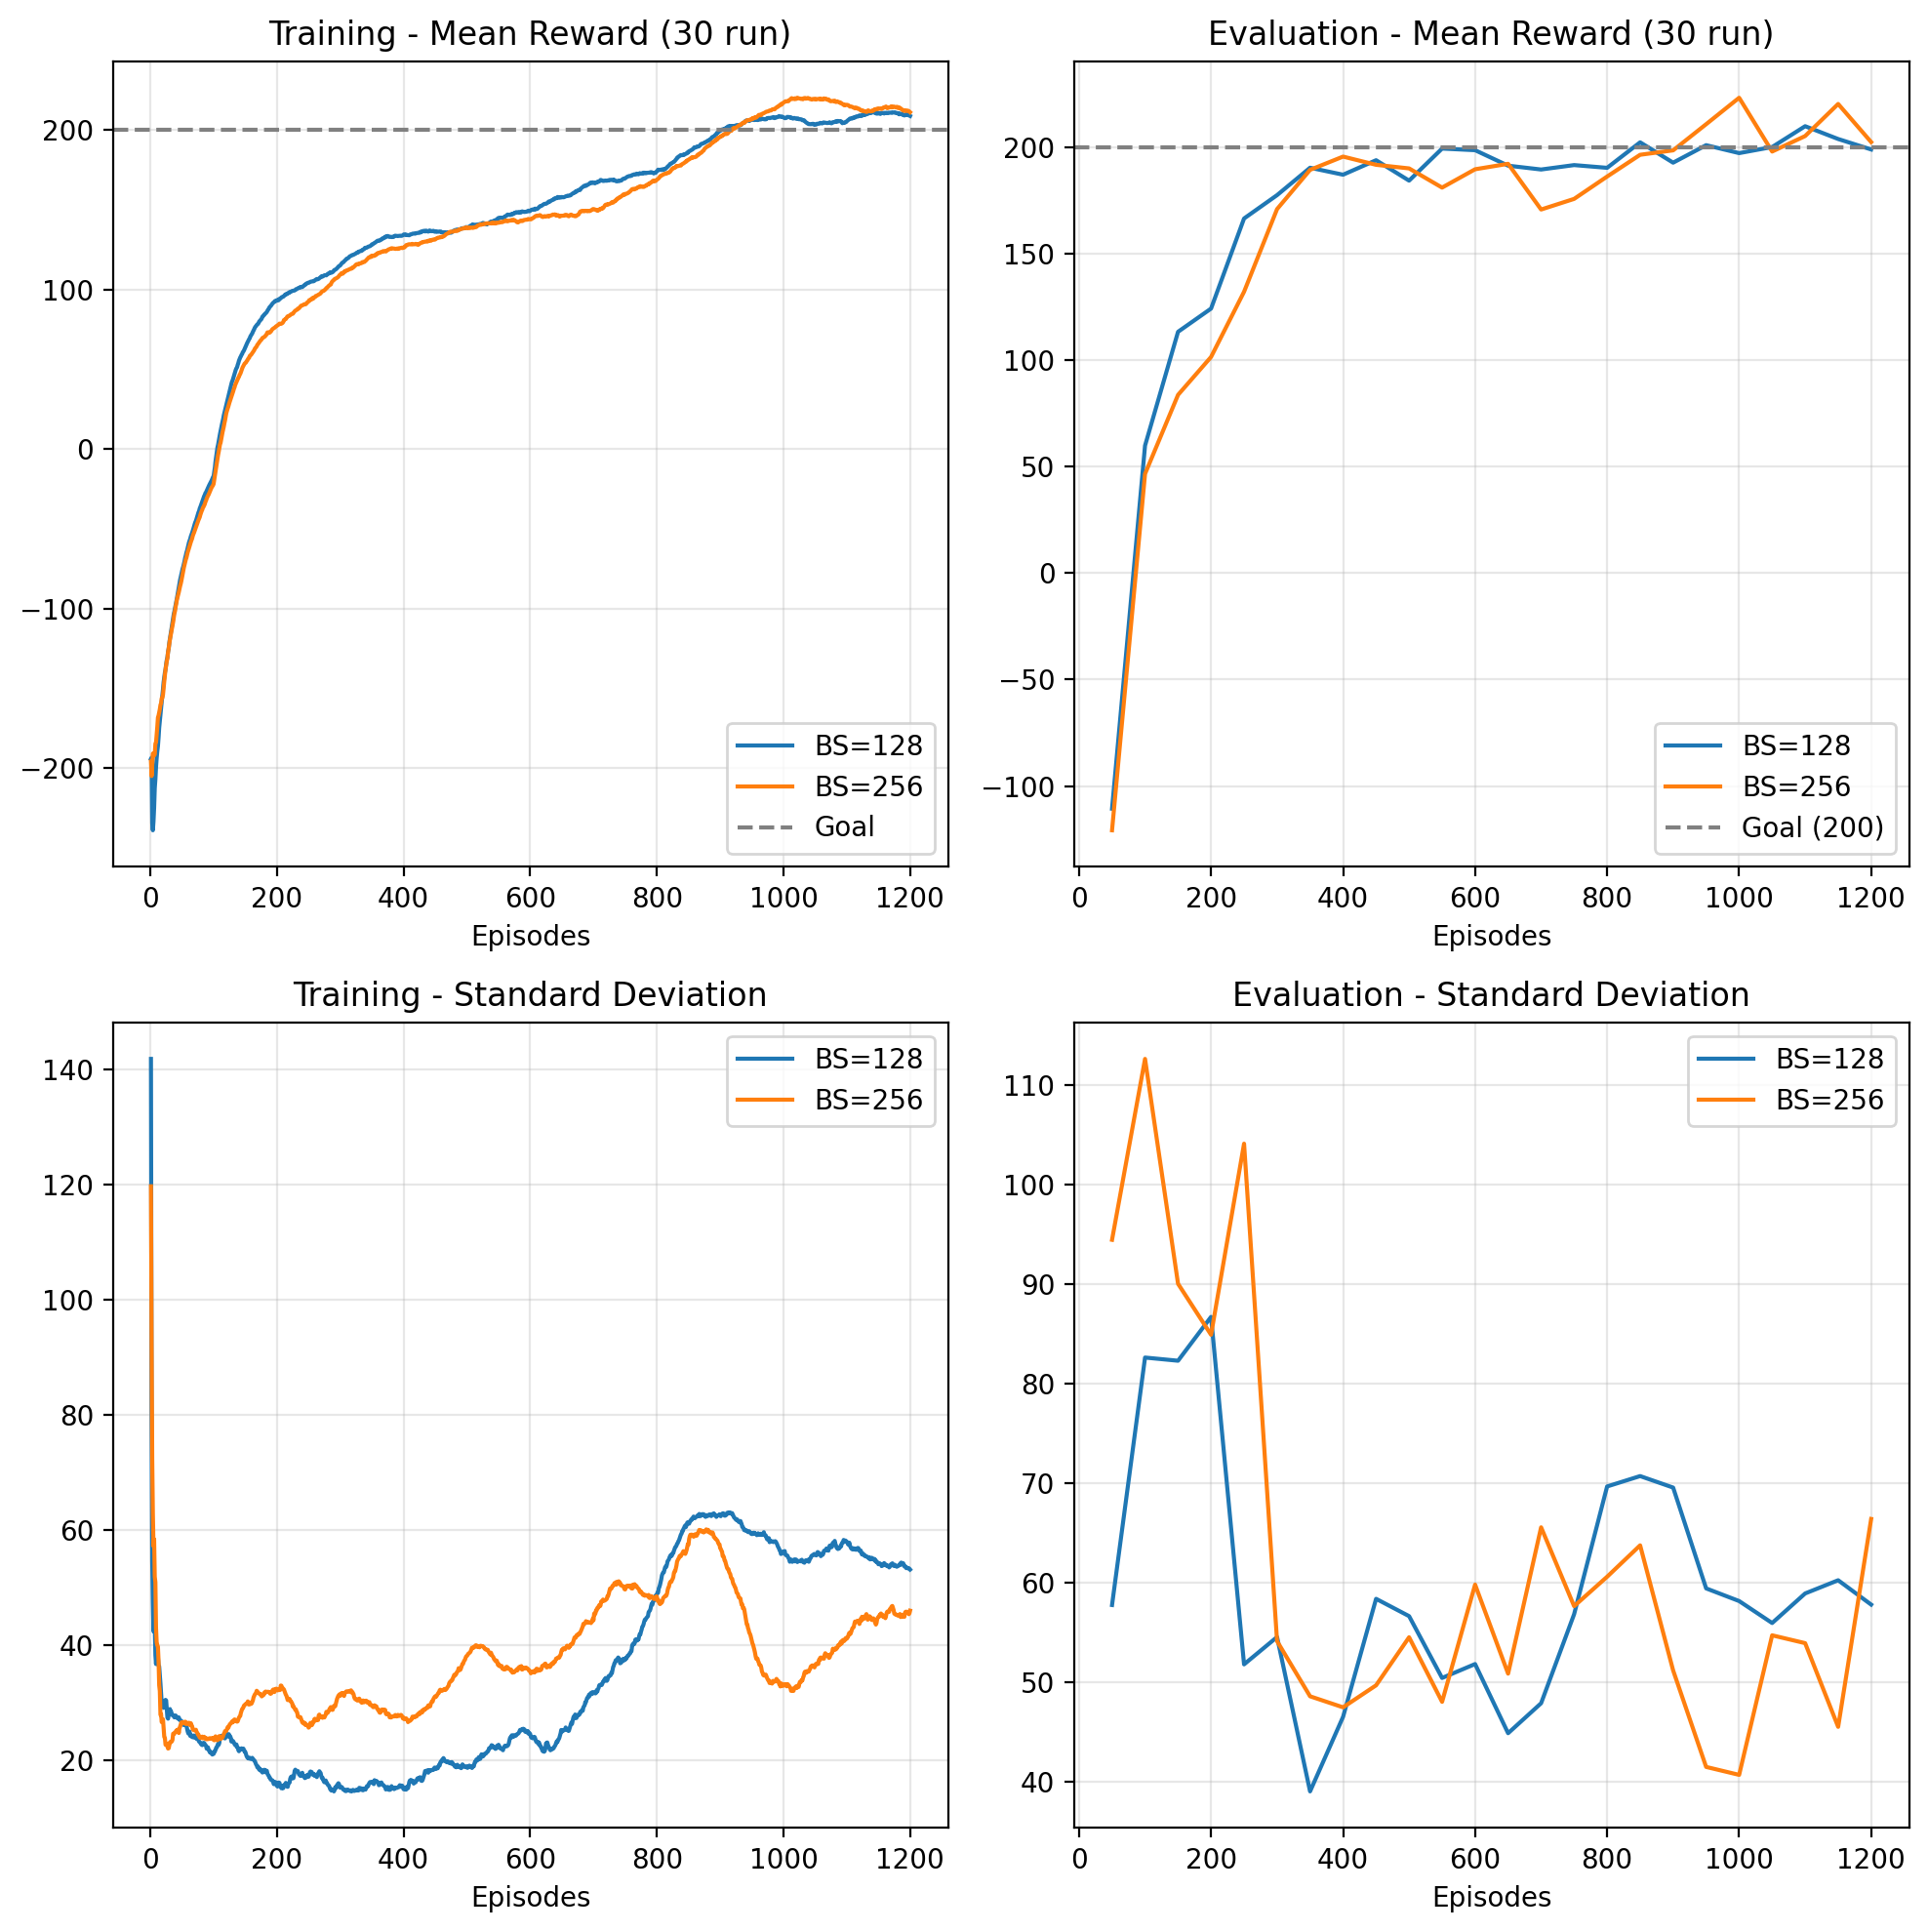

In [191]:
indexes = [0, 2]
es_up_1_ids = [all_ids[i] for i in indexes]
es_up_1_techniques = [all_techniques[i] for i in indexes]
es_up_1_var_attributes = var_attributes[1:2]
plot_rewards_vs_episodes(es_up_1_techniques, es_up_1_ids, es_up_1_var_attributes)

### Plot algorithm = expected sarsa and update period = 4
Compare:
- batch size: {128, 256}

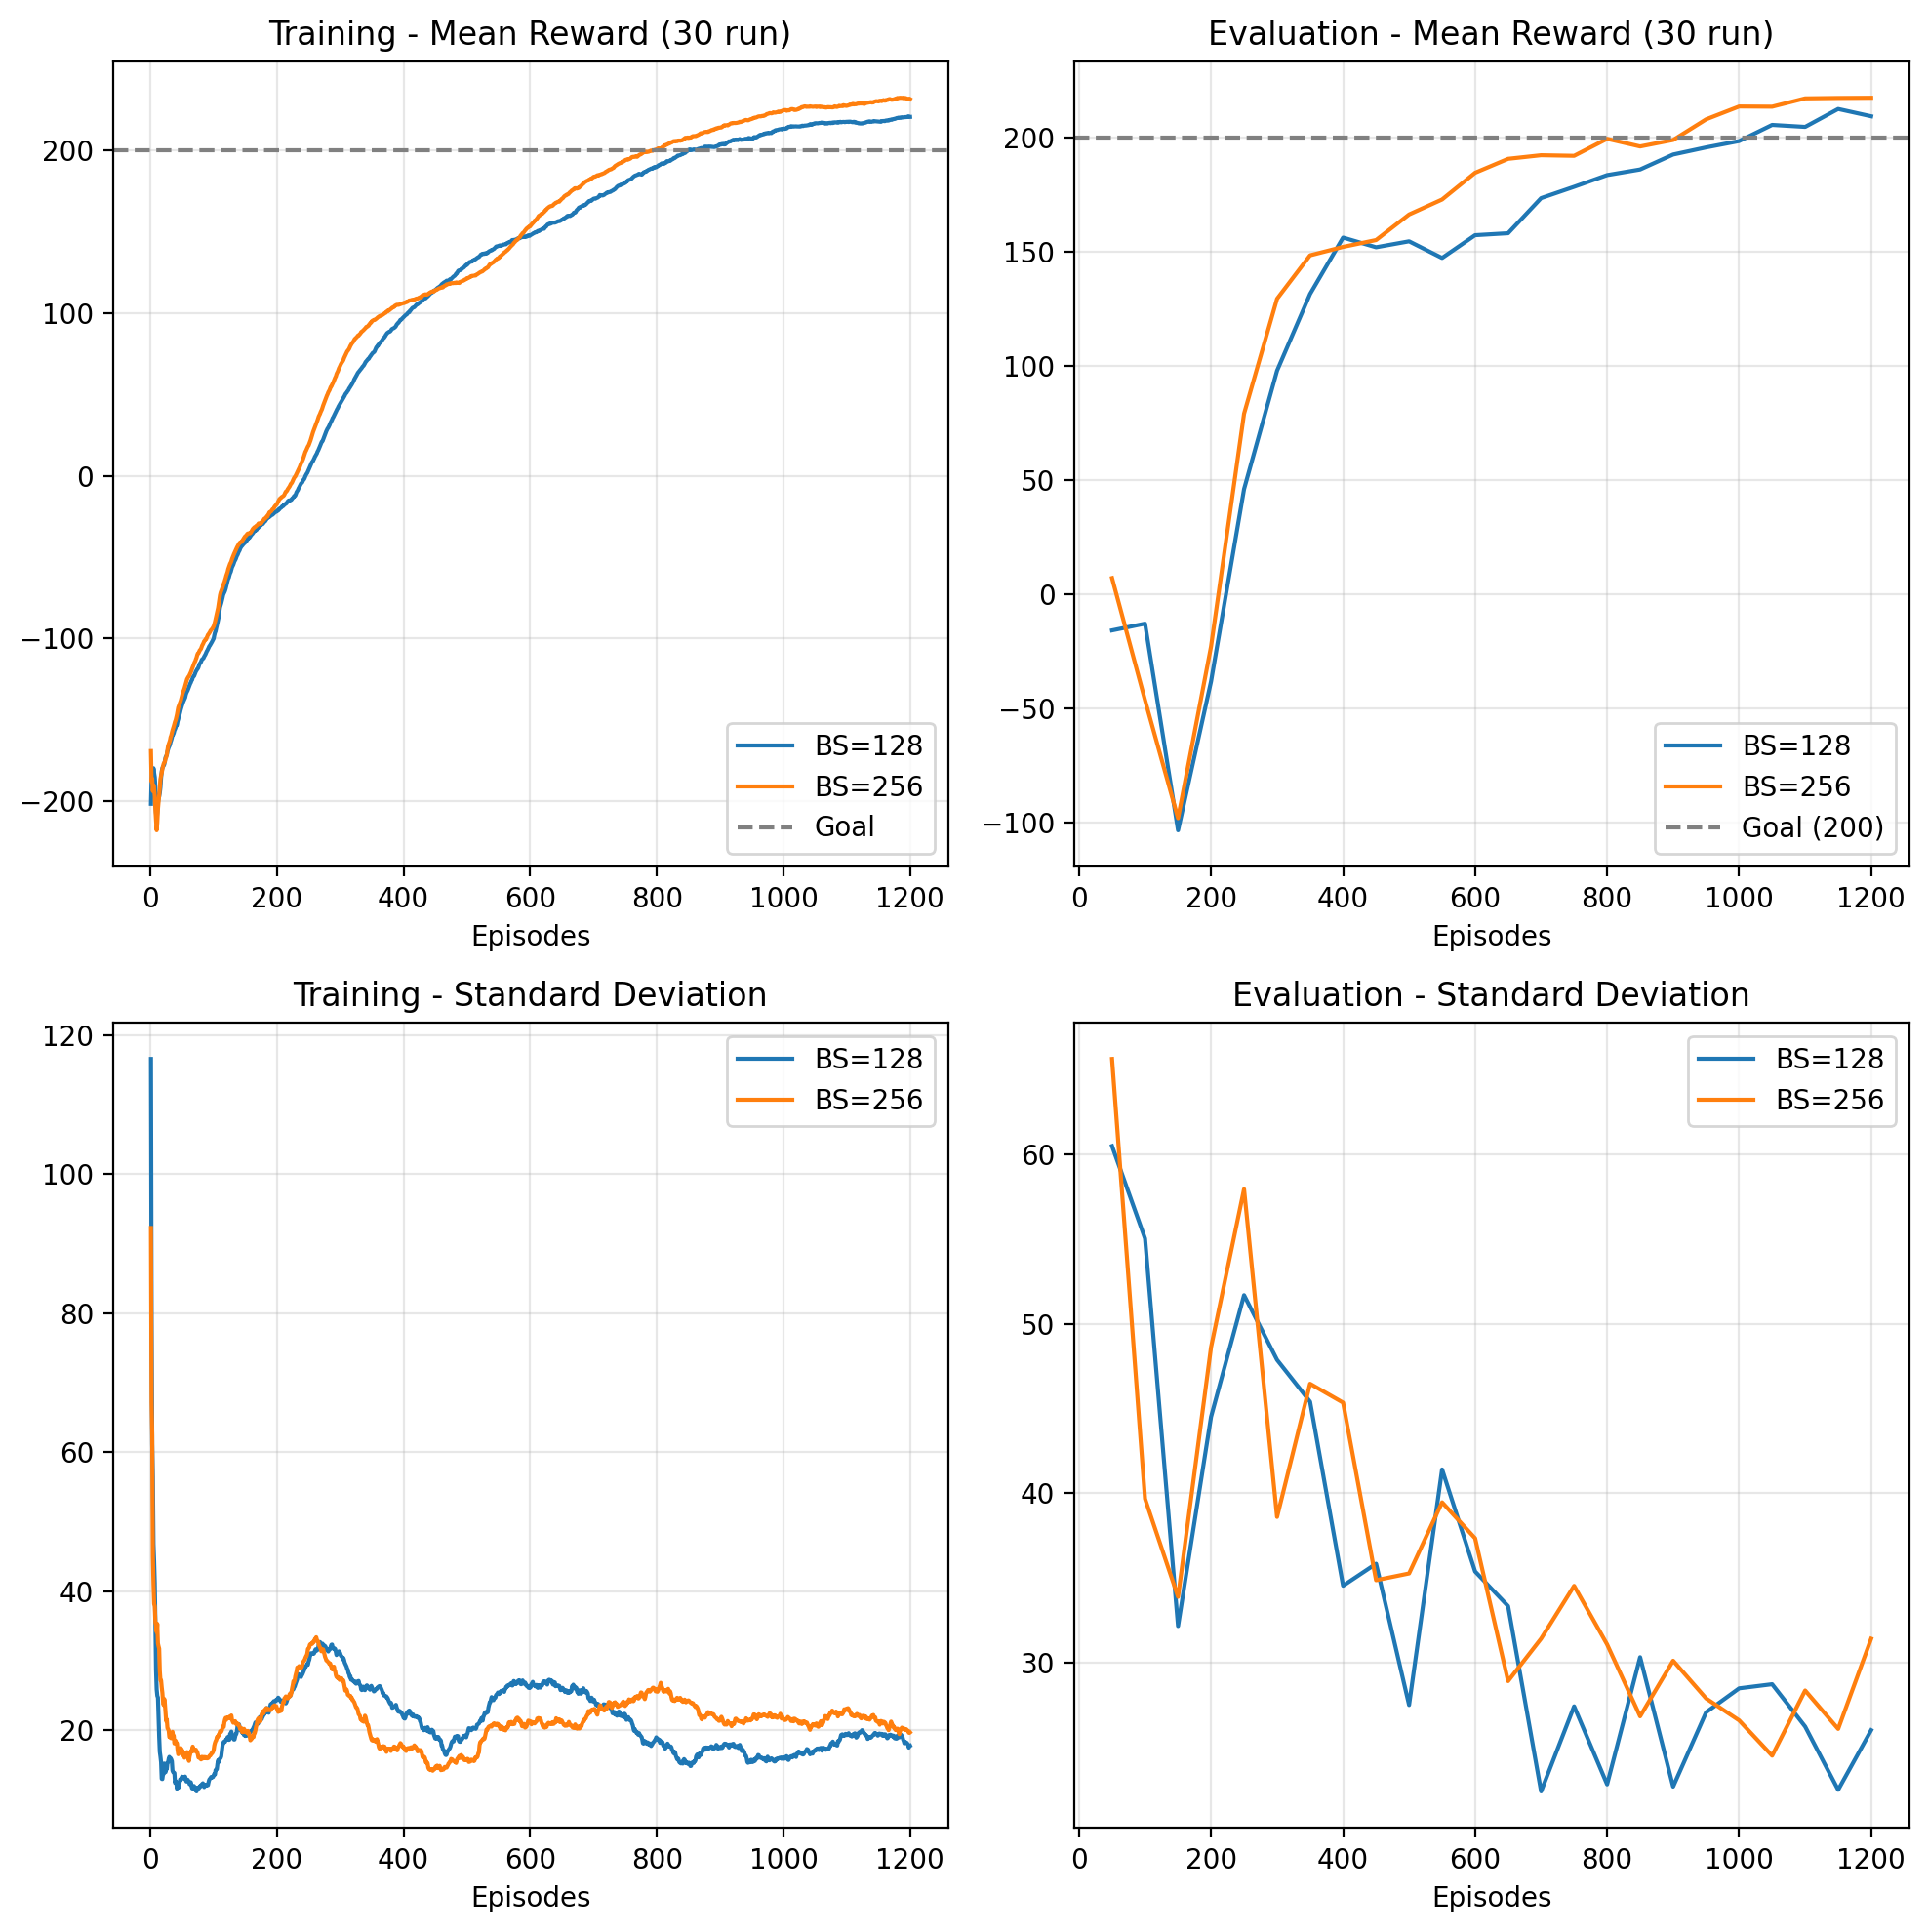

In [192]:
indexes = [1, 3]
es_up_4_ids = [all_ids[i] for i in indexes]
es_up_4_techniques = [all_techniques[i] for i in indexes]
es_up_4_var_attributes = var_attributes[1:2]
plot_rewards_vs_episodes(es_up_4_techniques, es_up_4_ids, es_up_4_var_attributes)

### Plot algorithm = q-learning and update period = 1
Compare:
- batch size: {128, 256}

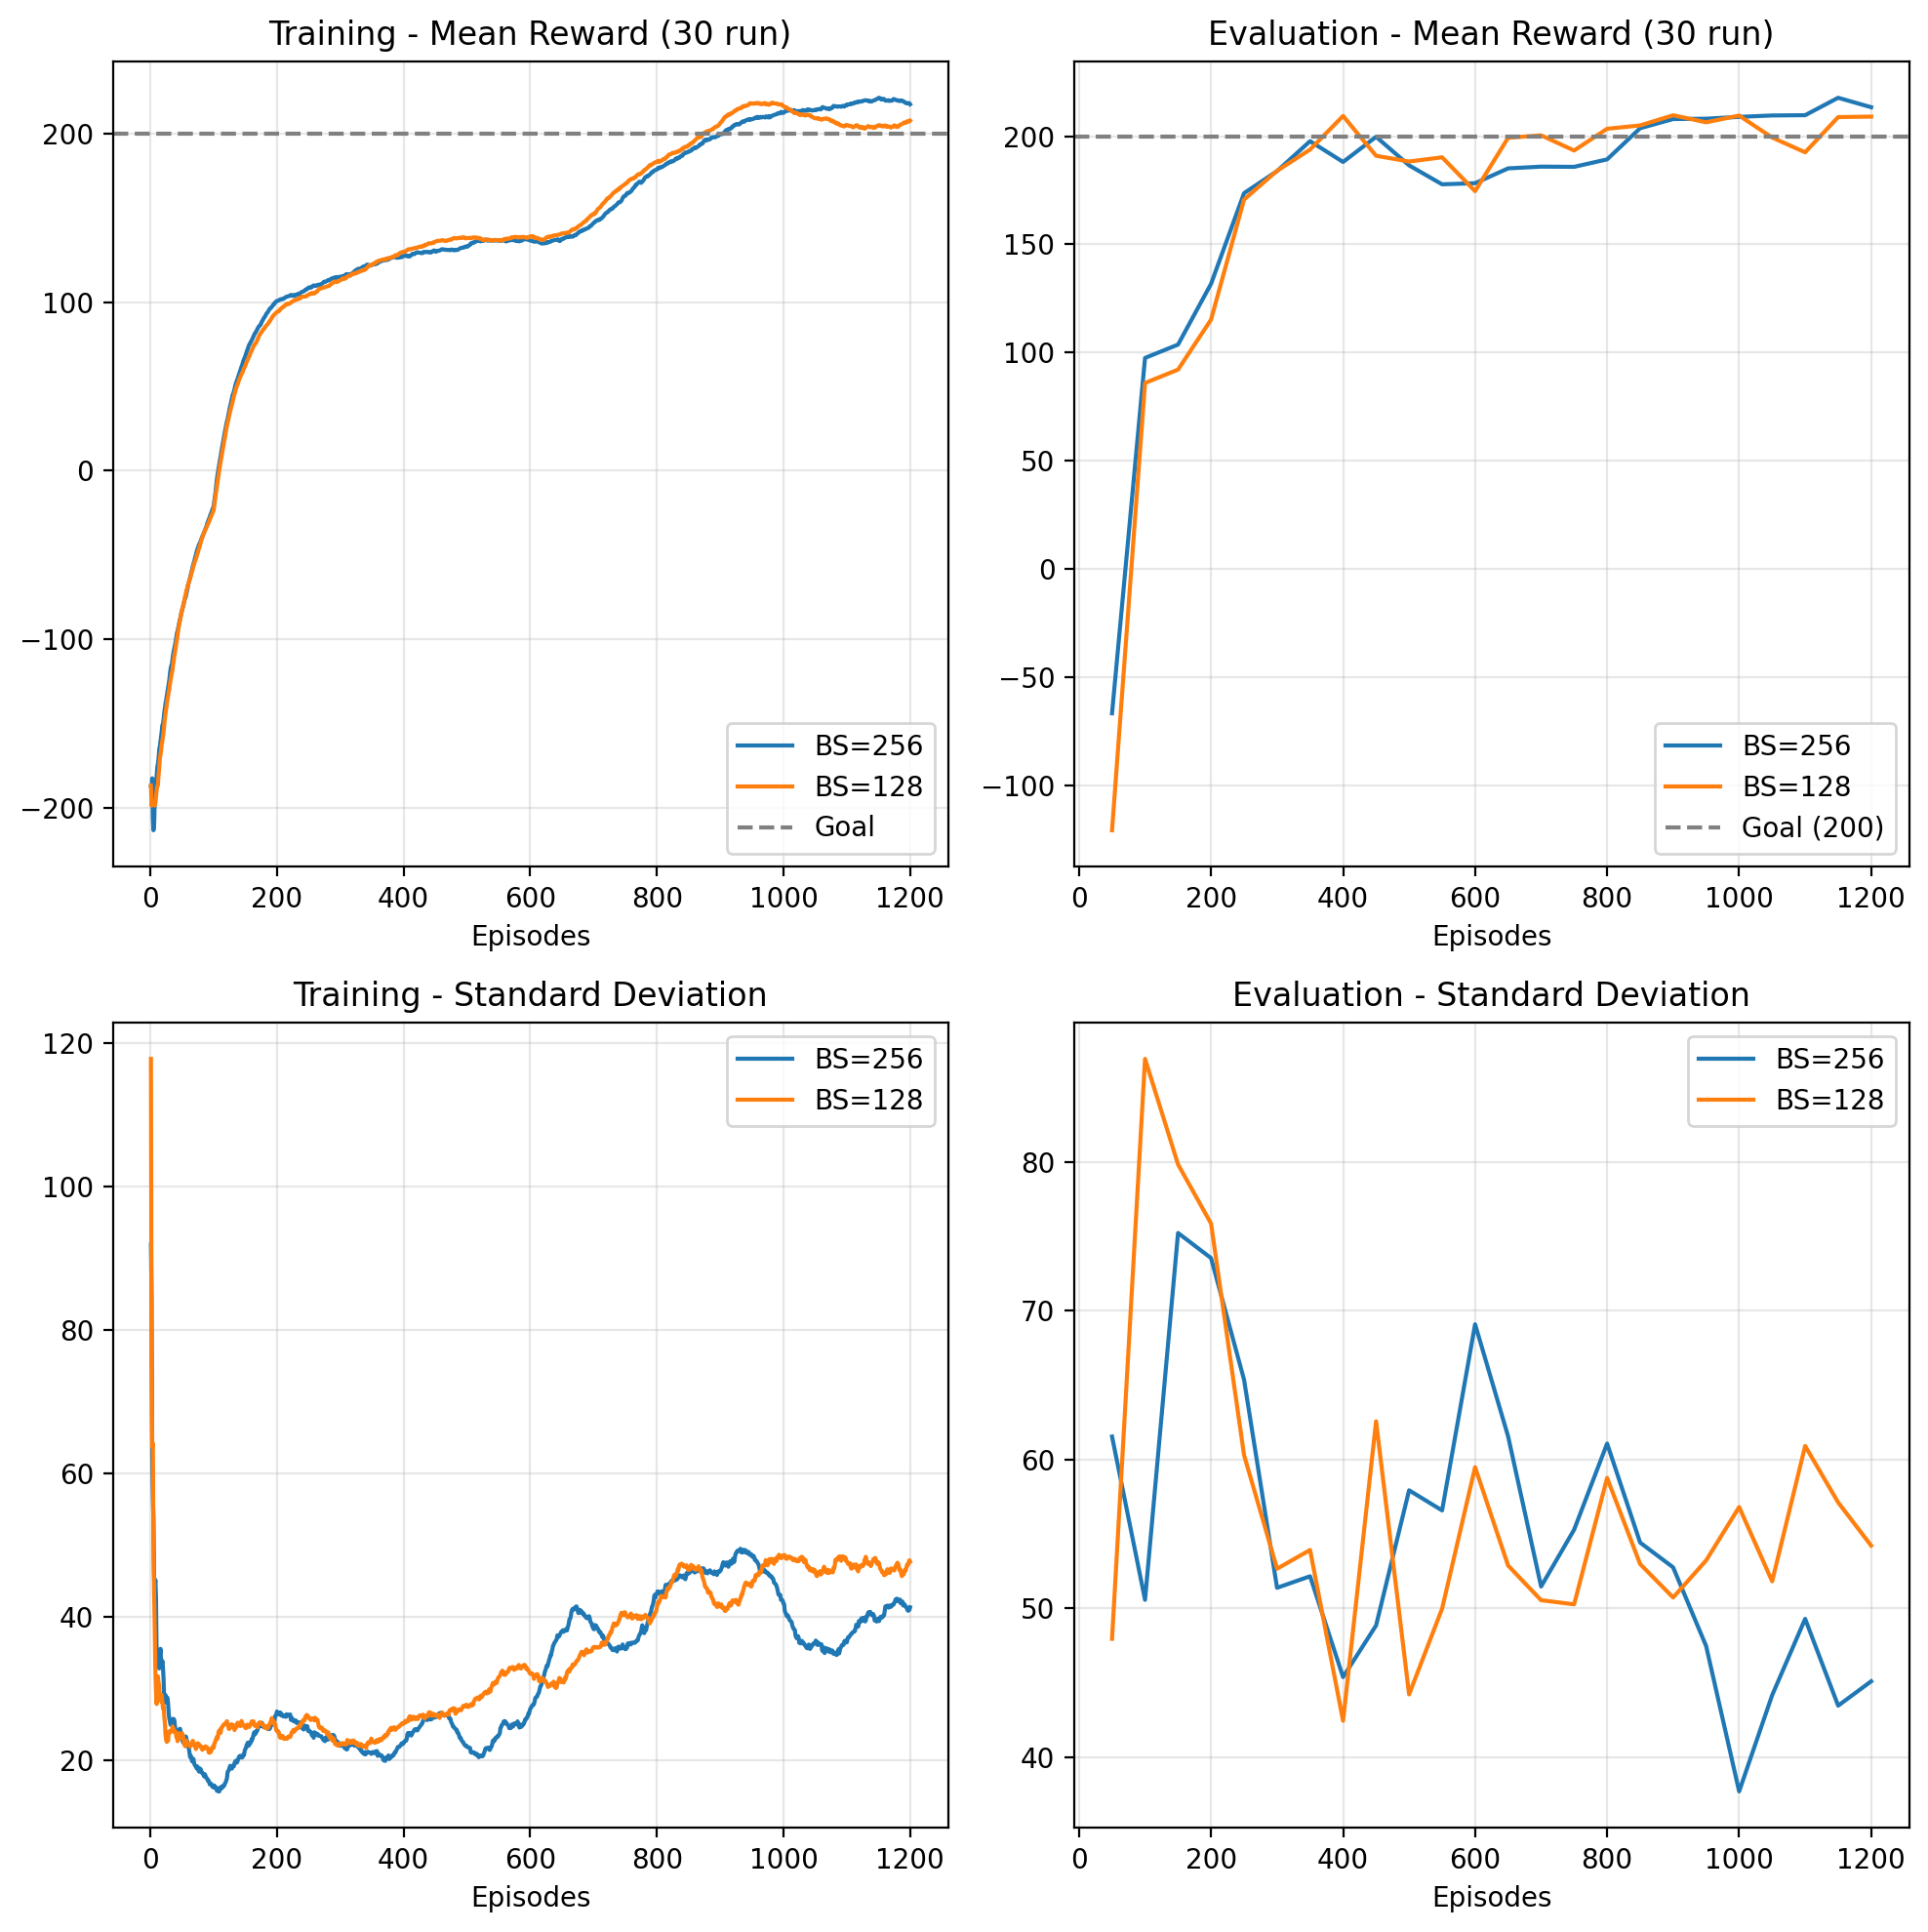

In [193]:
indexes = [6, 9]
ql_up_1_ids = [all_ids[i] for i in indexes]
ql_up_1_techniques = [all_techniques[i] for i in indexes]
ql_up_1_var_attributes = var_attributes[1:2]
plot_rewards_vs_episodes(ql_up_1_techniques, ql_up_1_ids, ql_up_1_var_attributes)

### Plot algorithm = q-learning and update period = 4
Compare:
- batch size: {128, 256}

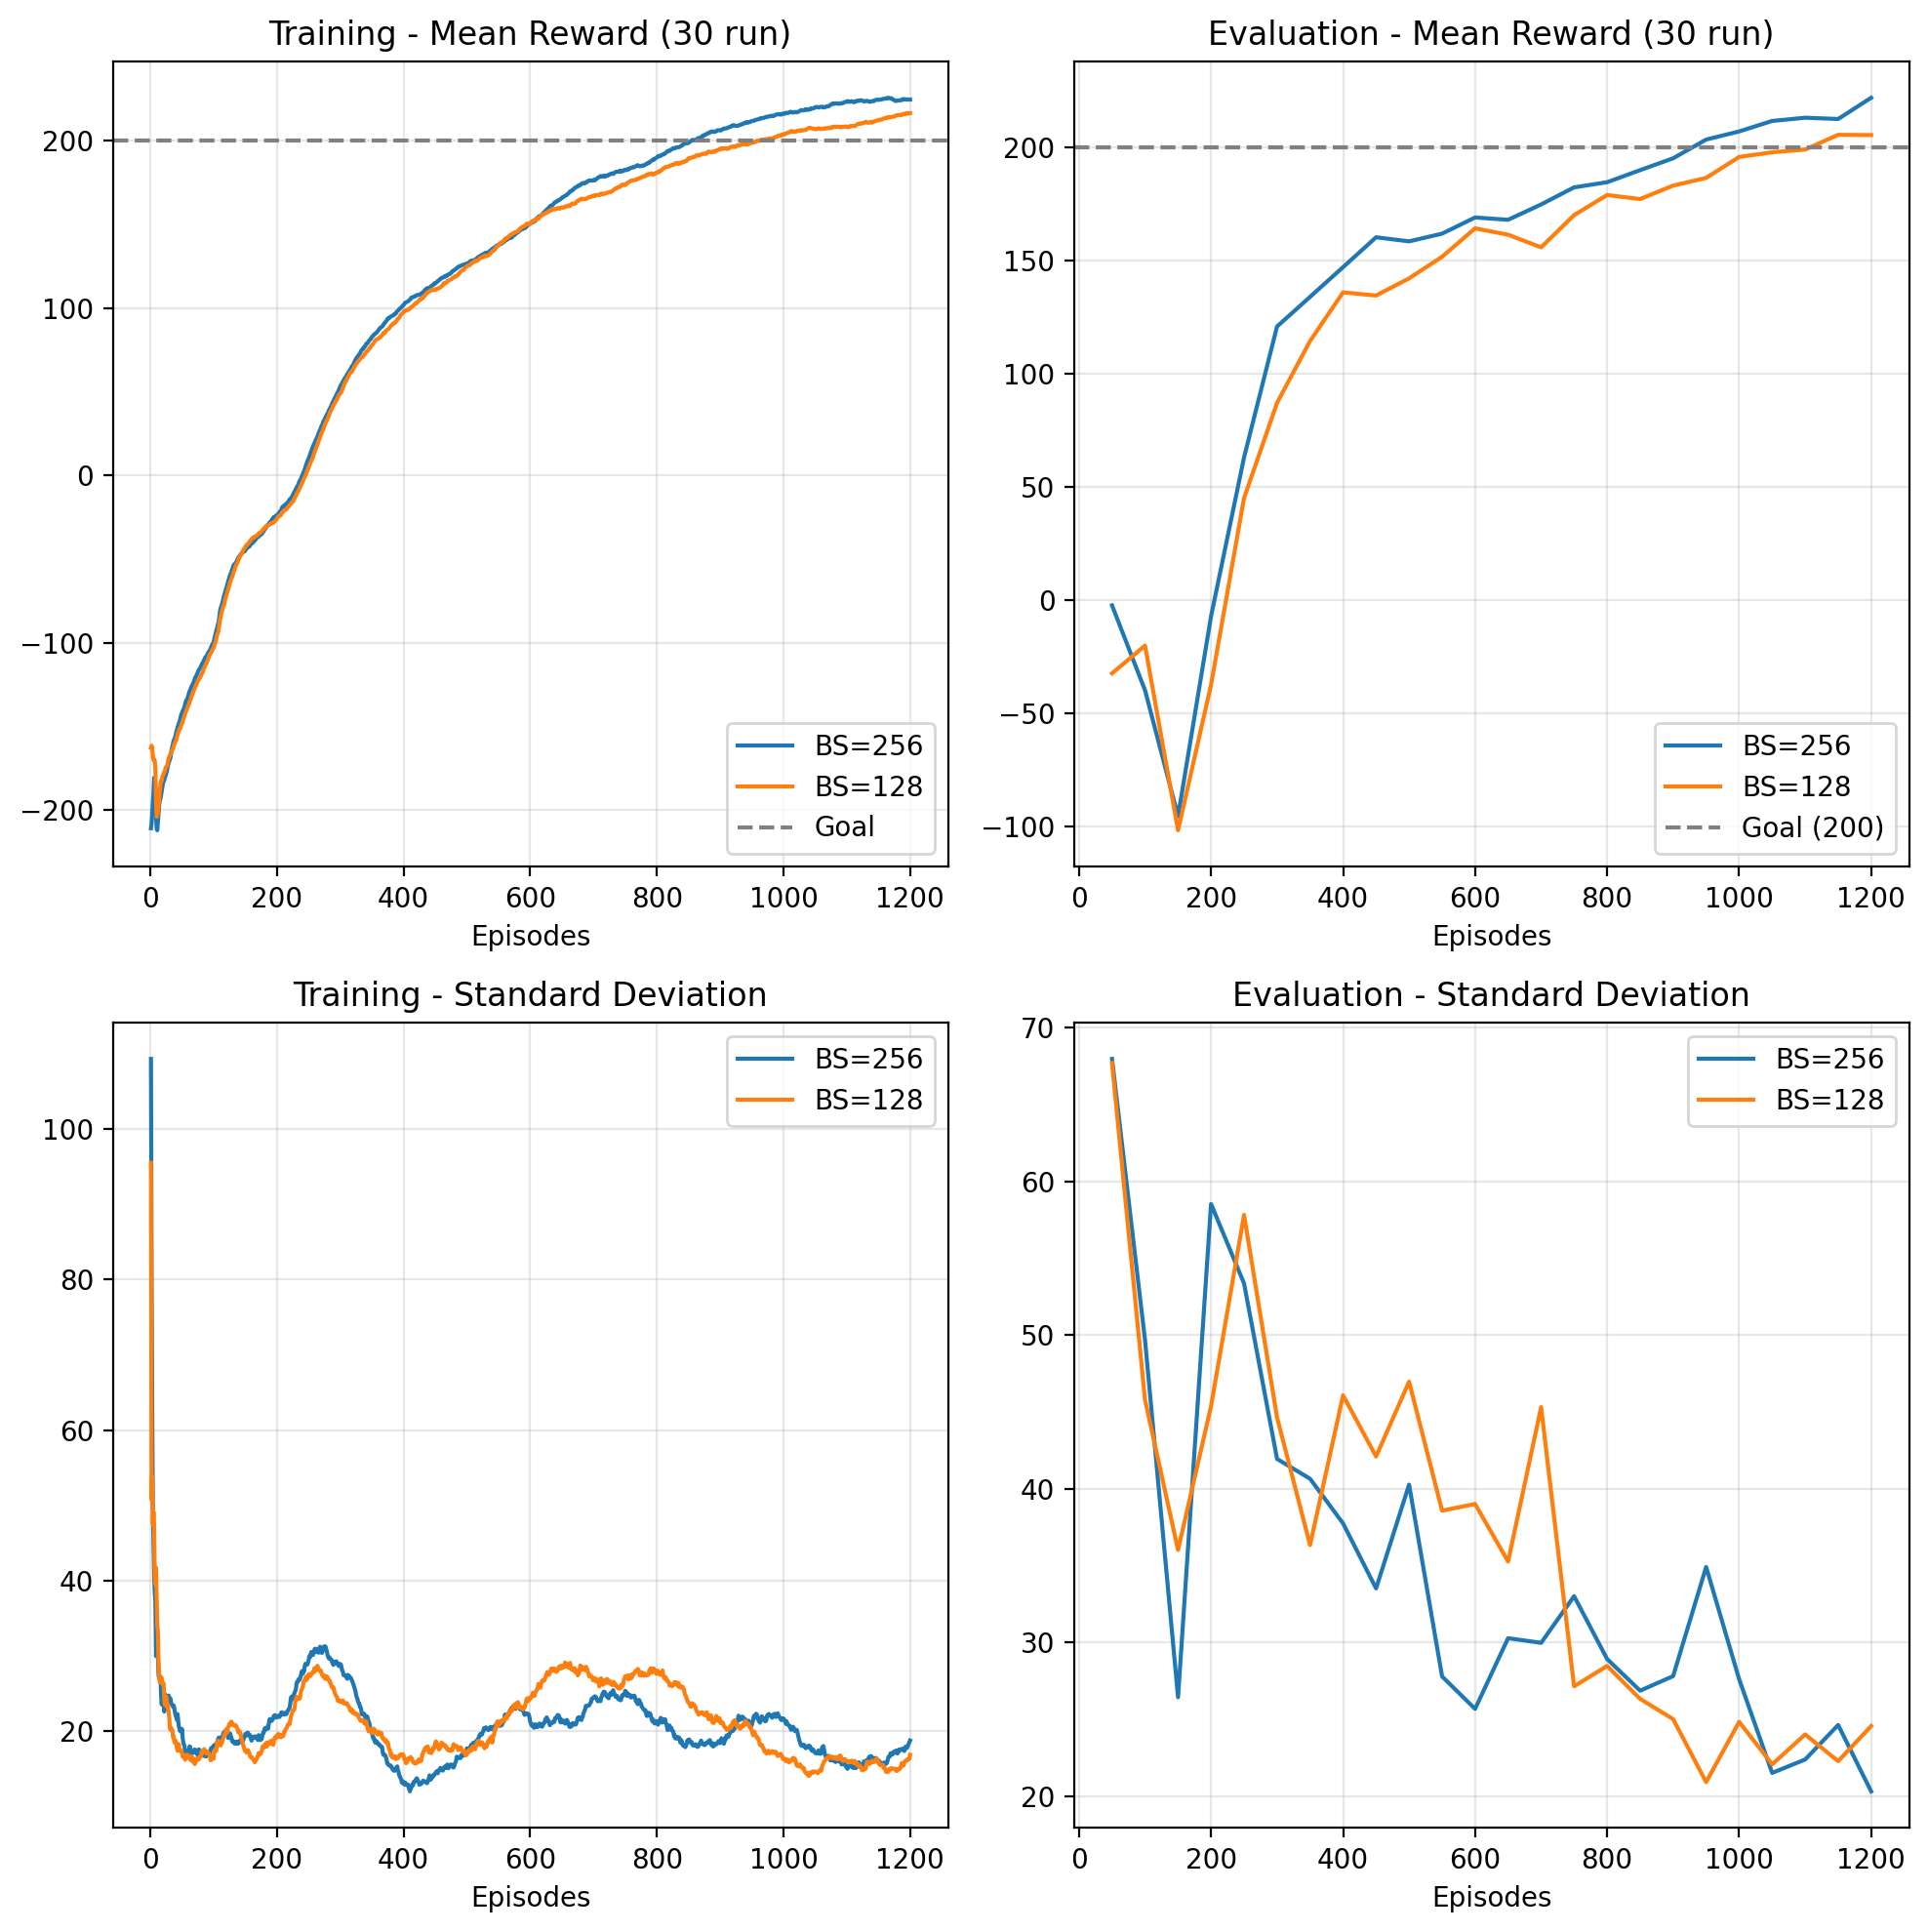

In [194]:
indexes = [7, 8]
ql_up_4_ids = [all_ids[i] for i in indexes]
ql_up_4_techniques = [all_techniques[i] for i in indexes]
ql_up_4_var_attributes = var_attributes[1:2]
plot_rewards_vs_episodes(ql_up_4_techniques, ql_up_4_ids, ql_up_4_var_attributes)

### Plot batch size = 128 and update period = 1
Compare:
- algorithm: {expected sarsa, q-learning}

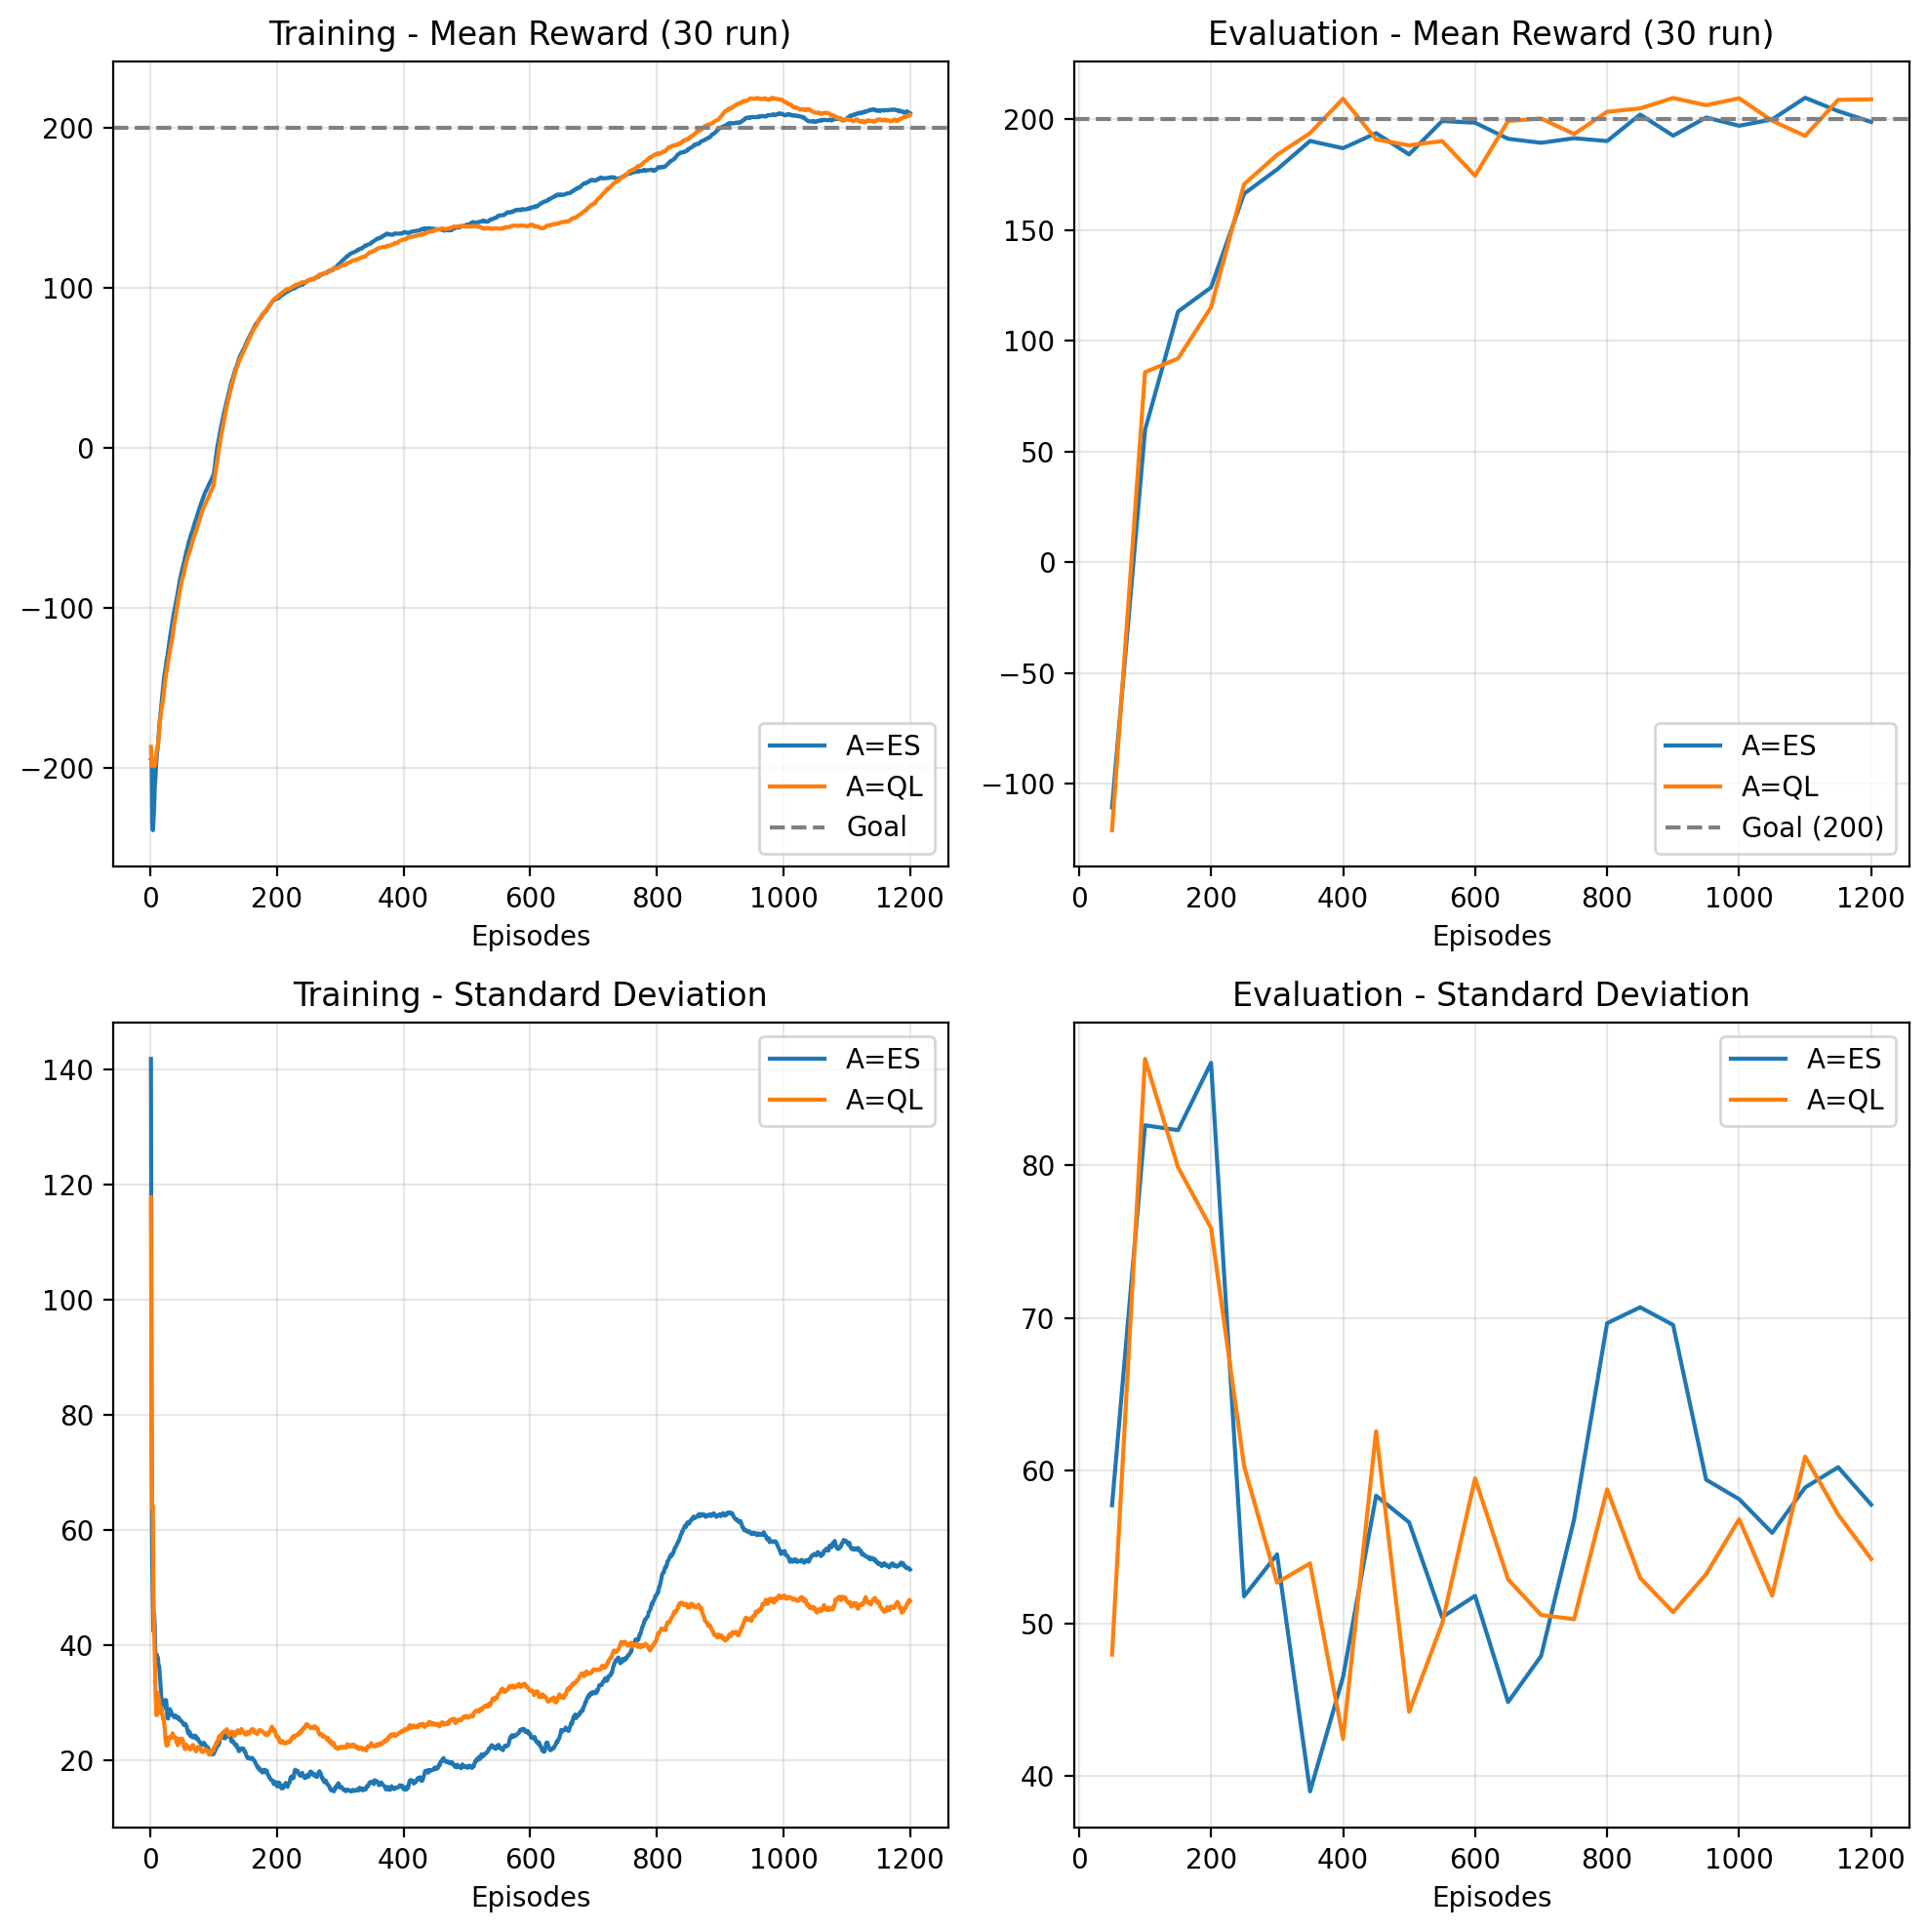

In [195]:
indexes = [0, 9]
bs_128_up_1_ids = [all_ids[i] for i in indexes]
bs_128_up_1_techniques = [all_techniques[i] for i in indexes]
bs_128_up_1_var_attributes = var_attributes[0:1]
plot_rewards_vs_episodes(bs_128_up_1_techniques, bs_128_up_1_ids, bs_128_up_1_var_attributes)

### Plot batch size = 128 and update period = 4
Compare:
- algorithm: {expected sarsa, q-learning}

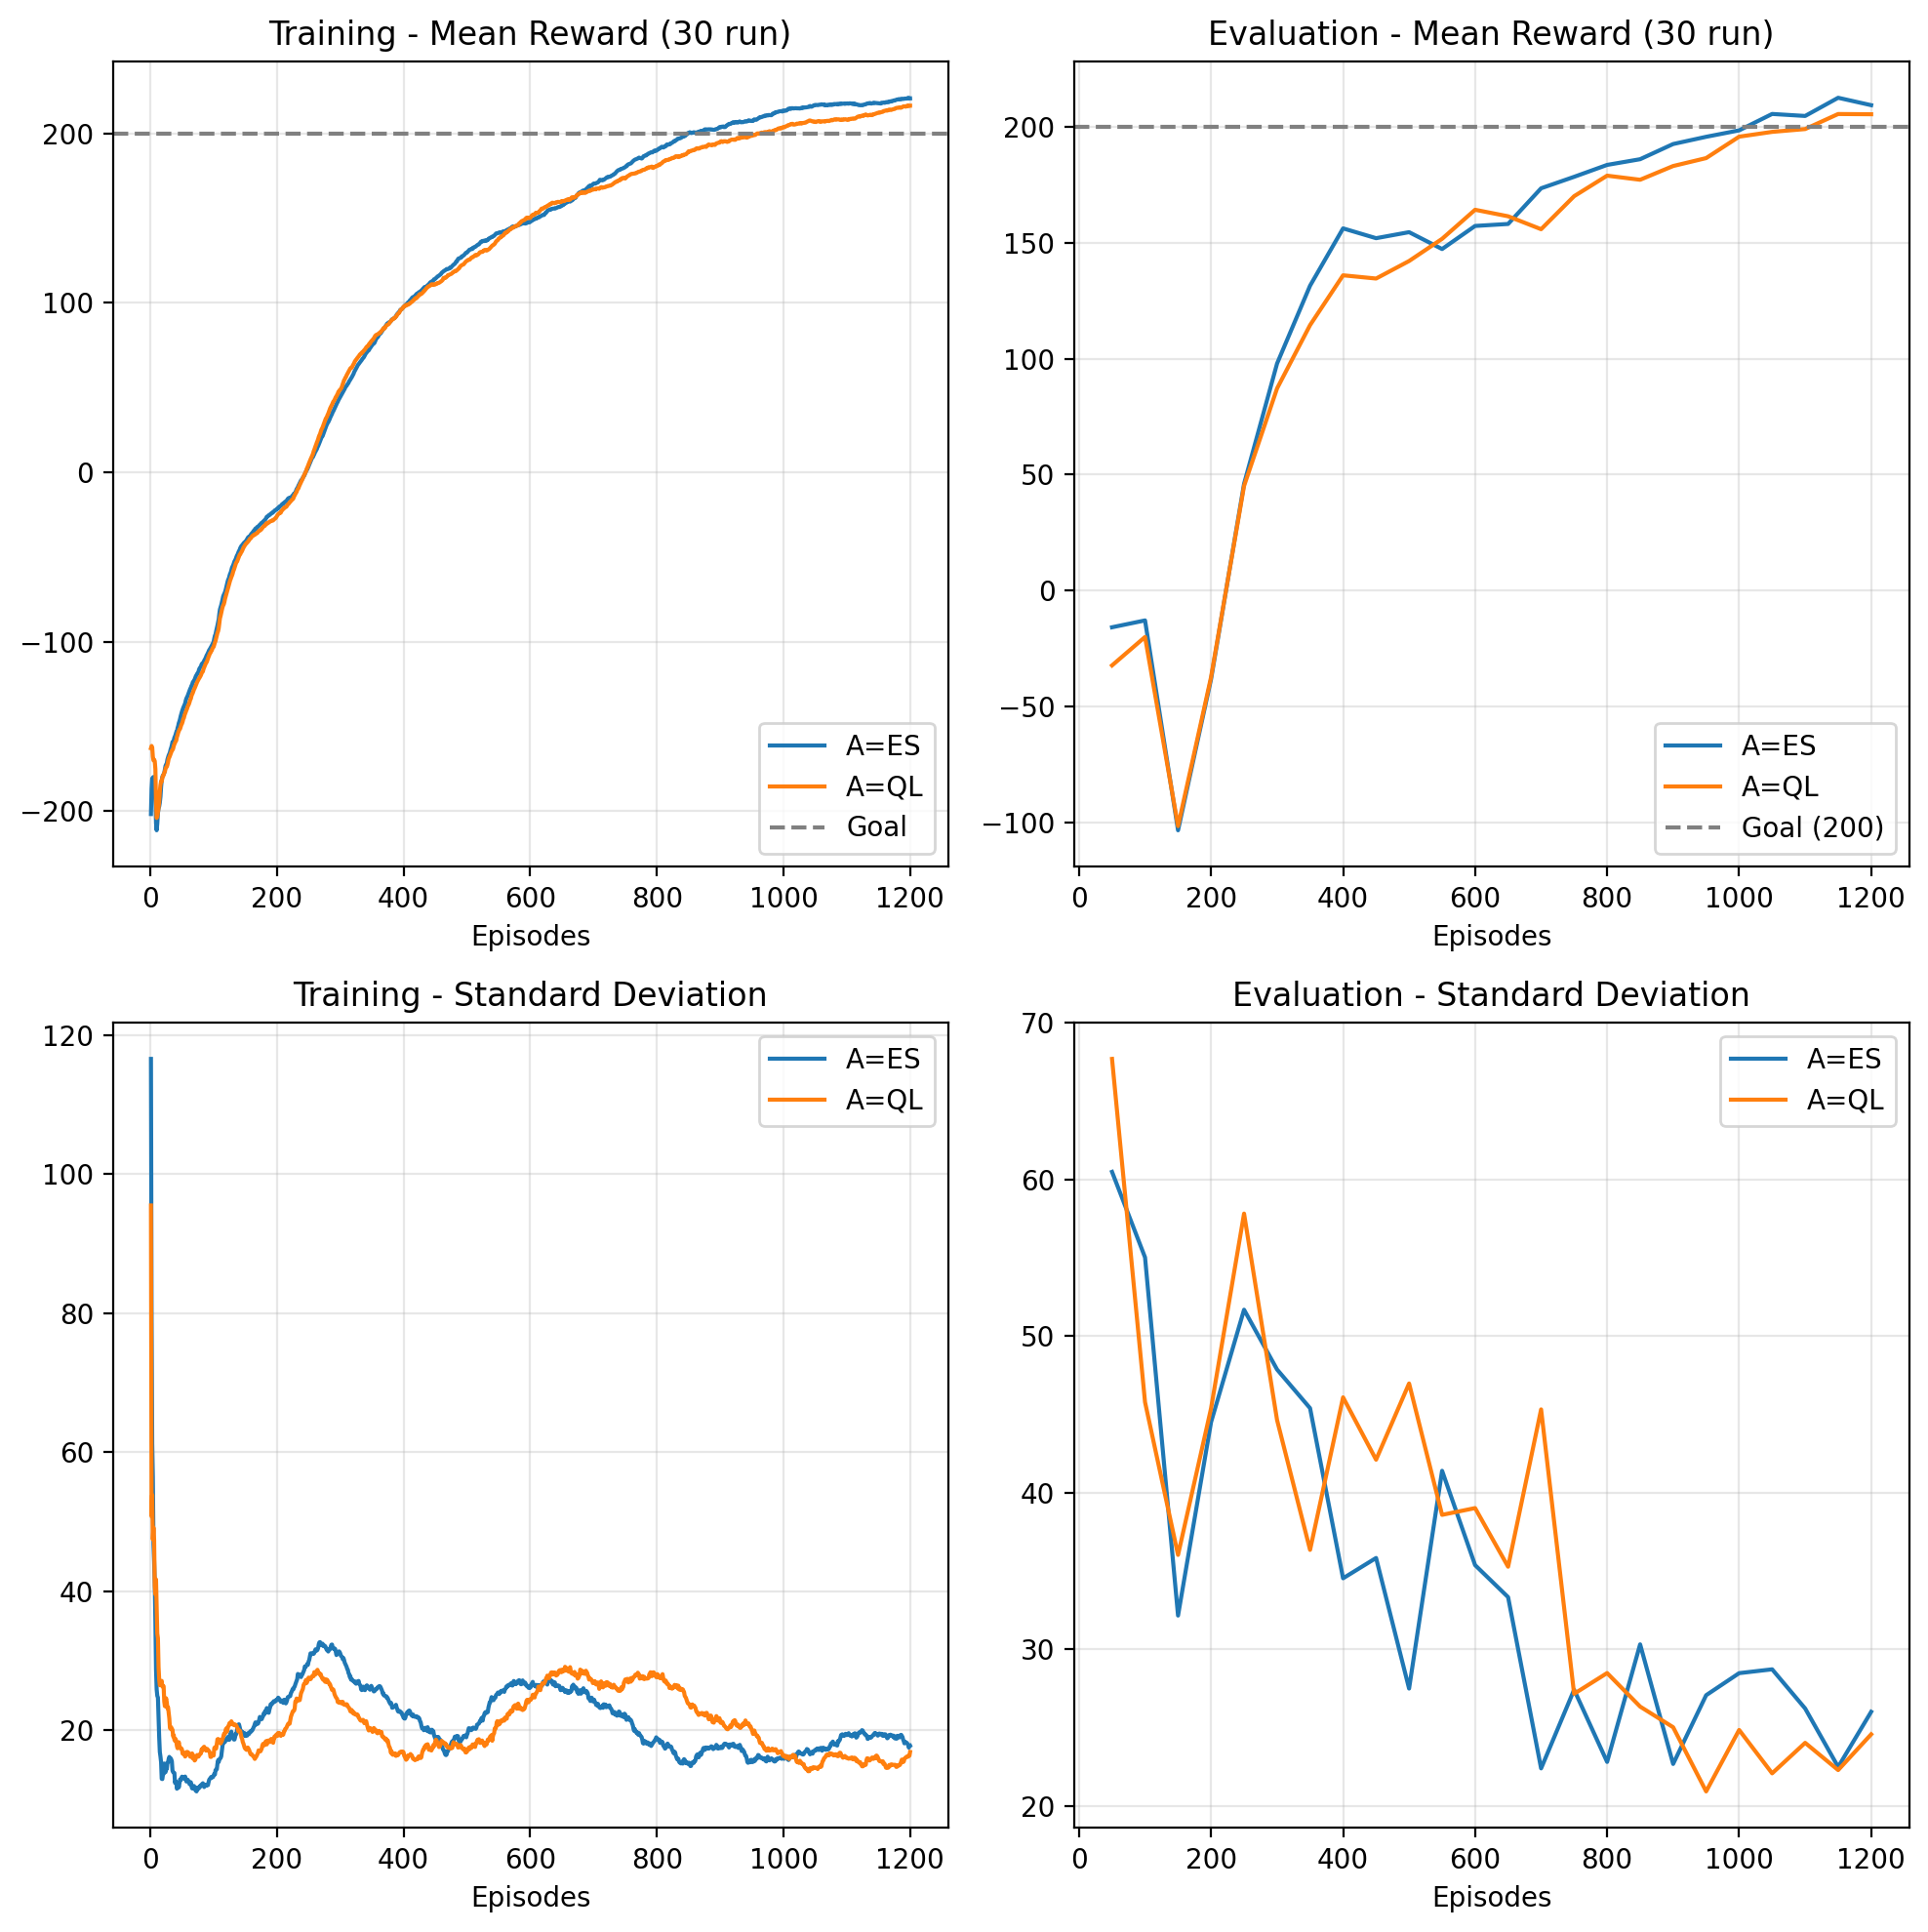

In [196]:
indexes = [1, 8]
bs_128_up_4_ids = [all_ids[i] for i in indexes]
bs_128_up_4_techniques = [all_techniques[i] for i in indexes]
bs_128_up_4_var_attributes = var_attributes[0:1]
plot_rewards_vs_episodes(bs_128_up_4_techniques, bs_128_up_4_ids, bs_128_up_4_var_attributes)

### Plot batch size = 256 and update period = 1
Compare:
- algorithm: {expected sarsa, q-learning}

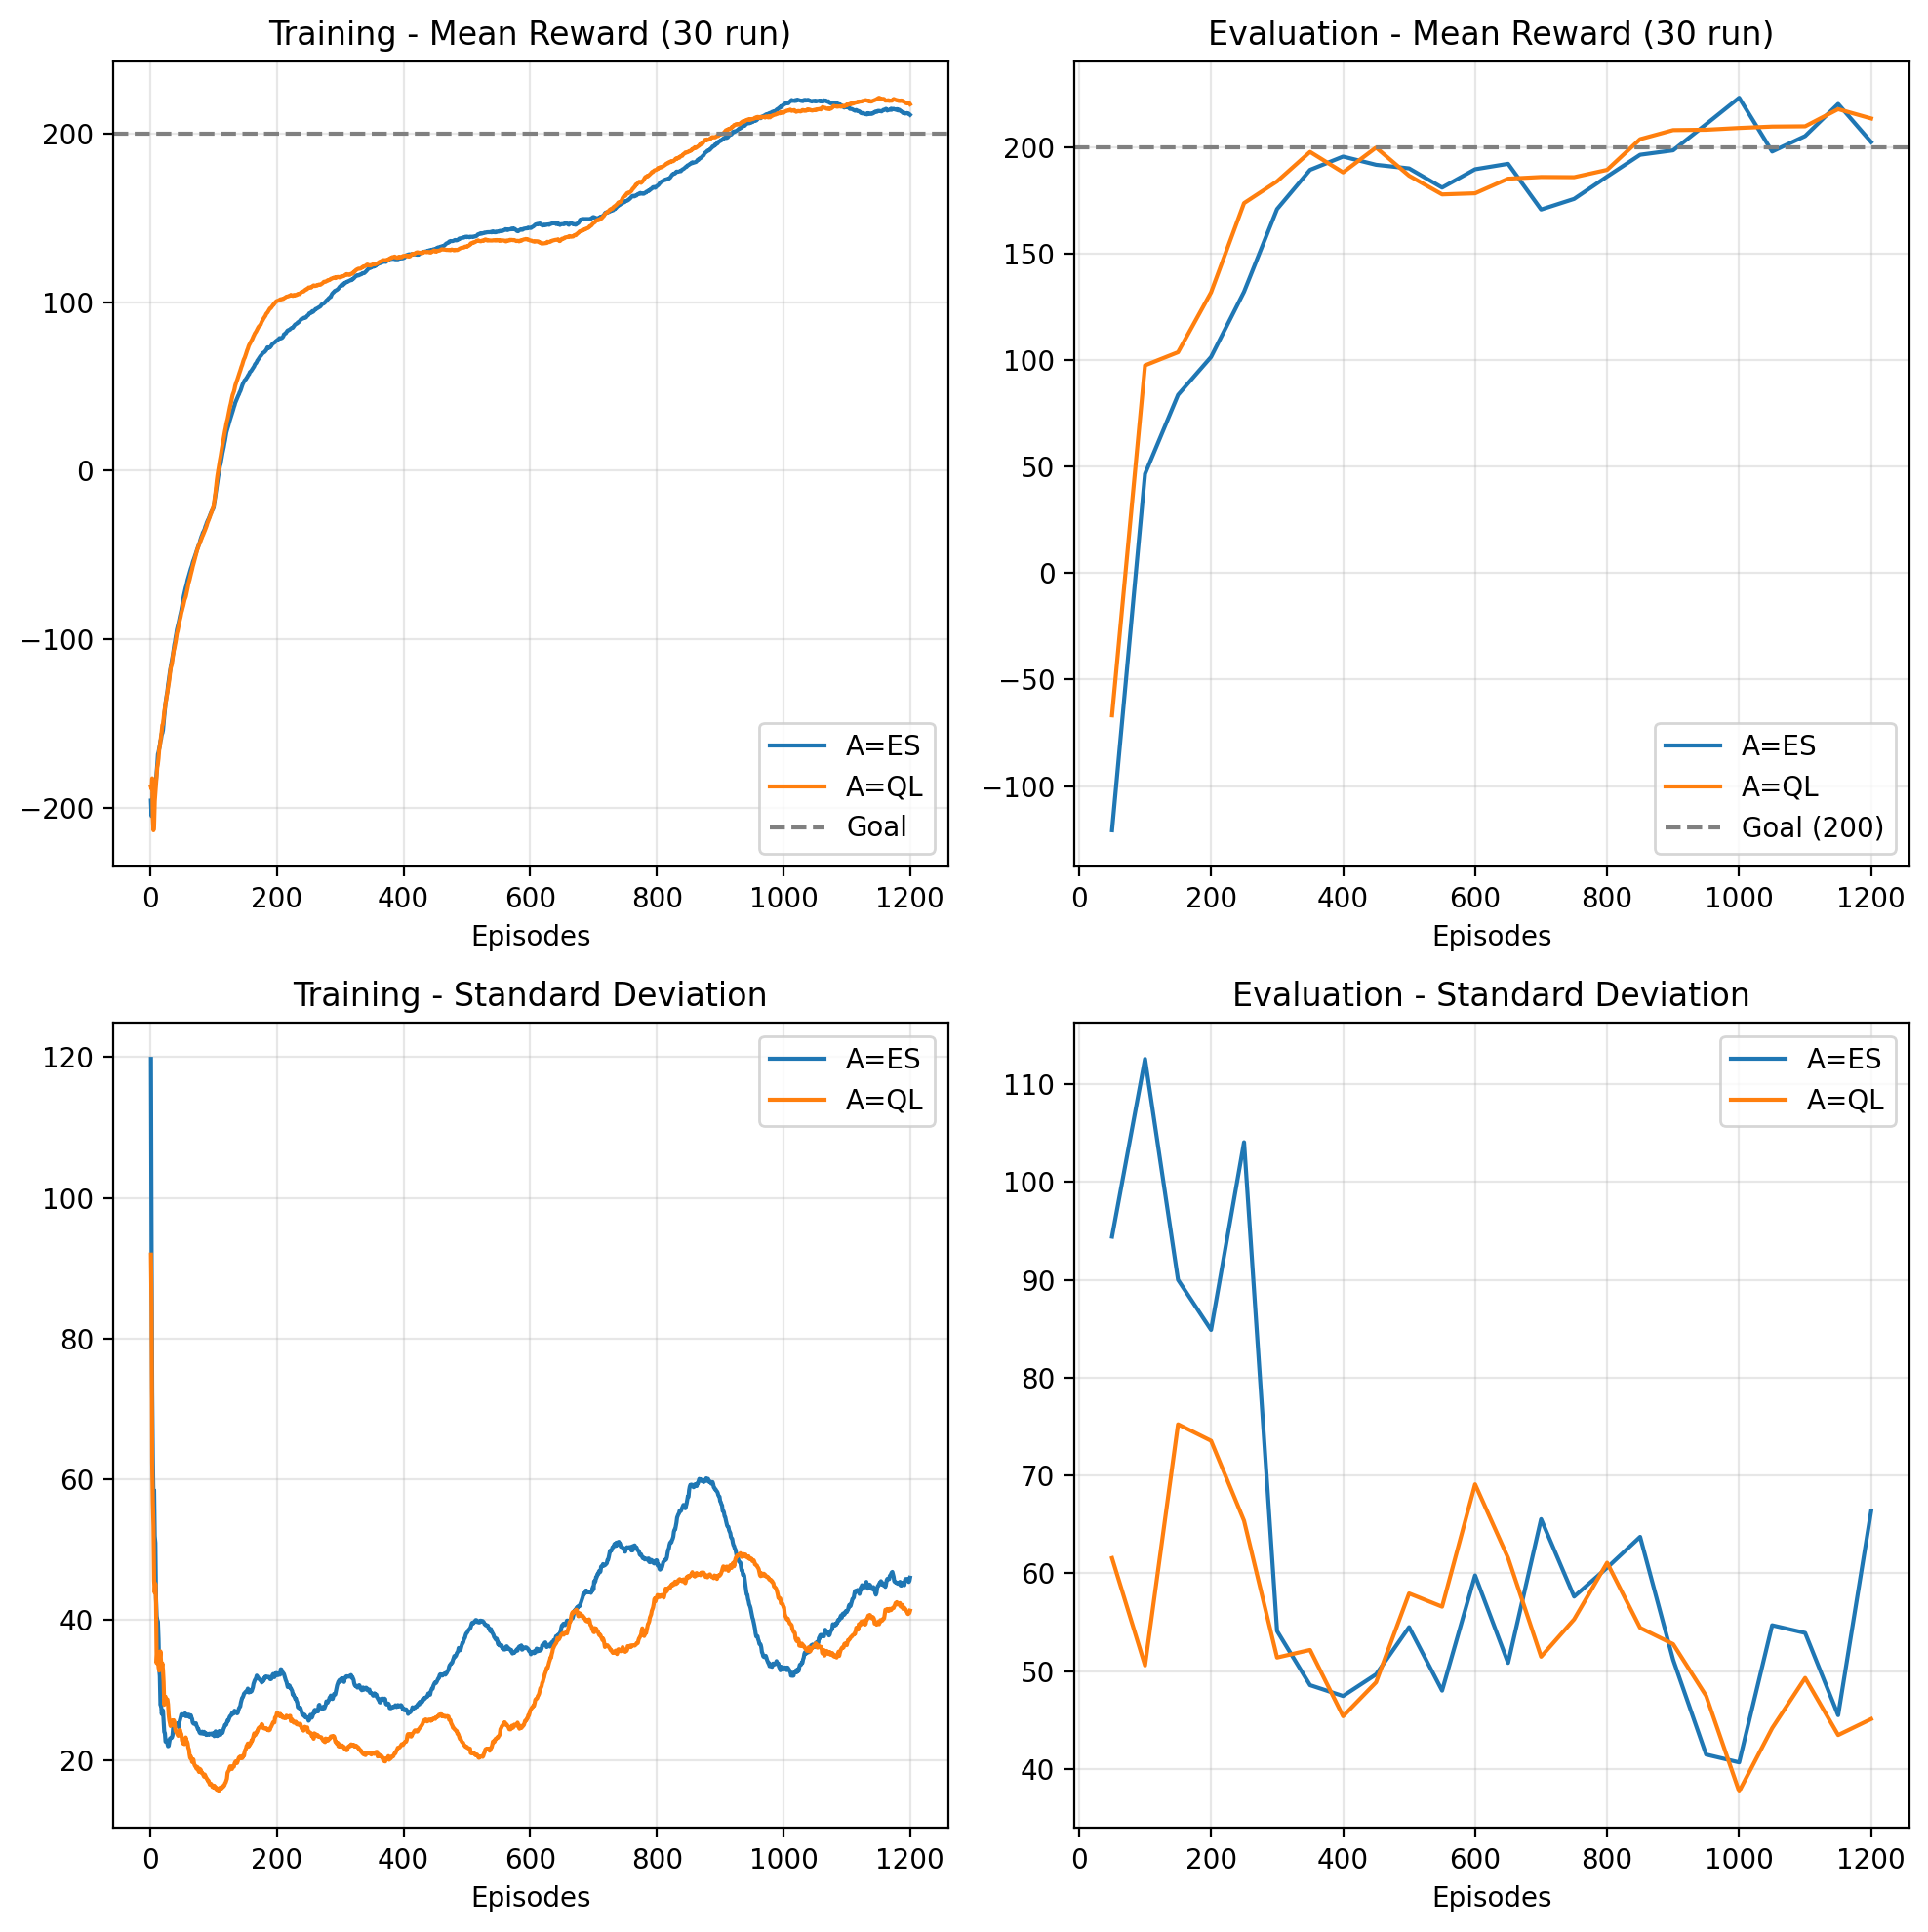

In [197]:
indexes = [2, 6]
bs_256_up_1_ids = [all_ids[i] for i in indexes]
bs_256_up_1_techniques = [all_techniques[i] for i in indexes]
bs_256_up_1_var_attributes = var_attributes[0:1]
plot_rewards_vs_episodes(bs_256_up_1_techniques, bs_256_up_1_ids, bs_256_up_1_var_attributes)

### Plot batch size = 256 and update period = 4
Compare:
- algorithm: {expected sarsa, q-learning}

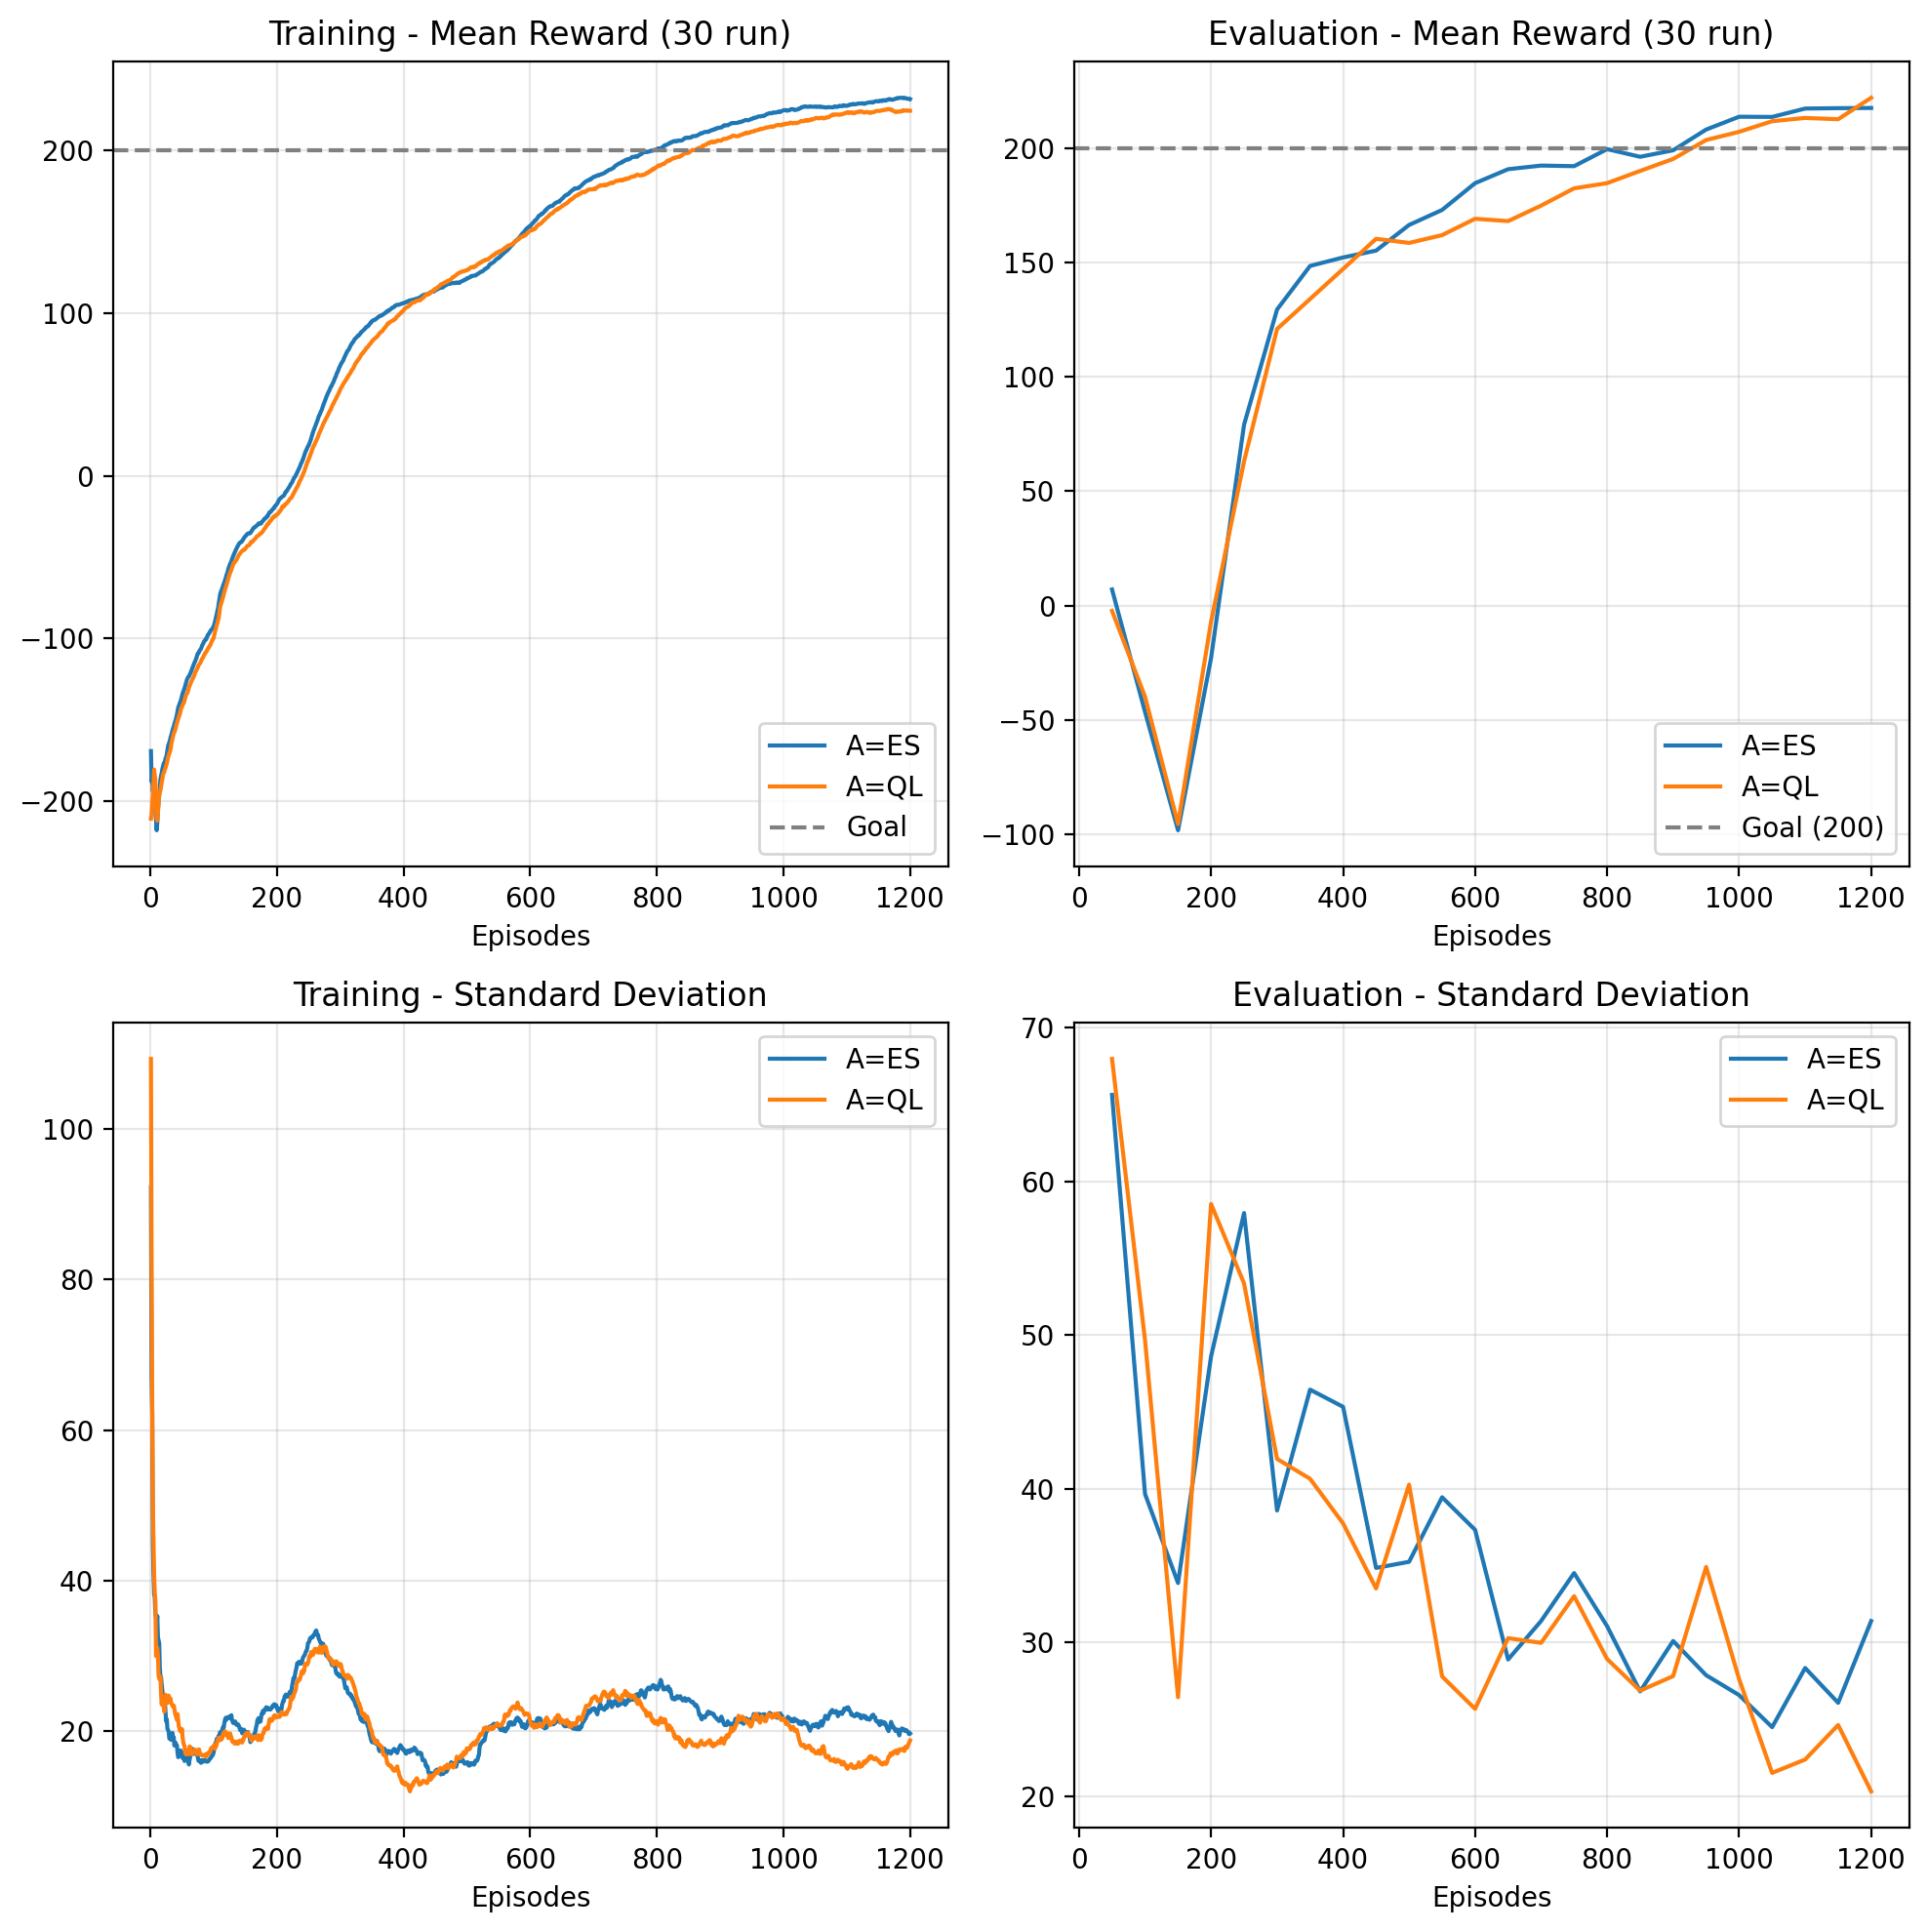

In [198]:
indexes = [3, 7]
bs_256_up_4_ids = [all_ids[i] for i in indexes]
bs_256_up_4_techniques = [all_techniques[i] for i in indexes]
bs_256_up_4_var_attributes = var_attributes[0:1]
plot_rewards_vs_episodes(bs_256_up_4_techniques, bs_256_up_4_ids, bs_256_up_4_var_attributes)

### Plot algorithm = expected sarsa, batch size = 256, including tau
Compare:
- update period: {1, 4}
- tau: {1e-3, 4e-3}

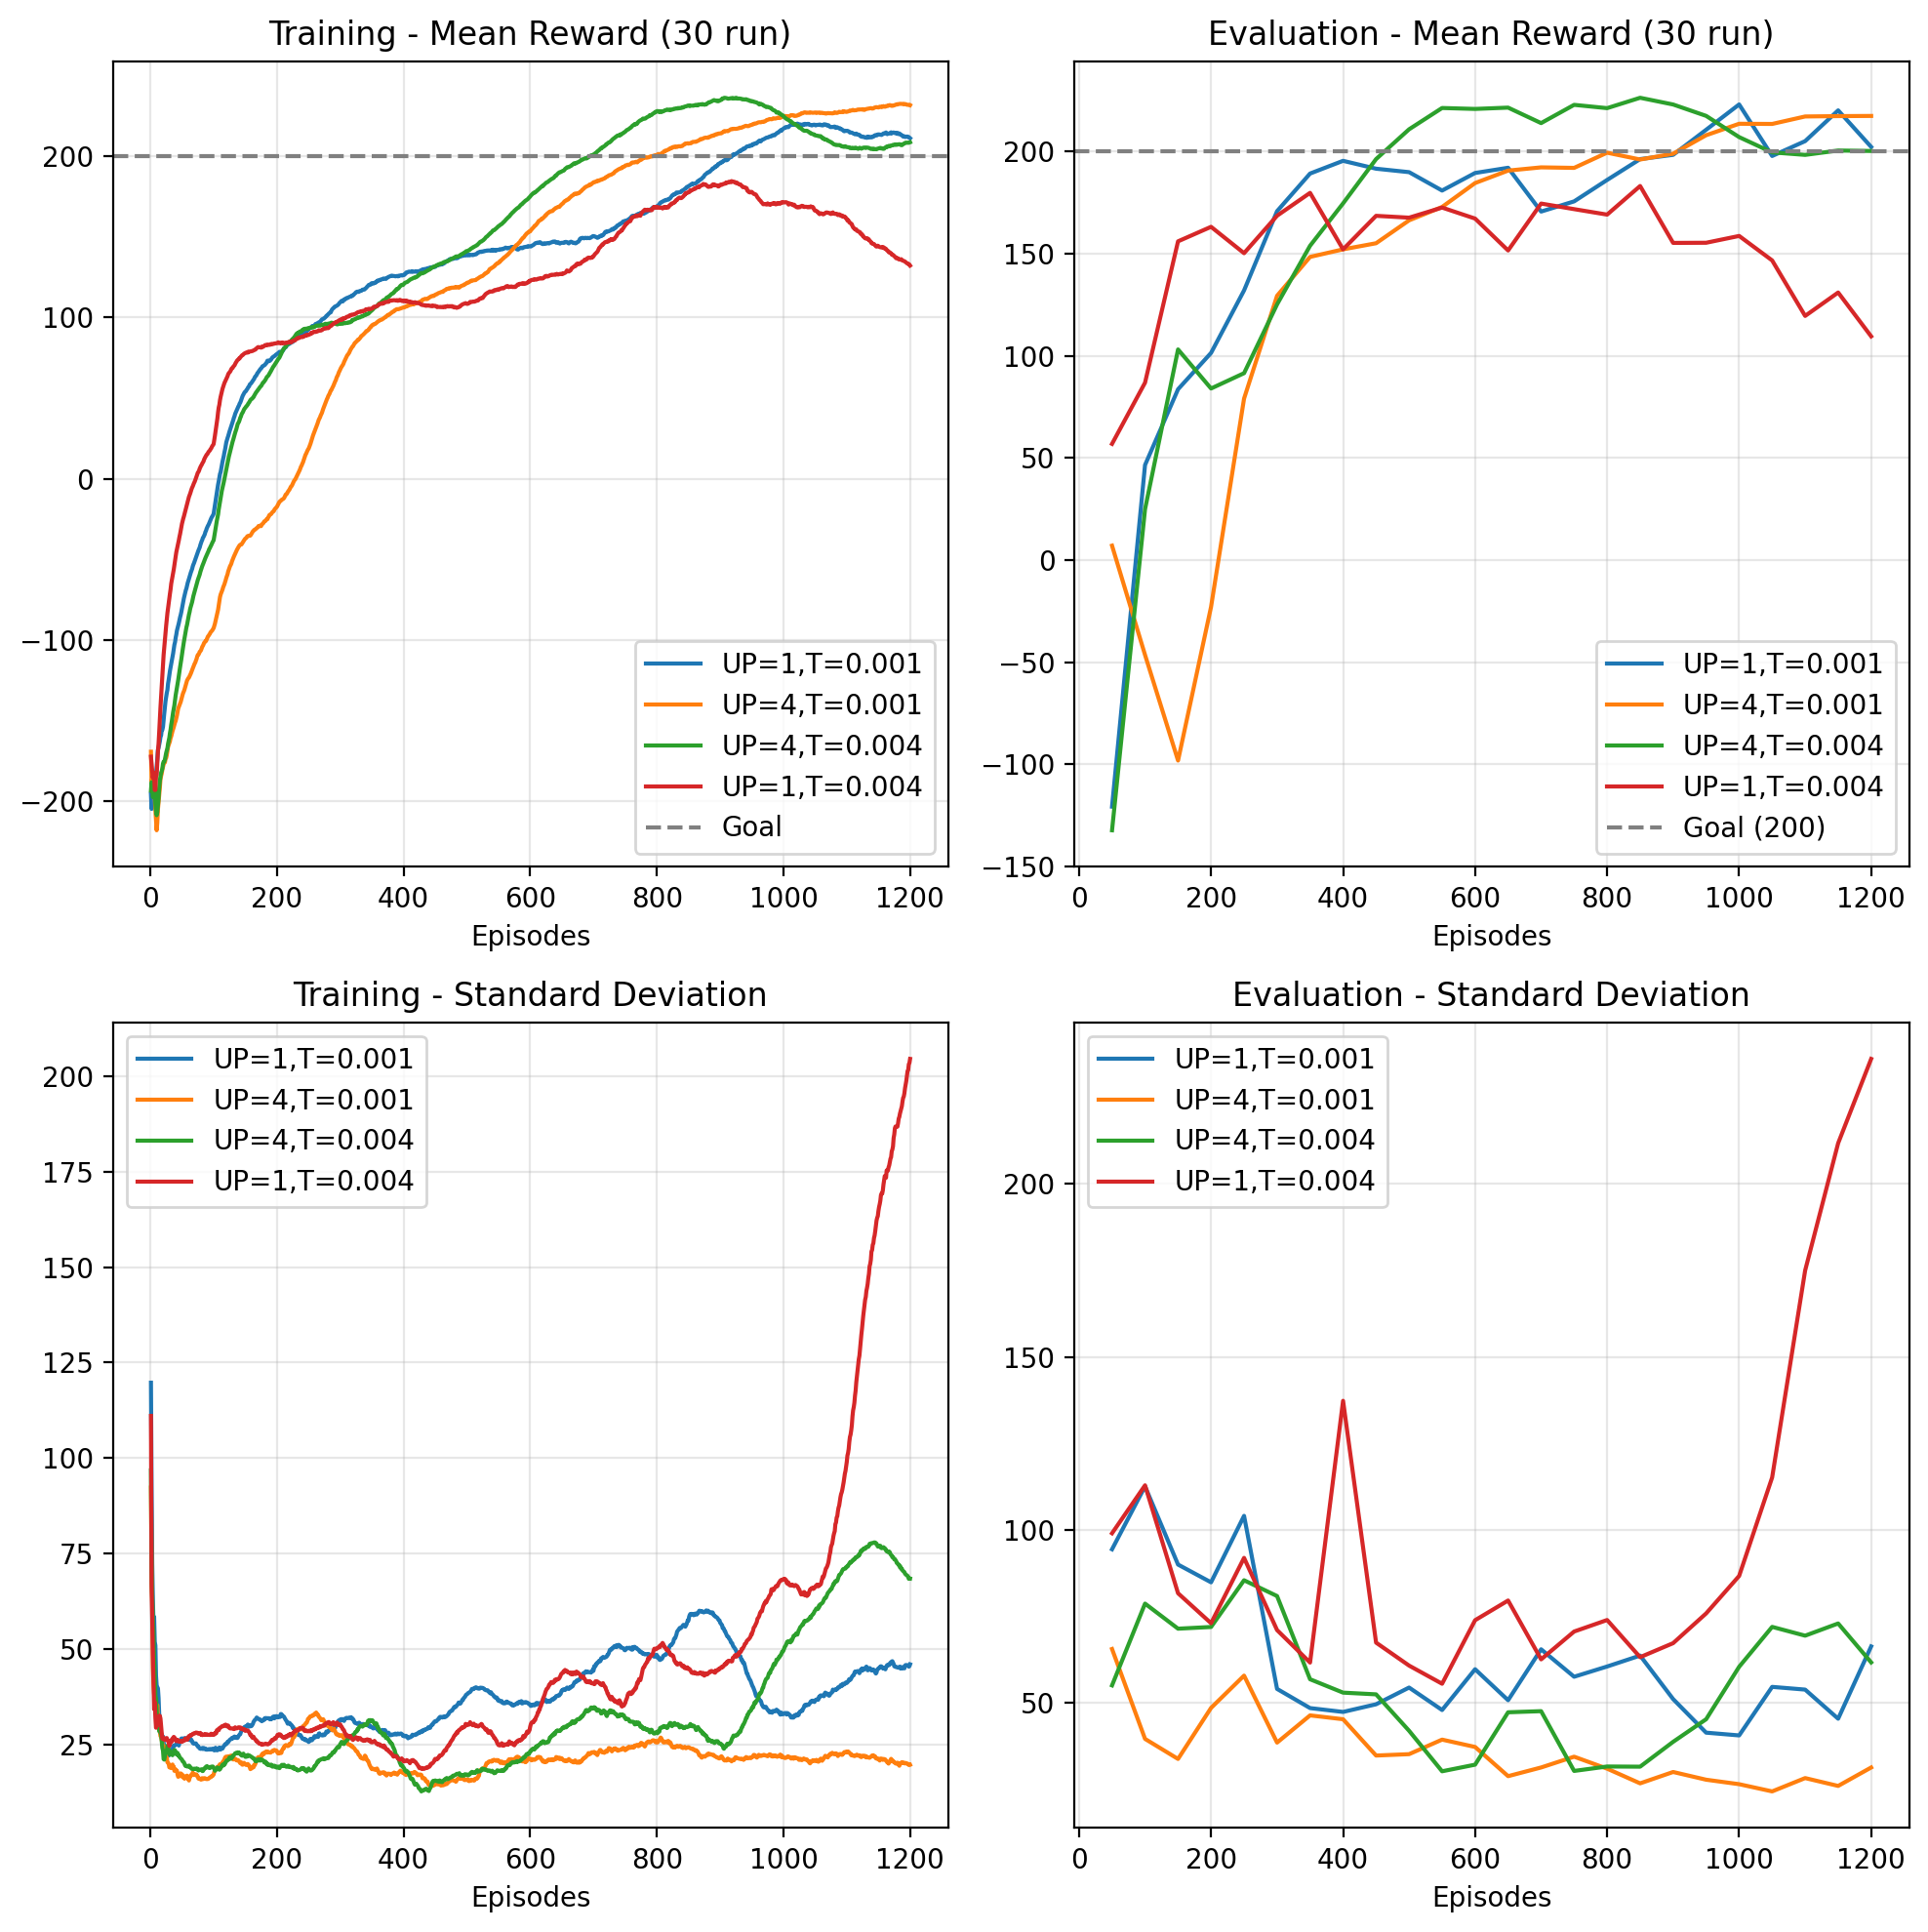

In [199]:
indexes = [2, 3, 4, 5]
es_bs_256_tau_ids = [all_ids[i] for i in indexes]
es_bs_256_tau_techniques = [all_techniques[i] for i in indexes]
es_bs_256_tau_var_attributes = var_attributes[2:]
plot_rewards_vs_episodes(es_bs_256_tau_techniques, es_bs_256_tau_ids, es_bs_256_tau_var_attributes)

### Plot algorithm = expected sarsa, batch size = 256, update period = 1, including tau
Compare:
- tau: {1e-3, 4e-3}

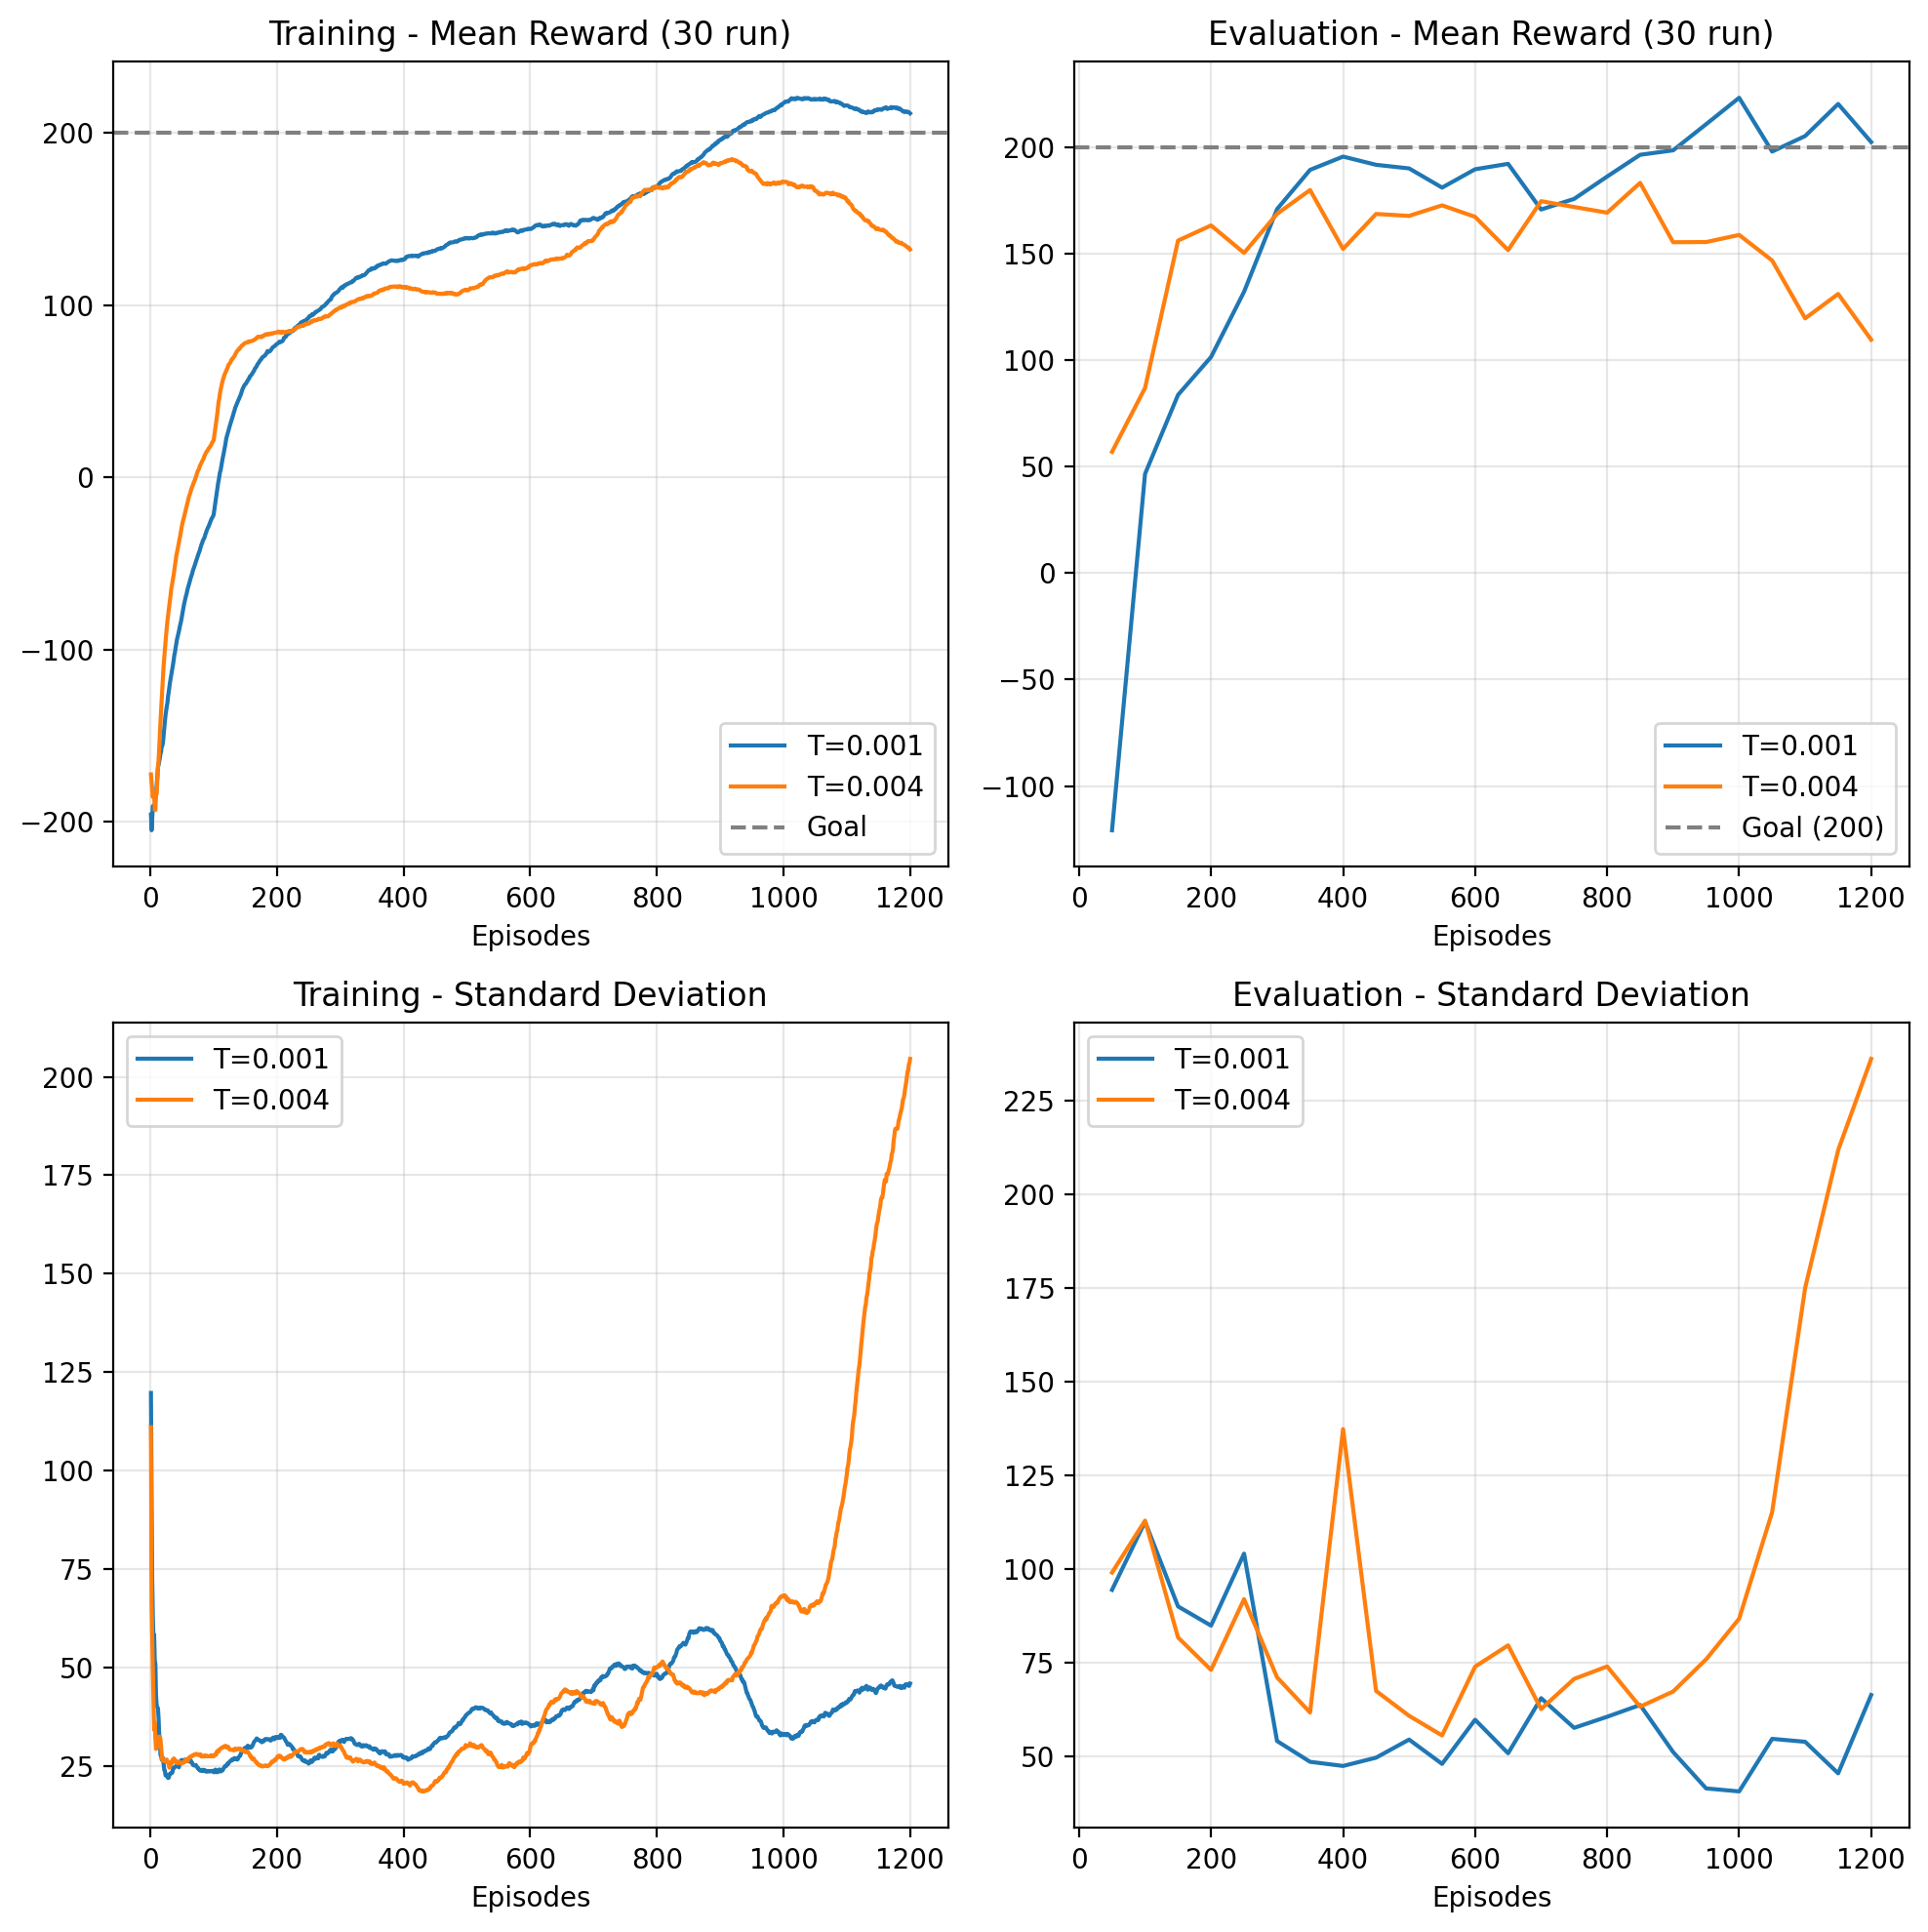

In [200]:
indexes = [2, 5]
es_bs_256_up_1_tau_ids = [all_ids[i] for i in indexes]
es_bs_256_up_1_tau_techniques = [all_techniques[i] for i in indexes]
es_bs_256_up_1_tau_var_attributes = var_attributes[3:]
plot_rewards_vs_episodes(es_bs_256_up_1_tau_techniques, es_bs_256_up_1_tau_ids, es_bs_256_up_1_tau_var_attributes)

### Plot algorithm = expected sarsa, batch size = 256, update period = 4, including tau
Compare:
- tau: {1e-3, 4e-3}

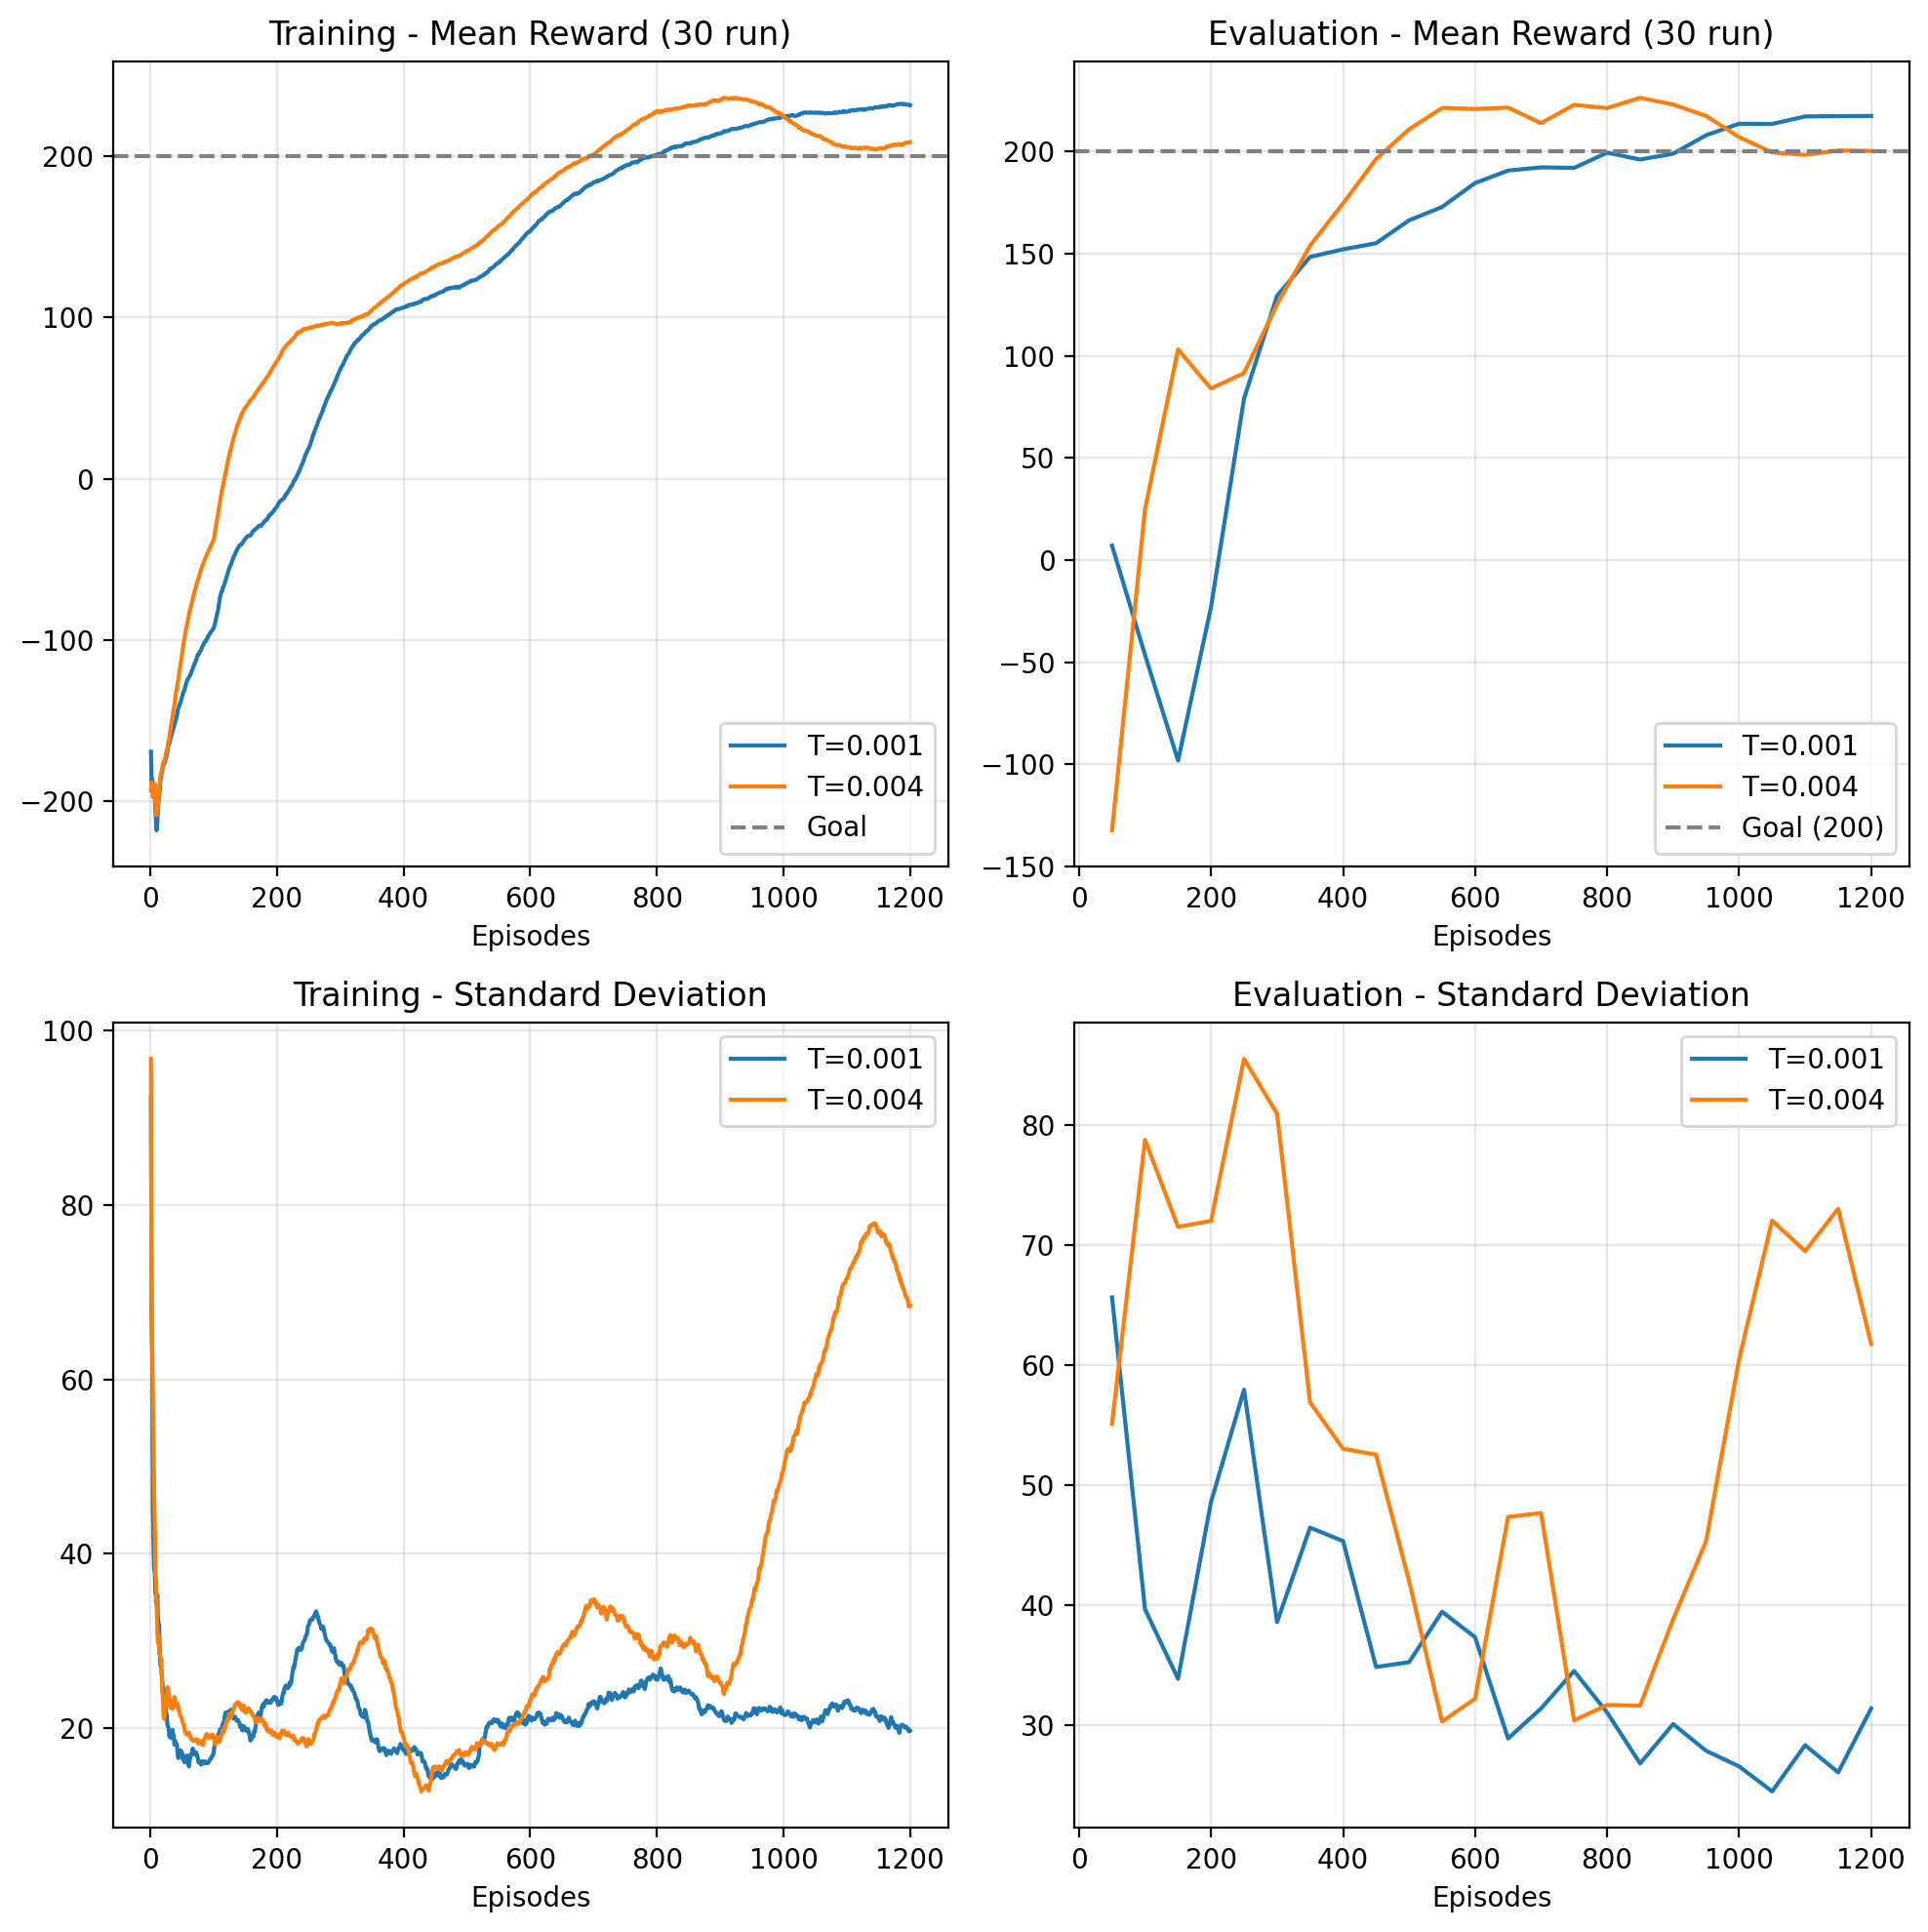

In [201]:
indexes = [3, 4]
es_bs_256_up_4_tau_ids = [all_ids[i] for i in indexes]
es_bs_256_up_4_tau_techniques = [all_techniques[i] for i in indexes]
es_bs_256_up_4_tau_var_attributes = var_attributes[3:]
plot_rewards_vs_episodes(es_bs_256_up_4_tau_techniques, es_bs_256_up_4_tau_ids, es_bs_256_up_4_tau_var_attributes)